SuperCellMulti identifies robust multiomics metacells increasing inter-modality consistency compared to single cells.

# Package loading

In [5]:
library(SuperCell)
library(Seurat)
library(ggplot2)
library(ggsignif)


In [6]:
library(patchwork)

In [7]:
source("../../../R/functions/CoveragePlots.R")
source("../../../R/functions/StatTestPlots.R")

In [8]:
#library(Cairo)
#options(bitmapType = "cairo")

## PBMC multiome results

In [9]:
# datadir <- ../../../ in the workflow
# in home with the notebook
datadir <- "/mnt/beegfs01/scratch/l_herault/tests/SuperCellMultiomicsAnalyses/" 

Loading required package: Signac



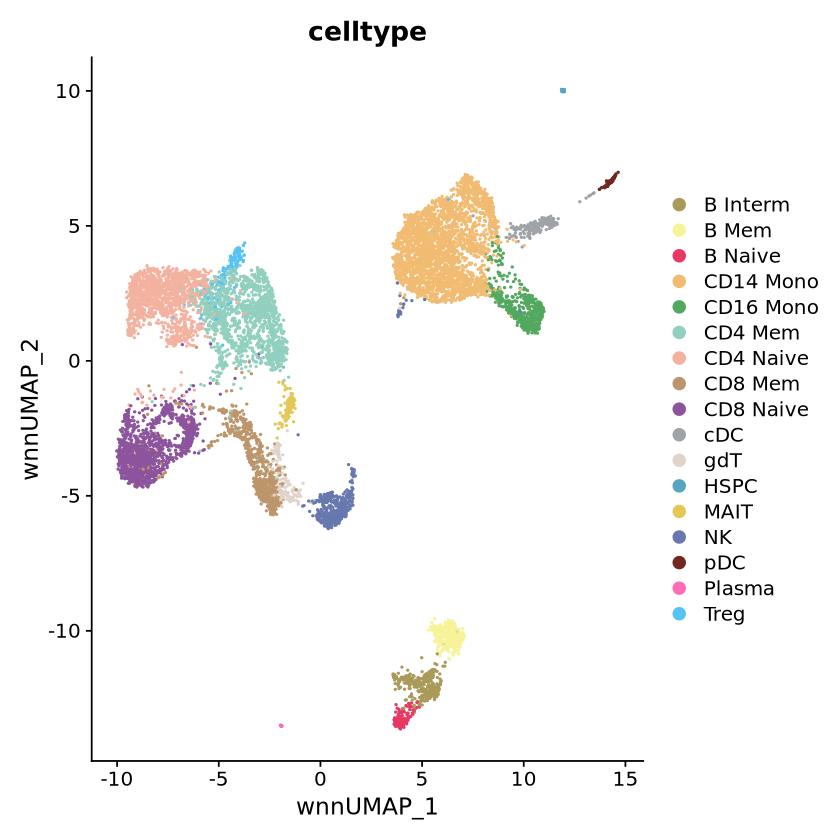

In [10]:
pbmc <- readRDS(paste0(datadir,"/output/pbmcMultiome/singlecells_analysis/seuratWNN.rds"))


addCellTypePBMC <- function(pbmc) {
  pbmc$celltype <- pbmc$seurat_annotations

  pbmc$celltype[grepl(pattern = "CD8 TEM",x = pbmc$celltype)] <- "CD8 Mem"

  pbmc$celltype[grepl(pattern = "CD4 TEM",x = pbmc$celltype)] <- "CD4 Mem"
  pbmc$celltype[grepl(pattern = "CD4 TCM",x = pbmc$celltype)] <- "CD4 Mem"

  pbmc$celltype[grepl(pattern = "CD8 TEM",x = pbmc$celltype)] <- "CD8 Mem"

  pbmc$celltype[grepl(pattern = "Intermediate B",x = pbmc$celltype)] <- "B Interm"
  pbmc$celltype[grepl(pattern = "Naive B",x = pbmc$celltype)] <- "B Naive"
  pbmc$celltype[grepl(pattern = "Memory B",x = pbmc$celltype)] <- "B Mem"
  pbmc$celltype <- factor(pbmc$celltype,levels = c( "B Interm",  "B Mem"   ,
                                                    "B Naive" ,  "CD14 Mono",
                                                    "CD16 Mono" ,"CD4 Mem" ,
                                                    "CD4 Naive" ,"CD8 Mem"  ,
                                                    "CD8 Naive", "cDC"   ,
                                                    "gdT"  ,     "HSPC"  ,
                                                    "MAIT",      "NK" ,
                                                    "pDC" , "Plasma",     "Treg"  ))

  Idents(pbmc) <- "celltype"
  return(pbmc)
}


color.celltypes.pbmc <- c("CD14 Mono" =  "#F1BB72",
                          "CD16 Mono" = "#53A85F",
                          "CD4 Mem" = '#91D0BE',
                          "CD4 Naive" = "#F3B1A0",
                          "CD8 Effector" = "#AB3282",
                          "CD8 Mem" = "#BD956A",
                          "CD8 Naive" = "#8C549C",
                          "cDC" = "#9FA3A8",
                          "gdT" = "#E0D4CA",
                          "MAIT" = "#E4C755",
                          "Plasma" = "#ff6db6",
                          'B Mem' = "#F7F398",
                          "B Interm" = "#AA9A59",
                          "B Naive" = "#E63863",
                          "NK" = "#6778AE",
                          "pDC" = "#712820",
                          "Treg" ='#57C3F3',
                          "HSPC" = "#58A4C3")

pbmc <- addCellTypePBMC(pbmc)

# color <- c("CD4 Naive"="#999999","NK"="#004949","CD8 Naive"="#009292","CD14 Mono"="#ff6db6",
#            "gdT"="#490092", "CD4 Mem"="#006ddb","cDC"="#b66dff","Treg"="#6db6ff",
#            "B Interm"="#b6dbff","B Mem"= "#8494FF","B Naive" = "#00A9FF",
#            "CD16 Mono"="#920000","HSPC"="#924900","CD8 Mem"="#db6d00","pDC"="#24ff24", "MAIT"="#ffff6d","Plasma"="#ffb6db")
#
#
# show_col(color.celltypes)
DimPlot(pbmc,group.by = "celltype",cols = color.celltypes.pbmc,reduction = "wnn.umap")


In [11]:
pbmc.supercell.atac <- readRDS(paste0(datadir,"/output/pbmcMultiome/SuperCellATAC/g75/seurat.multiome.activities.rds"))
pbmc.supercell.atac <- addCellTypePBMC(pbmc.supercell.atac)
pbmc.supercell.atac <- DietSeurat(pbmc.supercell.atac,assays = c("RNA","ATAC"))


pbmc.seacells.atac <- readRDS(paste0(datadir,"/output/pbmcMultiome//seacellsATAC//g75/seurat.multiome.activities.rds"))
pbmc.seacells.atac <- addCellTypePBMC(pbmc.seacells.atac)
pbmc.seacells.atac <- DietSeurat(pbmc.seacells.atac,assays = c("RNA","ATAC"))

pbmc.metaq.atac <- readRDS(paste0(datadir,"/output/pbmcMultiome//metaqATAC//g75/seurat.multiome.activities.rds"))
pbmc.metaq.atac <- addCellTypePBMC(pbmc.metaq.atac)
pbmc.metaq.atac <- DietSeurat(pbmc.metaq.atac,assays = c("RNA","ATAC"))




pbmc.seacells.rna <- readRDS(paste0(datadir,"/output/pbmcMultiome//seacellsRNA//g75/seurat.multiome.activities.rds"))
pbmc.seacells.rna <- addCellTypePBMC(pbmc.seacells.rna)
pbmc.seacells.rna <- DietSeurat(pbmc.seacells.rna,assays = c("RNA","ATAC"))


pbmc.supercell.rna <- readRDS(paste0(datadir,"/output/pbmcMultiome//SuperCellRNA//g75/seurat.multiome.activities.rds"))
pbmc.supercell.rna <- addCellTypePBMC(pbmc.supercell.rna)
pbmc.supercell.rna <- DietSeurat(pbmc.supercell.rna,assays = c("RNA","ATAC"))


pbmc.metaq.rna <- readRDS(paste0(datadir,"/output/pbmcMultiome//metaqRNA//g75/seurat.multiome.activities.rds"))
pbmc.metaq.rna <- addCellTypePBMC(pbmc.metaq.rna)
pbmc.metaq.rna <- DietSeurat(pbmc.metaq.rna,assays = c("RNA","ATAC"))


pbmc.metacell.rna <- readRDS(paste0(datadir,"/output/pbmcMultiome/MetaCellRNA//g75/seurat.multiome.activities.rds"))
pbmc.metacell.rna <- addCellTypePBMC(pbmc.metacell.rna)
pbmc.metacell.rna <- DietSeurat(pbmc.metacell.rna,assays = c("RNA","ATAC"))




pbmc.supercell.multi <- readRDS(paste0(datadir,"/output/pbmcMultiome//SuperCellMulti//g75/seurat.multiome.activities.rds"))
pbmc.supercell.multi <- addCellTypePBMC(pbmc.supercell.multi)
pbmc.supercell.multi <- DietSeurat(pbmc.supercell.multi,assays = c("RNA","ATAC"))


pbmc.seacells.mofa <- readRDS(paste0(datadir,"/output/pbmcMultiome//seacellsMOFA/g75/seurat.multiome.activities.rds"))
pbmc.seacells.mofa <- addCellTypePBMC(pbmc.seacells.mofa)
pbmc.seacells.mofa <- DietSeurat(pbmc.seacells.mofa,assays = c("RNA","ATAC"))

pbmc.metaq.multi <- readRDS(paste0(datadir,"/output/pbmcMultiome//metaqMulti/g75/seurat.multiome.activities.rds"))
pbmc.metaq.multi <- addCellTypePBMC(pbmc.metaq.multi)
pbmc.metaq.multi <- DietSeurat(pbmc.metaq.multi,assays = c("RNA","ATAC"))





In [12]:
# source("../R/functions/metacellCompactnessSeparation.R")

if (!file.exists("metrics.pbmc.multiome.csv")) {
  metrics <- data.frame()
  # methods <- c('SuperCellMulti','SuperCellRNA',"SuperCellATAC","randomMetacells","seacellsRNA","seacellsATAC","MetaCellRNA")
  methods <- c('SuperCellMulti','SuperCellRNA',"SuperCellATAC","seacellsMOFA","seacellsRNA","seacellsATAC","metaqMulti","metaqRNA","metaqATAC","MetaCellRNA")
  #methods <- "seacellsATAC"

  for (g in c(20,75)){
    for (i in methods){
      file <- paste0(paste0(datadir,"output/pbmcMultiome/",
                     i,"/g",
                     g,
                     "/seurat.multiome.mcMetrics.rds"))
      if (file.exists(file)) {
        pbmc.mc <- readRDS(file)
        if (i == '') {i <- "MULTI"}
        pbmc.mc$input <- i
        pbmc.mc$gamma <- g
        ## Silhouette
        # pbmc.mc <- metacellSilhouetteSeurat(seurat.mc = pbmc.mc,seurat = pbmc,reduction.name.sc = "pca",single.cells.res = T,dims =  1:40)
        # pbmc.mc <- metacellSilhouetteSeurat(seurat.mc = pbmc.mc,seurat = pbmc,reduction.name.sc = "lsi",single.cells.res = T, dims = 2:40)


        metrics <- rbind(metrics,pbmc.mc@meta.data)
      }
    }


  }

  #Set compactness to 0 (best score) for metacell of size 1
  # table(metrics[is.na(metrics$compactness_lsi),"gamma"])
  # table(metrics[is.na(metrics$compactness_lsi),"input"])


  #metrics$compactness_lsi[is.na(metrics$compactness_lsi)] <- 0

  #metrics$compactness_pca[is.na(metrics$compactness_pca)] <- 0


  metrics$gamma <- factor(as.character(metrics$gamma),levels =c(10,20,50,75,100))

  metrics$method <- plyr::mapvalues(x= metrics$input,
                                    from = c('SuperCellMulti','SuperCellRNA',"SuperCellATAC",
                                             "seacellsMOFA","seacellsRNA","seacellsATAC",
                                             "metaqMulti","metaqRNA","metaqATAC","MetaCellRNA"),
                                    to = c('SuperCell ATAC+RNA','SuperCell RNA',"SuperCell ATAC",
                                           "SEACells ATAC+RNA","SEACells RNA","SEACells ATAC",
                                           "MetaQ ATAC+RNA","MetaQ RNA","MetaQ ATAC",
                                           "MetaCell2 RNA"))

  metrics$tool <- stringr::str_split_fixed(metrics$method,pattern = " ",n = 2)[,1]
  metrics$input <- stringr::str_split_fixed(metrics$method,pattern = " ",n = 2)[,2]


  metrics$input <- factor(as.character(metrics$input),levels = c("RNA","ATAC","ATAC+RNA"))

  method.levels <- c('SuperCell ATAC+RNA',"SuperCell ATAC", "SuperCell RNA",
                     "SEACells ATAC+RNA", "SEACells ATAC",'SEACells RNA',
                     "MetaQ ATAC+RNA", "MetaQ ATAC","MetaQ RNA",
                     "MetaCell2 RNA")

  metrics$method <- factor(metrics$method,
                           levels = method.levels)

  metrics$purity <- metrics$seurat_annotations_purity # original anno
} else {
  metrics <- read.table("metrics.pbmc.multiome.csv")


}


In [13]:
method.levels <- c('SuperCell ATAC+RNA', "SEACells ATAC+RNA", "MetaQ ATAC+RNA",
                   "SuperCell ATAC" , "SEACells ATAC", "MetaQ ATAC",
                   "SuperCell RNA" ,'SEACells RNA', "MetaQ RNA",
                    "MetaCell2 RNA")
metrics$method <- factor(metrics$method,
                         levels = method.levels)

## Coembedding UMAPS

Converting layer data in assay ATAC to empty dgCMatrix

Warning message:
“Adding a dimensional reduction (pca) without the associated assay being present”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:44:23 UMAP embedding parameters a = 0.9922 b = 1.112

10:44:24 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

10:44:27 Initializing from normalized Laplacian + noise (using RSpectra)

10:44:27 Commencing optimization for 200 epochs, with 316328 positive edges

10:44:27 Using rng type: pcg


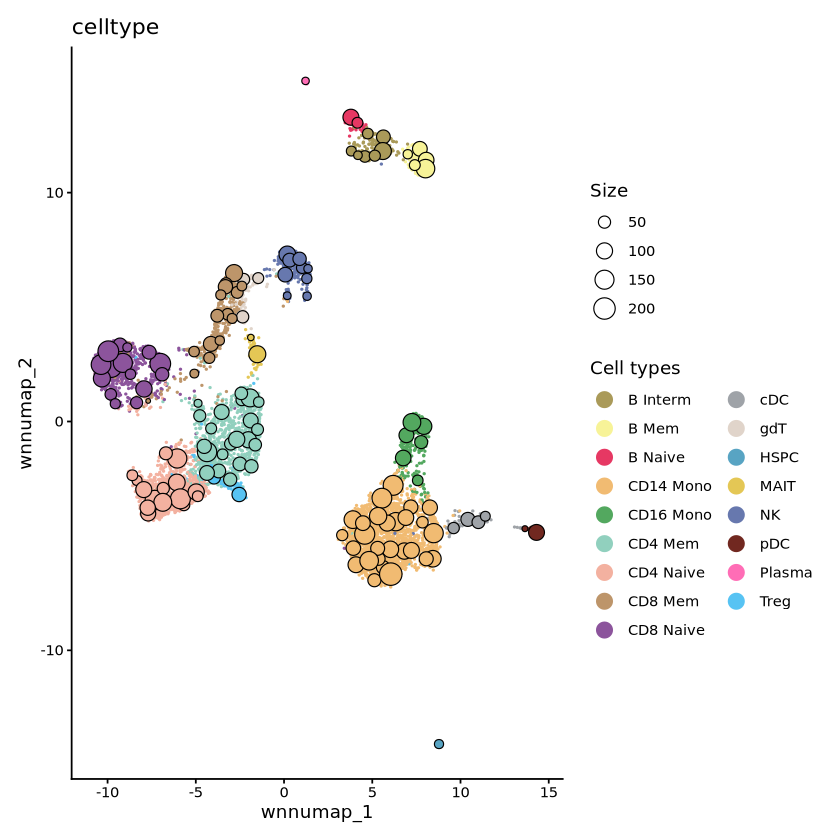

In [14]:
fig1B <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.supercell.multi,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic()  +
  guides(colour=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
         size = guide_legend(title = "Size"))

fig1B

In [15]:

umap.sc.multi <-  fig1B + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

# legend.celltypes <- ggpubr::get_legend(fig1.A+scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
#                                                          breaks = c(50,100,200,400)),
#                                        position  = c(0.5,0)) 

umap.sc.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.supercell.rna,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 


umap.sc.atac <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.supercell.atac,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 


## SEACells

umap.sea.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.seacells.rna,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

umap.sea.atac <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.seacells.atac,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

umap.sea.mofa <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.seacells.mofa,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 


## MetaQ

umap.metaq.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc =pbmc.metaq.rna,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 



umap.metaq.multi <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.metaq.multi,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 




umap.mc.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.metacell.rna,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

blank <- element_blank()

Converting layer data in assay ATAC to empty dgCMatrix

Warning message:
“Adding a dimensional reduction (pca) without the associated assay being present”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

10:45:43 UMAP embedding parameters a = 0.9922 b = 1.112

10:45:44 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

10:45:47 Initializing from normalized Laplacian + noise (using RSpectra)

10:45:48 Commencing optimization for 200 epochs, with 315986 positive edges

10:45:48 Using rng type: pcg

10:45:57 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”
Converting layer data in assay ATAC to empty dgCMatrix

Warning message:
“Adding a dimensional reduction (pca

In [16]:
umap.metaq.atac <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.metaq.atac,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

Converting layer data in assay ATAC to empty dgCMatrix

Warning message:
“Adding a dimensional reduction (pca) without the associated assay being present”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

10:57:46 UMAP embedding parameters a = 0.9922 b = 1.112

10:57:47 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

10:57:50 Initializing from normalized Laplacian + noise (using RSpectra)

10:57:51 Commencing optimization for 200 epochs, with 315914 positive edges

10:57:51 Using rng type: pcg

10:58:00 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”


In [17]:
umap.metaq.rna <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc =pbmc.metaq.rna,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic() + theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  guides(colour = "none") 

Converting layer data in assay ATAC to empty dgCMatrix

Warning message:
“Adding a dimensional reduction (pca) without the associated assay being present”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

10:59:12 UMAP embedding parameters a = 0.9922 b = 1.112

10:59:14 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

10:59:16 Initializing from normalized Laplacian + noise (using RSpectra)

10:59:17 Commencing optimization for 200 epochs, with 314880 positive edges

10:59:17 Using rng type: pcg

10:59:26 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”


In [18]:
c(0,max(metrics$size[metrics$gamma == 75]))

[1]    0 1834

In [19]:
umap.sc <- DimPlot(pbmc,group.by = "celltype",cols = color.celltypes.pbmc,reduction = "wnn.umap") + theme_classic() + ggtitle("Single cells") + NoLegend()


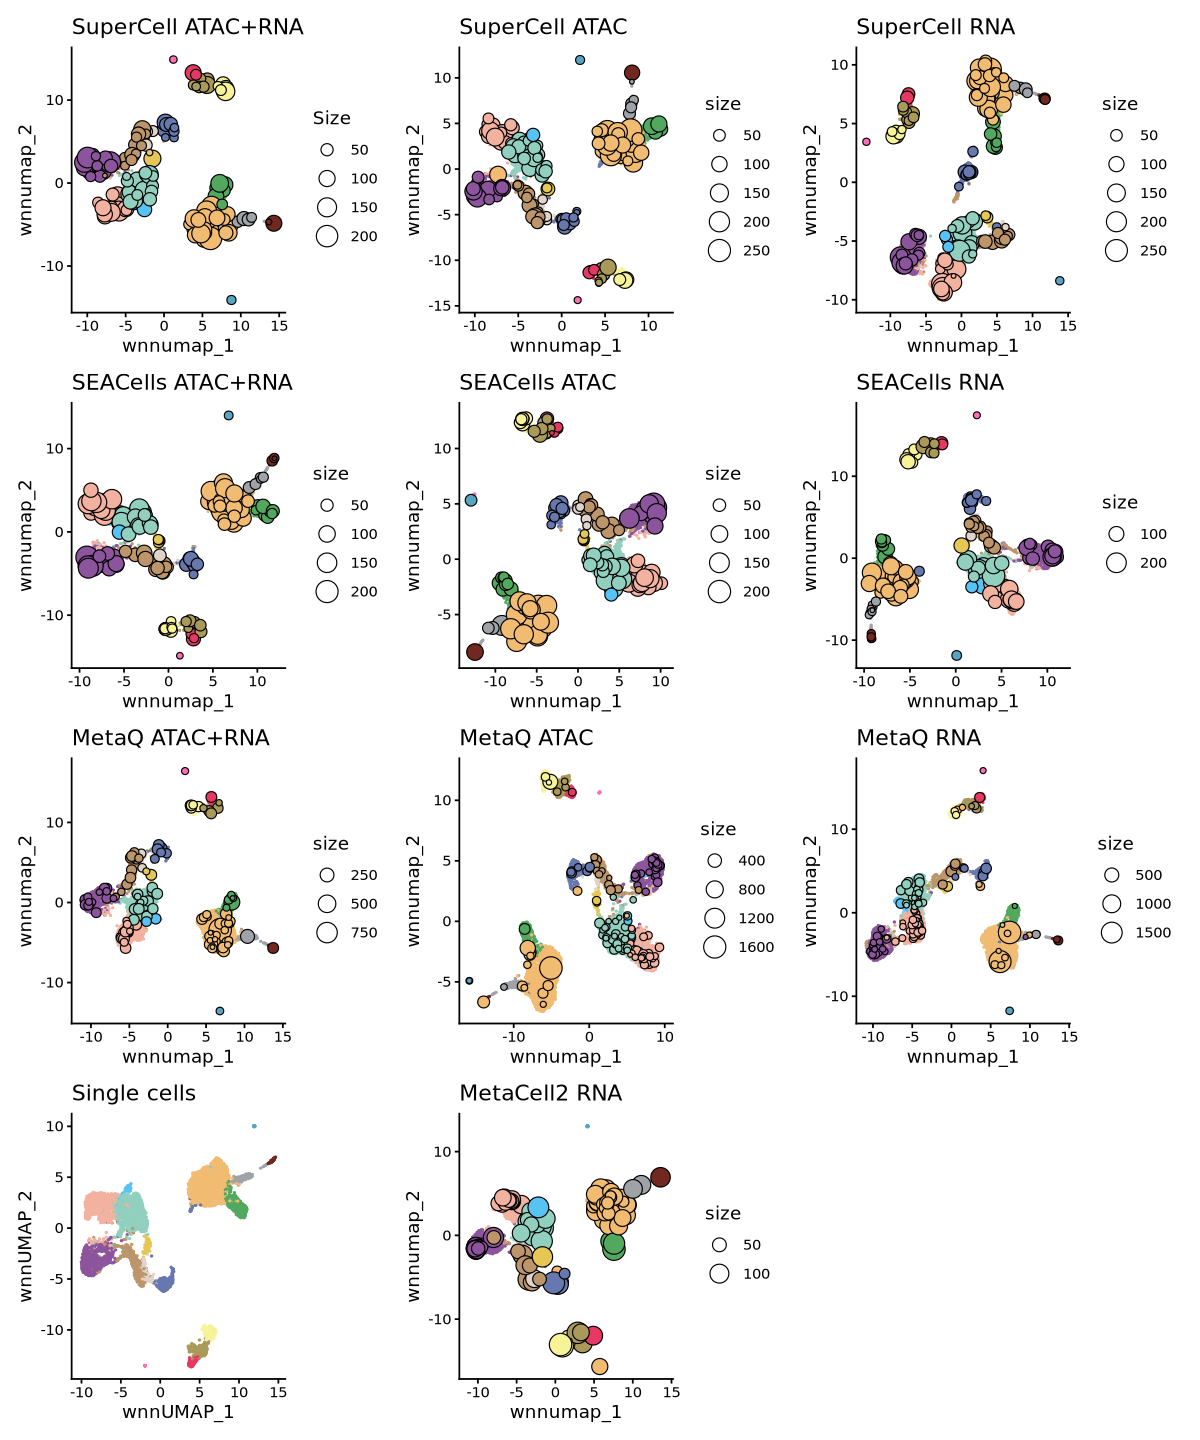

In [20]:
options(repr.plot.width=10, repr.plot.height=12)

#legend.celltypes <- ggpubr::get_legend(fig1.A +guides(
#  colour = guide_legend(ncol =2,title = "Cell types",
#                        override.aes = list(size=4)),
#  size = "none")+ theme(legend.text = element_text(size=12),
#                        legend.title = element_text(size=14))
#)

figS1A <-  wrap_plots(umap.sc.multi + ggtitle("SuperCell ATAC+RNA"),
                      umap.sc.atac + ggtitle("SuperCell ATAC") ,
                      umap.sc.rna + ggtitle("SuperCell RNA"),
                      umap.sea.mofa + ggtitle("SEACells ATAC+RNA"),
                      umap.sea.atac + ggtitle("SEACells ATAC"),
                      umap.sea.rna + ggtitle("SEACells RNA"),
                      umap.metaq.multi + ggtitle("MetaQ ATAC+RNA"),
                      umap.metaq.atac + ggtitle("MetaQ ATAC"),
                      umap.metaq.rna + ggtitle("MetaQ RNA"),
                      umap.sc, 
                      #legend.celltypes,
                      umap.mc.rna + ggtitle("MetaCell2 RNA"),
                      ncol = 3
)

figS1A 

Same scale for all

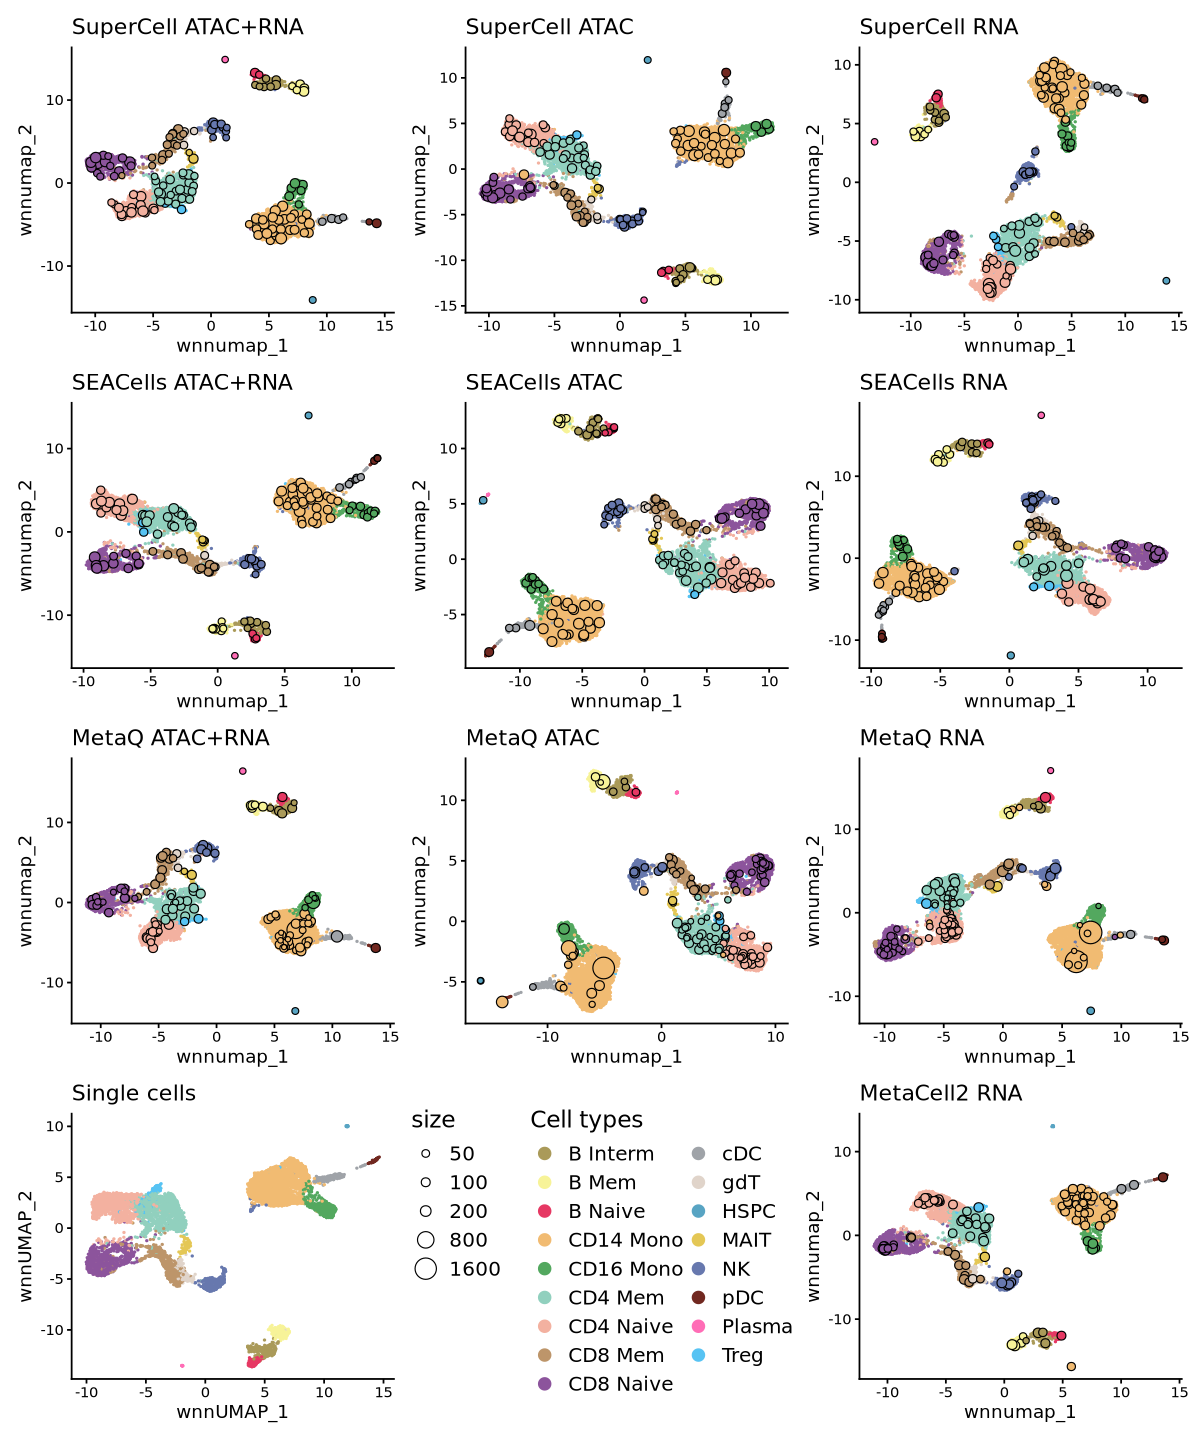

In [21]:
options(repr.plot.width=10, repr.plot.height=12)

legend.celltypes <- cowplot::get_legend(
  fig1B +
    scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
               breaks = c(50,100,200,800,1600))  +guides(
                 colour = guide_legend(ncol =2,title = "Cell types",
                                      override.aes = list(size=3)),  # One column for colors
                 size = guide_legend(ncol = 1)
               )+ theme(legend.text = element_text(size=12),
                        legend.title = element_text(size=14),
                        legend.box = "horizontal") # One column for shapes
)

figS1A <-  wrap_plots(umap.sc.multi + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600))+ ggtitle("SuperCell ATAC+RNA"),
                              umap.sc.atac  + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) +
                                ggtitle("SuperCell ATAC") ,
                              umap.sc.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("SuperCell RNA"),
                              umap.sea.mofa + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("SEACells ATAC+RNA"),
                              umap.sea.atac + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks =c(50,100,200,800,1600)) + ggtitle("SEACells ATAC"),
                              umap.sea.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("SEACells RNA"),
                              umap.metaq.multi + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("MetaQ ATAC+RNA"),
                              umap.metaq.atac + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("MetaQ ATAC"),
                              umap.metaq.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("MetaQ RNA"),
                              umap.sc,legend.celltypes,
                              umap.mc.rna + 
                                NoLegend() +
                                scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),
                                           breaks = c(50,100,200,800,1600)) + ggtitle("MetaCell2 RNA"),
                              ncol = 3
)

figS1A 

In [22]:
dir.create("../../../pdf_files/FigS1/", recursive = T, showWarnings = F )
pdf(file = "../../../pdf_files/FigS1/FigS1A_supcoembed_pbmc.pdf",height = 12,width=10)
figS1A
dev.off()

agg_record_99766196 
                  2

## Fig 2A benchmark plot

set method color

In [23]:
library(scales)
# library(ggthemes)

input.colors.10Xmultiome <- c( "#E69F00","#56B4E9","#009E73","darkgrey") #c(colorblind_pal()(8)[2:4],"darkgrey")


names(input.colors.10Xmultiome) <- c("ATAC","ATAC+RNA","RNA","None")

In [24]:


#

In [25]:

#metrics.df <- as.data.frame()

comparisons.multi <- list(
  c('SuperCell ATAC+RNA',"SEACells ATAC+RNA"),
  c('SuperCell ATAC+RNA','MetaQ ATAC+RNA'))

comparisons.atac <- list(c('SuperCell ATAC',"SEACells ATAC"),
                            c('SuperCell ATAC','MetaQ ATAC'))

comparisons.rna <- list(c('SuperCell RNA',"SEACells RNA"),
                        c('SuperCell RNA','MetaQ RNA'),
                        c('SuperCell RNA','MetaCell2 RNA'))

comparison.inter.modality <- list(c('SuperCell ATAC+RNA',"SuperCell ATAC"),
                                  c('SuperCell ATAC+RNA','SuperCell RNA')
)


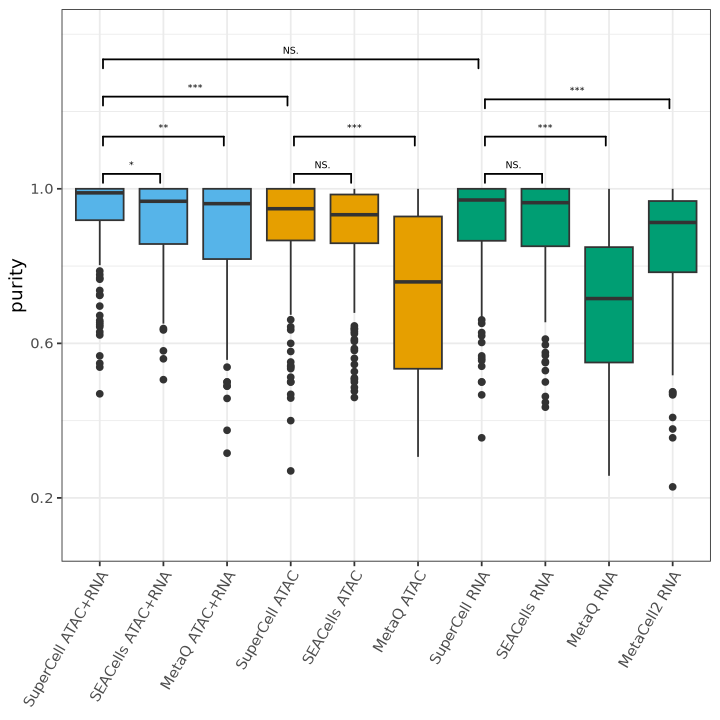

In [26]:
options(repr.plot.width=6, repr.plot.height=6)

purity.pbmc.multiome.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=purity,x = method,fill = input)) +
  geom_boxplot() +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.2, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2) +
  scale_y_continuous(breaks = c(0.2,0.6,1),limits = c(0.1,1.4)) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + theme_bw() + theme(axis.title.x = element_blank())


purity.pbmc.multiome.g75 + NoLegend()

## Final figures

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”


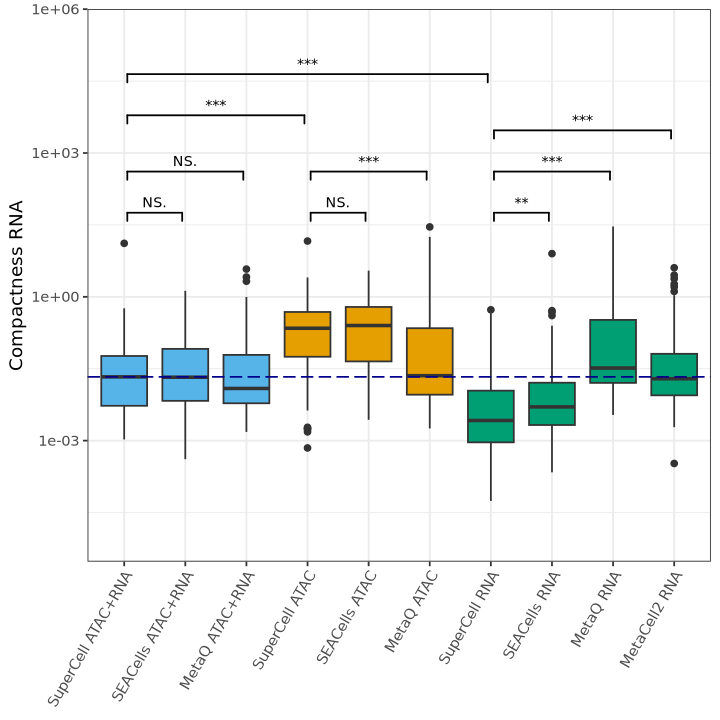

In [27]:
hline <- median(metrics[metrics$gamma %in% c(75) & metrics$method == "SuperCell ATAC+RNA","compactness_pca"])
compactness_pca.bmc.cite.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],
                                       aes(y=compactness_pca,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits = c(0.00001,300000))+  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash")  +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 3.5) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Compactness RNA") + theme_bw() + theme(axis.title.x = element_blank())


compactness_pca.bmc.cite.g75 + NoLegend()

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”


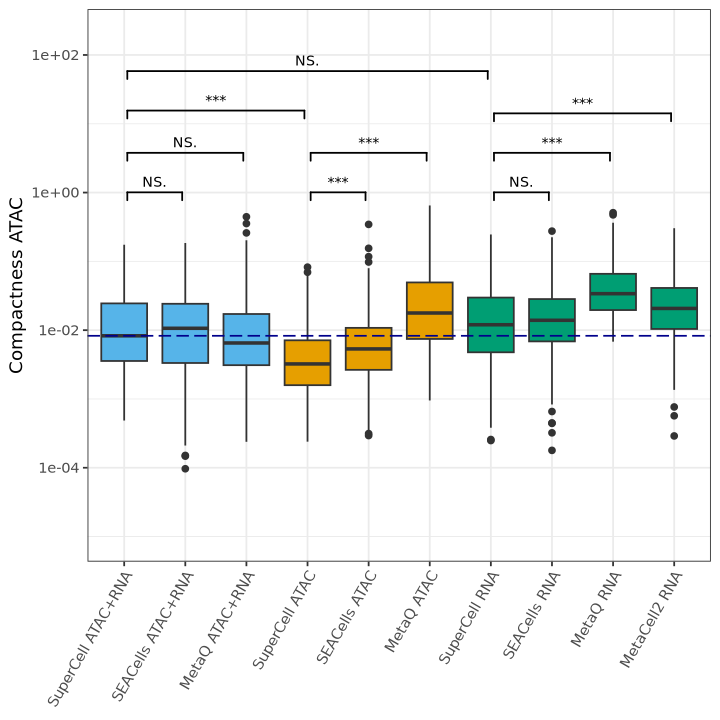

In [28]:
hline <- median(metrics[metrics$gamma %in% c(75) & metrics$method == "SuperCell ATAC+RNA","compactness_lsi"])

compactness_lsi.bmc.cite.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=compactness_lsi,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits = c(0.00001,200))+
  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash")  +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 1) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Compactness ATAC") + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())


compactness_lsi.bmc.cite.g75 + NoLegend()

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”


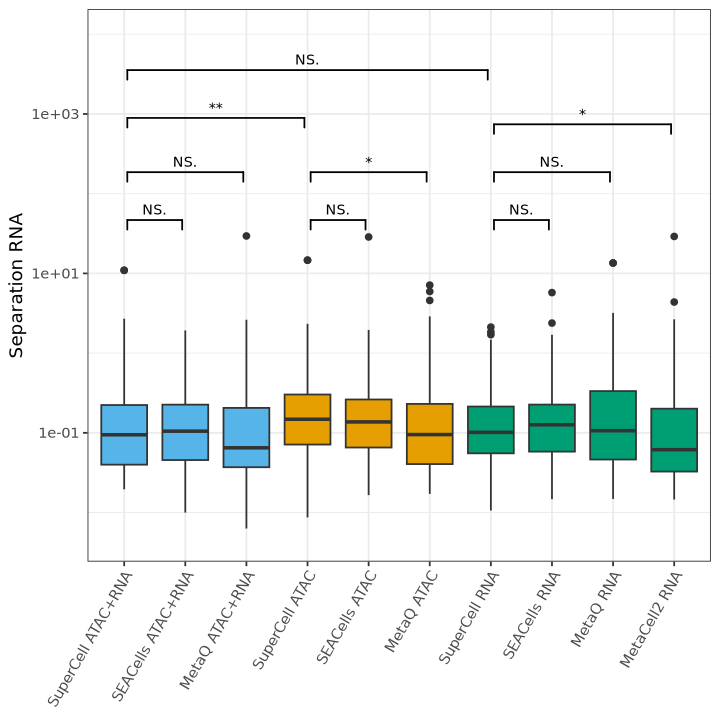

In [29]:
separation_pca.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=separation_pca,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits= c(0.005,10000))+
  #facet_wrap("gamma",nrow = 1) +
  #ylim(c(0,1.425)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 2.75) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Separation RNA") + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())


separation_pca.g75 + NoLegend()

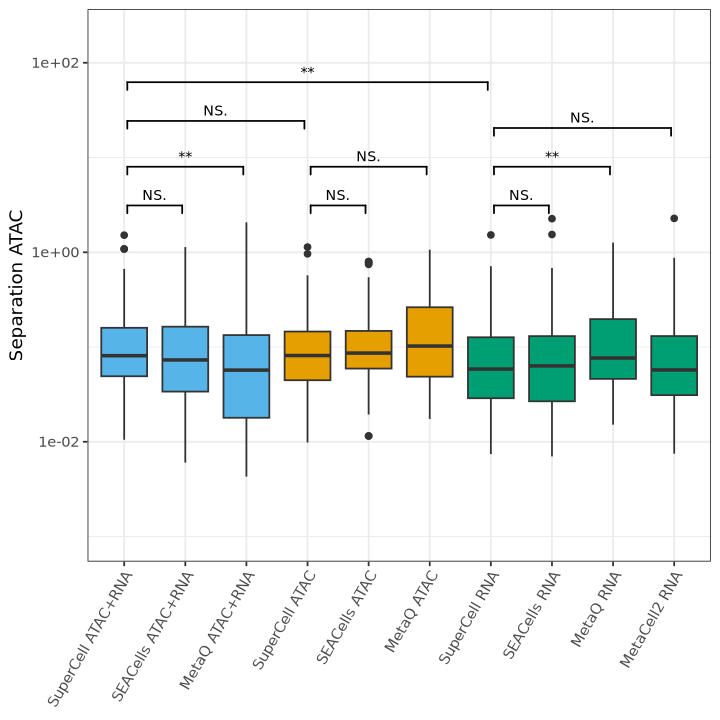

In [30]:
separation_lsi.g75 <- ggplot(metrics[metrics$gamma %in% c(75),],aes(y=separation_lsi,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits = c(0.001,200))+
  #facet_wrap("gamma",nrow = 1) +
  #ylim(c(0,1.425)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 1.25) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Separation ATAC") + theme(axis.title.x = element_blank()) + theme_bw() + theme(axis.title.x = element_blank())


separation_lsi.g75 + NoLegend()

New version not reversed scaling without random.
We perform min max scaling of compactness/sepration including semi sup/ sup noisy and test knn SuperCell runs.
metacell of size 1 has a compactness of 0

In [145]:
library(dplyr)
bench.75.no.random <- metrics[metrics$gamma %in% c(75) & metrics$method != "Random None",]
bench.75.no.random$pct_known <- 0
bench.75.no.random$k_nn <- 30

bench.75.no.random[bench.75.no.random$size == 1,]



bench.75.no.random$pct_known <- 0
bench.75.no.random$guiding_labels <- NA

# add semi sup tests for scaling comp/sep
semi.sup.multi <- read.csv(paste0(datadir,
                                  "/output/pbmcMultiome//SuperCellMulti/testSemiSup/g75/results_test_semisup.csv"),
                           row.names = 1)
semi.sup.multi$gamma <- 75
semi.sup.multi$input <- "ATAC+RNA" 
semi.sup.multi$tool <- "ssSuperCell" 
semi.sup.multi$method <- "SuperCell ATAC+RNA" 
semi.sup.multi$guiding_labels <- NA
semi.sup.multi$k_nn <- 30




keep.shuffling <-c("guiding_label_0_pct_shuffled",
                   "guiding_label_1_pct_shuffled",
                   "guiding_label_5_pct_shuffled",
                   "guiding_label_10_pct_shuffled",
                   "guiding_label_20_pct_shuffled",
                   "unsupervised")

sup.multi <- read.csv(paste0(datadir,
                             "/output/pbmcMultiome/SuperCellMulti/testShufflingSup/g75/results_test_shuffle_closest.csv"),
                      row.names = 1)
sup.multi <- sup.multi[sup.multi$guiding_labels %in% keep.shuffling,]
sup.multi$gamma <- 75
sup.multi$input <- "ATAC+RNA" 
sup.multi$tool <- "supSuperCell" 
sup.multi$method <- "SuperCell ATAC+RNA" 
sup.multi$pct_known <- 100
sup.multi$k_nn <- 30


## add test KNN





unsup_knn_g75 <- read.csv(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testKNN/g75/results_test_k_nn.csv"))
unsup_knn_g75$gamma <- 75
unsup_knn_g75$input <- "ATAC+RNA" 
unsup_knn_g75$tool <- "SuperCell_testKNN" 
unsup_knn_g75$method <- "SuperCell ATAC+RNA" 
unsup_knn_g75$pct_known <- 0




sup_knn_g75 <- read.csv(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testKNN_sup/g75/results_test_k_nn.csv"))
sup_knn_g75$gamma <- 75
sup_knn_g75$input <- "ATAC+RNA" 
sup_knn_g75$tool <- "supSuperCell_testKNN" 
sup_knn_g75$method <- "SuperCell ATAC+RNA" 
sup_knn_g75$pct_known <- 100

test_knn <- rbind(unsup_knn_g75,
                  sup_knn_g75[,colnames(unsup_knn_g75)])
test_knn$guiding_labels <- NA



cn <- colnames(bench.75.no.random)[colnames(bench.75.no.random) %in% colnames(sup.multi)]

bench.75.no.random <- rbind(bench.75.no.random[,cn],semi.sup.multi[,cn],
                            sup.multi[,cn],test_knn[,cn])

#bench.75.no.random <- bench.75.no.random[bench.75.no.random$size > 1,]
bench.75.no.random$compactness_lsi[bench.75.no.random$size == 1] <- 0
bench.75.no.random$compactness_pca[bench.75.no.random$size == 1] <- 0

,orig.ident,nCount_RNA,nFeature_RNA,nCount_SCT,nFeature_SCT,nCount_ATAC,nFeature_ATAC,orig.ident_purity,seurat_annotations,seurat_annotations_purity,⋯,separation_lsi,asw_lsi_diffusion,asw_pca_diffusion,input,gamma,method,tool,purity,pct_known,k_nn
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>
Metacell_12916,RNA,4247,1955,4141,1955,19406,13470,1,CD14 Mono,1,⋯,0.02150282,0,0,ATAC+RNA,75,MetaQ ATAC+RNA,MetaQ,1,0,30
Metacell_13016,RNA,7085,2872,4625,2736,14788,11085,1,CD16 Mono,1,⋯,0.10762070,0,0,ATAC+RNA,75,MetaQ ATAC+RNA,MetaQ,1,0,30
Metacell_13616,RNA,4154,2029,4086,2027,11659,8730,1,CD14 Mono,1,⋯,0.04878765,0,0,ATAC+RNA,75,MetaQ ATAC+RNA,MetaQ,1,0,30
Metacell_13417,RNA,14908,4751,4010,2342,25648,15912,1,CD14 Mono,1,⋯,0.18739338,0,0,RNA,75,MetaQ RNA,MetaQ,1,0,30


In [146]:
table(bench.75.no.random$method,bench.75.no.random$tool)
table(bench.75.no.random[bench.75.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),"tool"],
     bench.75.no.random[bench.75.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),"k_nn"])

table(bench.75.no.random[bench.75.no.random$tool %in% c("ssSuperCell"),"pct_known"])
table(bench.75.no.random[bench.75.no.random$tool %in% c("supSuperCell"),"guiding_labels"])

                    
                     MetaCell2 MetaQ SEACells SuperCell SuperCell_testKNN
  SuperCell ATAC+RNA         0     0        0       138               966
  SEACells ATAC+RNA          0     0      138         0                 0
  MetaQ ATAC+RNA             0   136        0         0                 0
  SuperCell ATAC             0     0        0       138                 0
  SEACells ATAC              0     0      138         0                 0
  MetaQ ATAC                 0   138        0         0                 0
  SuperCell RNA              0     0        0       138                 0
  SEACells RNA               0     0      138         0                 0
  MetaQ RNA                  0   138        0         0                 0
  MetaCell2 RNA            140     0        0         0                 0
                    
                     ssSuperCell supSuperCell supSuperCell_testKNN
  SuperCell ATAC+RNA         690          828                  966
  SEACells

                      
                        10  20  30  40  60  80 100
  SuperCell_testKNN    138 138 138 138 138 138 138
  supSuperCell_testKNN 138 138 138 138 138 138 138


  0  25  50  75 100 
138 138 138 138 138 


 guiding_label_0_pct_shuffled guiding_label_10_pct_shuffled 
                          138                           138 
 guiding_label_1_pct_shuffled guiding_label_20_pct_shuffled 
                          138                           138 
 guiding_label_5_pct_shuffled                  unsupervised 
                          138                           138 

In [147]:




minMaxScaling <- function(x) {
  y <- (x-min(x))/(max(x)-min(x))
  return(y)
}



bench.75.no.random$compactness_pca_scaled <- minMaxScaling(bench.75.no.random$compactness_pca)
bench.75.no.random$compactness_lsi_scaled <- minMaxScaling(bench.75.no.random$compactness_lsi)

bench.75.no.random$multimodal_compactness <- (bench.75.no.random$compactness_pca_scaled + bench.75.no.random$compactness_lsi_scaled) / 2


bench.75.no.random$separation_pca_norm <- (bench.75.no.random$separation_pca)
bench.75.no.random$separation_lsi_norm <- (bench.75.no.random$separation_lsi)

bench.75.no.random$separation_pca_scaled <- minMaxScaling(bench.75.no.random$separation_pca_norm)
bench.75.no.random$separation_lsi_scaled <- minMaxScaling(bench.75.no.random$separation_lsi_norm)

bench.75.no.random$multimodal_separation <- (bench.75.no.random$separation_pca_scaled + bench.75.no.random$separation_lsi_scaled) / 2

#check min max used for scaling
bench.75.no.random[which.min(bench.75.no.random$compactness_lsi),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$compactness_lsi),c("method","tool")]

bench.75.no.random[which.min(bench.75.no.random$compactness_pca),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$compactness_pca),c("method","tool")]

bench.75.no.random[which.min(bench.75.no.random$separation_lsi),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$separation_lsi),c("method","tool")]

bench.75.no.random[which.min(bench.75.no.random$separation_pca),c("method","tool")]
bench.75.no.random[which.max(bench.75.no.random$separation_pca),c("method","tool")]

bench.75.unsup <- bench.75.no.random[!bench.75.no.random$tool %in% 
                                     c("ssSuperCell","supSuperCell",
                                       "supSuperCell_testKNN","SuperCell_testKNN"),]

table(bench.75.unsup$method,bench.75.unsup$tool)

# step_increase <- 0.075*0.25/(limits$ymax-limits$ymin)





,method,tool
,<fct>,<chr>
Metacell_12916,MetaQ ATAC+RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_10818,MetaQ ATAC,MetaQ


,method,tool
,<fct>,<chr>
Metacell_12916,MetaQ ATAC+RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_12617,MetaQ RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_6616,MetaQ ATAC+RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_13221,MetaCell2 RNA,MetaCell2


,method,tool
,<fct>,<chr>
Metacell_18100,MetaQ ATAC+RNA,MetaQ


,method,tool
,<fct>,<chr>
Metacell_7016,MetaQ ATAC+RNA,MetaQ


                    
                     MetaCell2 MetaQ SEACells SuperCell
  SuperCell ATAC+RNA         0     0        0       138
  SEACells ATAC+RNA          0     0      138         0
  MetaQ ATAC+RNA             0   136        0         0
  SuperCell ATAC             0     0        0       138
  SEACells ATAC              0     0      138         0
  MetaQ ATAC                 0   138        0         0
  SuperCell RNA              0     0        0       138
  SEACells RNA               0     0      138         0
  MetaQ RNA                  0   138        0         0
  MetaCell2 RNA            140     0        0         0

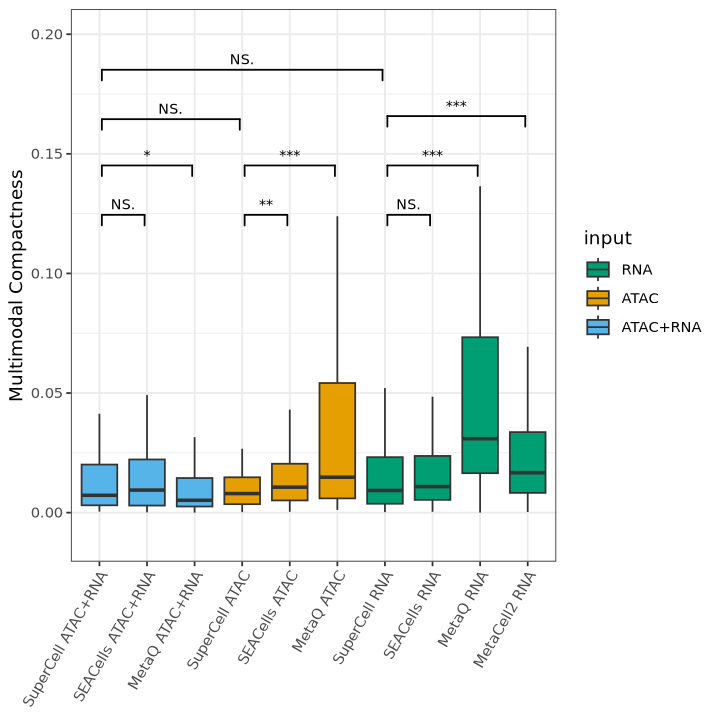

In [34]:

multimodal_compactness.75 <- ggplot(bench.75.unsup,
                                    aes(y=multimodal_compactness,x = method,fill = input)) +
  geom_boxplot(outlier.shape = NA) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(-0.01,0.2)) + theme(axis.title.x = element_blank()) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.095,tip_length = 0.0075)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.095,tip_length = 0.0075) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.095,tip_length = 0.0075) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 0.135,tip_length = 0.0075) +
  theme_bw() + theme(axis.title.x = element_blank())
multimodal_compactness.75

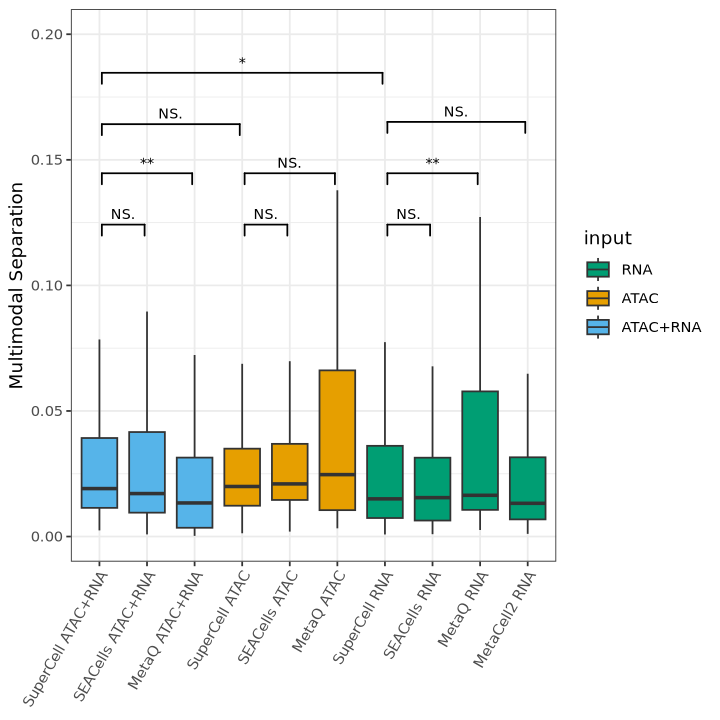

In [35]:




# limits <- bench.75.no.random[bench.75.no.random$method != "Random None",] %>%
#   group_by(method) %>%
#   summarize(
#     ymin = quantile(multimodal_separation, 0.25) - 1.5 * IQR(multimodal_separation),
#     ymax = quantile(multimodal_separation, 0.75) + 1.5 * IQR(multimodal_separation)
#   ) %>%
#   ungroup() %>%
#   summarize(
#     ymin = min(ymin),
#     ymax = max(ymax)
#   )
# step_increase <- 0.075*0.25/(limits$ymax-limits$ymin)


multimodal_separation.75 <- ggplot(bench.75.unsup,
                                   aes(y=multimodal_separation,x = method,fill = input)) +
  geom_boxplot(outlier.shape = NA) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.20)) + theme(axis.title.x = element_blank()) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.095,tip_length = 0.0075)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.095,tip_length = 0.0075) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.095,tip_length = 0.0075) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 0.135,tip_length = 0.0075) +
  theme_bw() + theme(axis.title.x = element_blank())
multimodal_separation.75
#
# plot_data <- ggplot_build(multimodal_separation.75)
# y_limits <- plot_data$layout$panel_params[[1]]$y.range
#
# step_increase <-  .23*(1.4-1.1)
#
#
# sig.multimodal.separation.g75 <- ggplot(bench.75[bench.75$method != "Random None",],aes(y=multimodal_separation,x = method,fill = input)) +
#   geom_boxplot(outlier.shape = NA) +
#   
#   geom_signif(comparisons = comparisons,step_increase=step_increase,map_signif_level=T,extend_line = -0.005,textsize = 3.5) +
#   geom_signif(comparisons = comparison.inter.modality,step_increase=step_increase,map_signif_level=T,extend_line = -0.005,textsize = 3.5) +
#   coord_cartesian(ylim = c(1.1, 1.4))  + theme_void() + NoLegend()
#
#
# full.multimodal.separation.g75 <- cowplot::plot_grid(sig.multimodal.separation.g75,multimodal_separation.75+ NoLegend(), rel_heights = c(0.2,0.8),align = "v",ncol = 1)
#
# full.multimodal.separation.g75

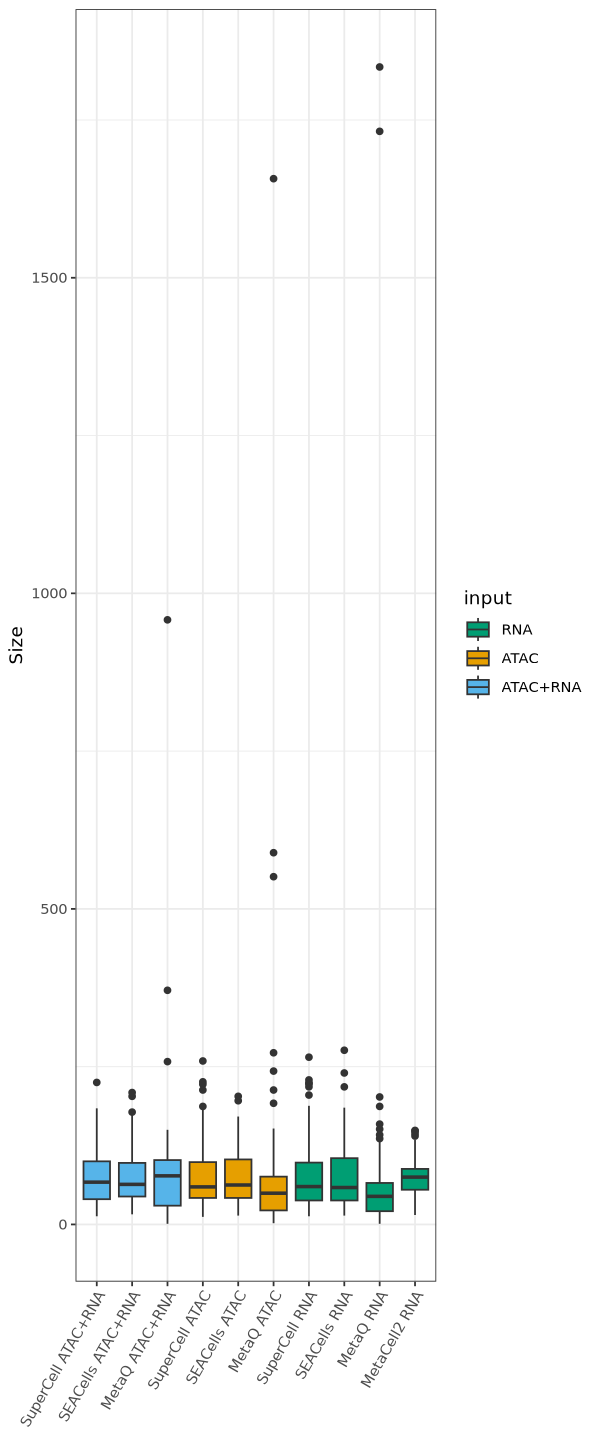

In [83]:
size.g75 <- ggplot(bench.75.unsup,aes(y=size,x = method,fill = input)) +
  geom_boxplot() +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Size") + theme(axis.title.x = element_blank()) + NoLegend()  + theme_bw() + theme(axis.title.x = element_blank())
size.g75

## gamma 20
singleton from metaQ not plotted on logscale (warnings)

Warning message in scale_y_log10(limits = c(1e-06, 1e+06)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 1e+06)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 1e+06)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 1e+06)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-06, 1e+06)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 27 rows conta

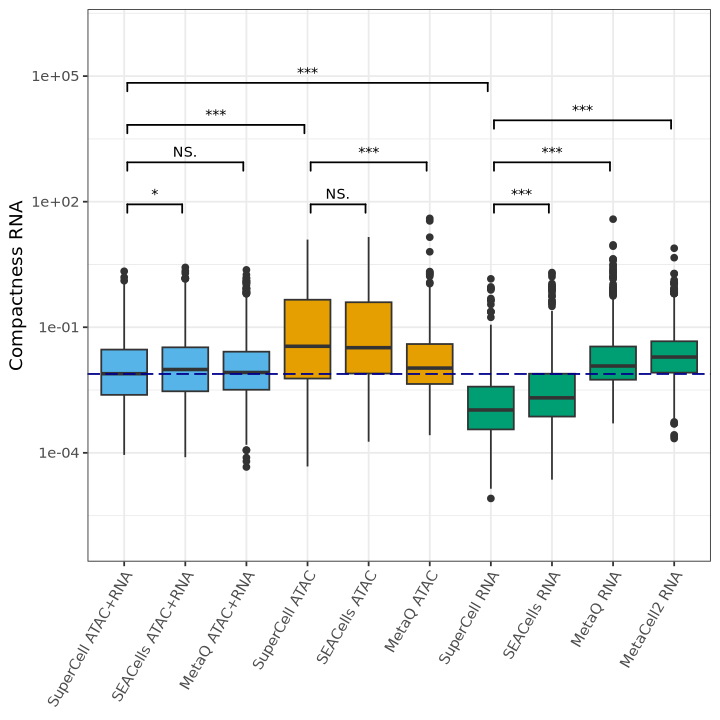

In [37]:
bench.20 <- metrics[metrics$gamma == 20,]
bench.20$compactness_lsi[bench.20$size == 1] <- 0
bench.20$compactness_pca[bench.20$size == 1] <- 0

hline <- median(bench.20[ bench.20$method == "SuperCell ATAC+RNA","compactness_pca"])
compactness_pca.bmc.cite.g20 <- ggplot(bench.20,aes(y=compactness_pca,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits = c(0.000001,1000000))+  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash")  +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 3.5) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Compactness RNA")  + theme_bw() + theme(axis.title.x = element_blank())


compactness_pca.bmc.cite.g20 + NoLegend()

Warning message in scale_y_log10(limits = c(1e-05, 1000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-05, 1000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-05, 1000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-05, 1000)):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(limits = c(1e-05, 1000)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Removed 27 rows containing

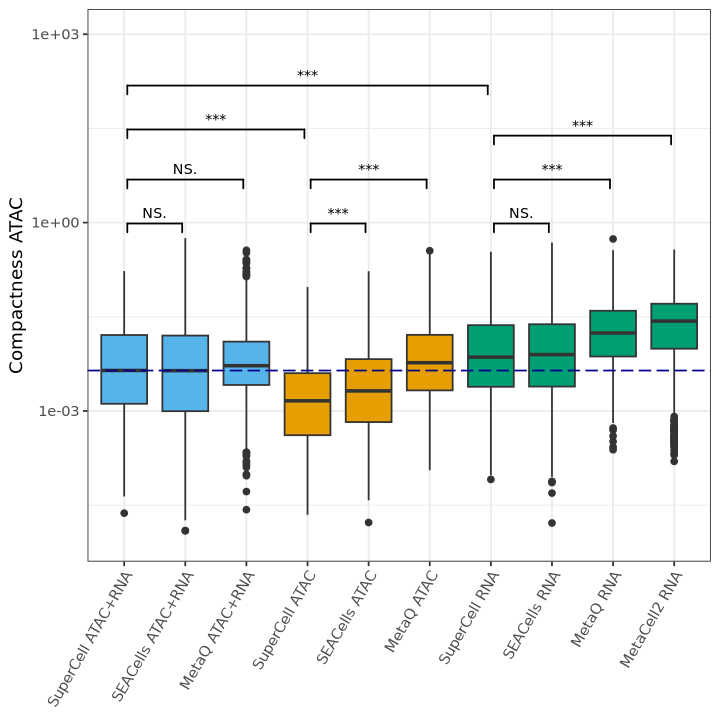

In [38]:
hline <- median(bench.20[bench.20$method == "SuperCell ATAC+RNA","compactness_lsi"])

compactness_lsi.bmc.cite.g20 <- ggplot(bench.20,aes(y=compactness_lsi,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits =  c(0.00001,1000))+
  geom_hline(yintercept =hline,color = "darkblue",linetype = "longdash")  +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 1.25) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Compactness ATAC") + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())


compactness_lsi.bmc.cite.g20 + NoLegend()

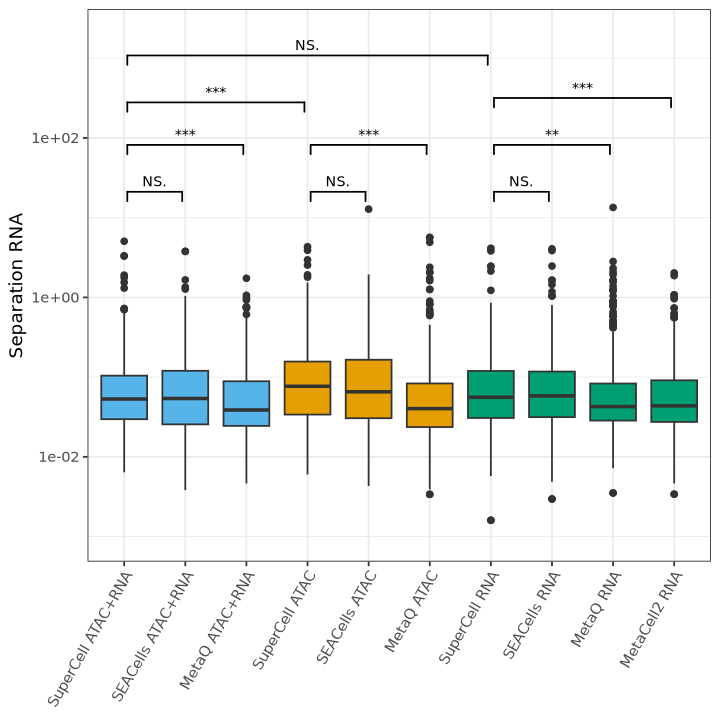

In [39]:
separation_pca.g20 <- ggplot(bench.20,aes(y=separation_pca,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits = c(0.001,2000))+
  #facet_wrap("gamma",nrow = 1) +
  #ylim(c(0,1.425)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 2.25) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Separation RNA") + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())


separation_pca.g20 + NoLegend()

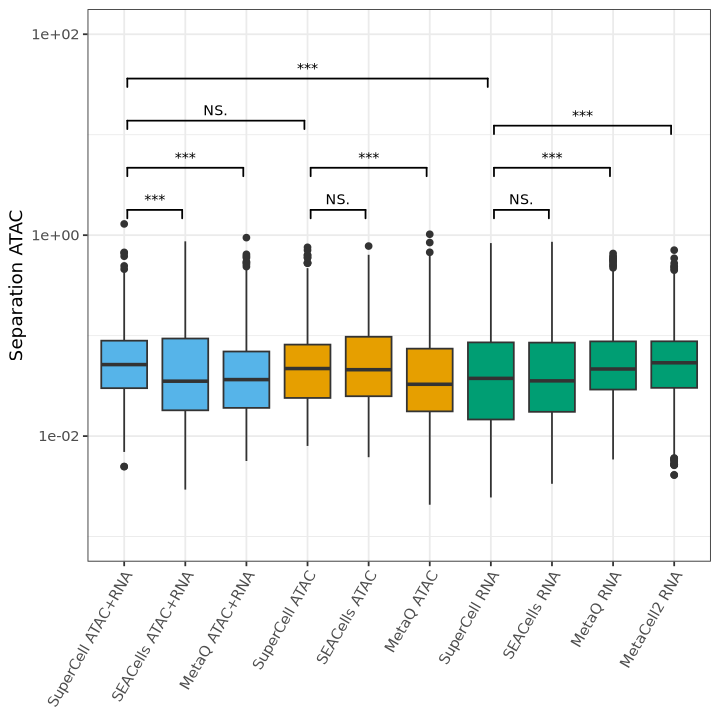

In [40]:
separation_lsi.g20 <- ggplot(bench.20,aes(y=separation_lsi,x = method,fill = input)) +
  geom_boxplot() + scale_y_log10(limits = c(0.001,100))+
  #facet_wrap("gamma",nrow = 1) +
  #ylim(c(0,1.425)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.15,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 1) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Separation ATAC") + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())


separation_lsi.g20 + NoLegend()

In [41]:
bench.20.no.random <- bench.20[bench.20$gamma %in% c(20) & bench.20$method != "Random None",]
bench.20.no.random$k_nn <- 30

dim(bench.20.no.random[bench.20.no.random$size == 1,])

## add test KNN

unsup_knn_g20 <- read.csv(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testKNN/g20/results_test_k_nn.csv"))
unsup_knn_g20$gamma <- 20
unsup_knn_g20$input <- "ATAC+RNA" 
unsup_knn_g20$tool <- "SuperCell_testKNN" 
unsup_knn_g20$method <- "SuperCell ATAC+RNA" 




sup_knn_g20 <- read.csv(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testKNN_sup/g20/results_test_k_nn.csv"))
sup_knn_g20$gamma <- 20
sup_knn_g20$input <- "ATAC+RNA" 
sup_knn_g20$tool <- "supSuperCell_testKNN" 
sup_knn_g20$method <- "SuperCell ATAC+RNA" 
sup_knn_g20$pct_known <- 100

test_knn <- rbind(unsup_knn_g20,
                  sup_knn_g20[,colnames(unsup_knn_g20)])



cn <- colnames(bench.20.no.random)[colnames(bench.20.no.random) %in% colnames(test_knn)]

bench.20.no.random <- rbind(bench.20.no.random[,cn],test_knn[,cn])

#bench.75.no.random <- bench.75.no.random[bench.75.no.random$size > 1,]
bench.20.no.random$compactness_lsi[bench.20.no.random$size == 1] <- 0
bench.20.no.random$compactness_pca[bench.20.no.random$size == 1] <- 0

[1] 27 33

In [42]:
table(bench.20.no.random$method,bench.20.no.random$tool)
table(bench.20.no.random[bench.20.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),"tool"],
     bench.20.no.random[bench.20.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),"k_nn"])


                    
                     MetaCell2 MetaQ SEACells SuperCell SuperCell_testKNN
  SuperCell ATAC+RNA         0     0        0       520              3640
  SEACells ATAC+RNA          0     0      520         0                 0
  MetaQ ATAC+RNA             0   473        0         0                 0
  SuperCell ATAC             0     0        0       520                 0
  SEACells ATAC              0     0      520         0                 0
  MetaQ ATAC                 0   520        0         0                 0
  SuperCell RNA              0     0        0       520                 0
  SEACells RNA               0     0      520         0                 0
  MetaQ RNA                  0   512        0         0                 0
  MetaCell2 RNA            529     0        0         0                 0
                    
                     supSuperCell_testKNN
  SuperCell ATAC+RNA                 3640
  SEACells ATAC+RNA                     0
  MetaQ ATAC+RNA  

                      
                        10  20  30  40  60  80 100
  SuperCell_testKNN    520 520 520 520 520 520 520
  supSuperCell_testKNN 520 520 520 520 520 520 520

In [43]:

#check min max used for scaling

print("comapctness lsi")
bench.20.no.random[which.min(bench.20.no.random$compactness_lsi),c("method","tool")]
bench.20.no.random[which.max(bench.20.no.random$compactness_lsi),c("method","tool")]

print("comapctness pca")
bench.20.no.random[which.min(bench.20.no.random$compactness_pca),c("method","tool")]
bench.20.no.random[which.max(bench.20.no.random$compactness_pca),c("method","tool")]

print("separation lsi")
bench.20.no.random[which.min(bench.20.no.random$separation_lsi),c("method","tool")]
bench.20.no.random[which.max(bench.20.no.random$separation_lsi),c("method","tool")]

print("separation pca")
bench.20.no.random[which.min(bench.20.no.random$separation_pca),c("method","tool")]
bench.20.no.random[which.max(bench.20.no.random$separation_pca),c("method","tool")]

[1] "comapctness lsi"


,method,tool
,<fct>,<chr>
Metacell_520,SuperCell ATAC+RNA,SuperCell


,method,tool
,<fct>,<chr>
Metacell_2983,SEACells ATAC+RNA,SEACells


[1] "comapctness pca"


,method,tool
,<fct>,<chr>
Metacell_520,SuperCell ATAC+RNA,SuperCell


...

,method,tool
,<fct>,<chr>
Metacell_1658,MetaQ ATAC,MetaQ


,method,tool
,<fct>,<chr>
7259,SuperCell ATAC+RNA,supSuperCell_testKNN


[1] "separation pca"


,method,tool
,<fct>,<chr>
Metacell_1291,SuperCell RNA,SuperCell


,method,tool
,<fct>,<chr>
7280,SuperCell ATAC+RNA,supSuperCell_testKNN


In [44]:


bench.20.no.random$separation_pca_scaled <- minMaxScaling(bench.20.no.random$separation_pca)
bench.20.no.random$separation_lsi_scaled <- minMaxScaling(bench.20.no.random$separation_lsi)

bench.20.no.random$multimodal_separation <- (bench.20.no.random$separation_pca_scaled + bench.20.no.random$separation_lsi_scaled) / 2

bench.20.no.random$compactness_pca_scaled <- minMaxScaling(bench.20.no.random$compactness_pca)
bench.20.no.random$compactness_lsi_scaled <- minMaxScaling(bench.20.no.random$compactness_lsi)

bench.20.no.random$multimodal_compactness <- (bench.20.no.random$compactness_pca_scaled + bench.20.no.random$compactness_lsi_scaled) / 2

New version not reversed scaling without radom metacells

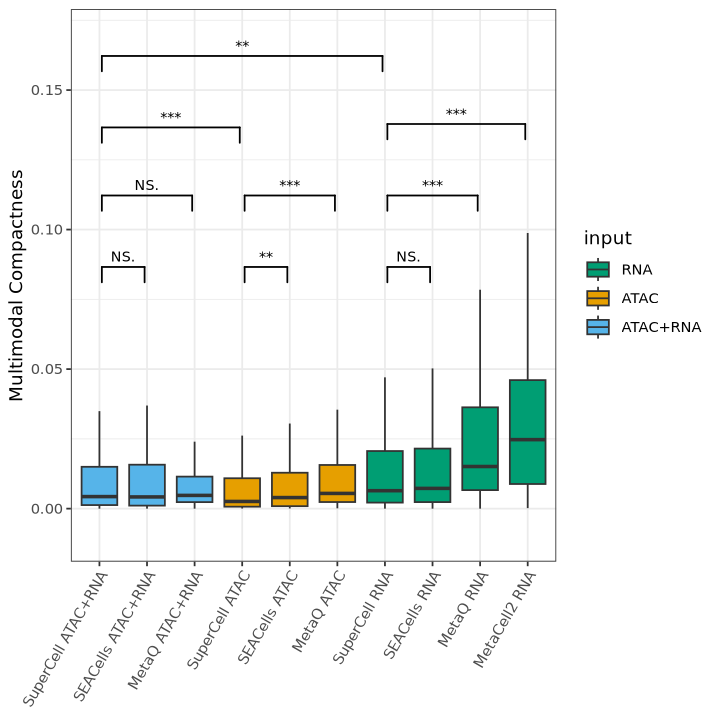

In [45]:


bench.20.unsup <- bench.20.no.random[!bench.20.no.random$tool %in% c("SuperCell_testKNN","supSuperCell_testKNN"),]

sig.multimodal.compactness.g20  <- ggplot(bench.20.unsup,aes(y=multimodal_compactness,x = method,fill = input)) +
  geom_boxplot(outlier.shape = NA) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(-0.01,0.17)) + theme(axis.title.x = element_blank()) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.05,tip_length = 0.0075)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.05,tip_length = 0.0075) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.05,tip_length = 0.0075) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 0.1,tip_length = 0.0075) +
  theme_bw() + theme(axis.title.x = element_blank())

sig.multimodal.compactness.g20




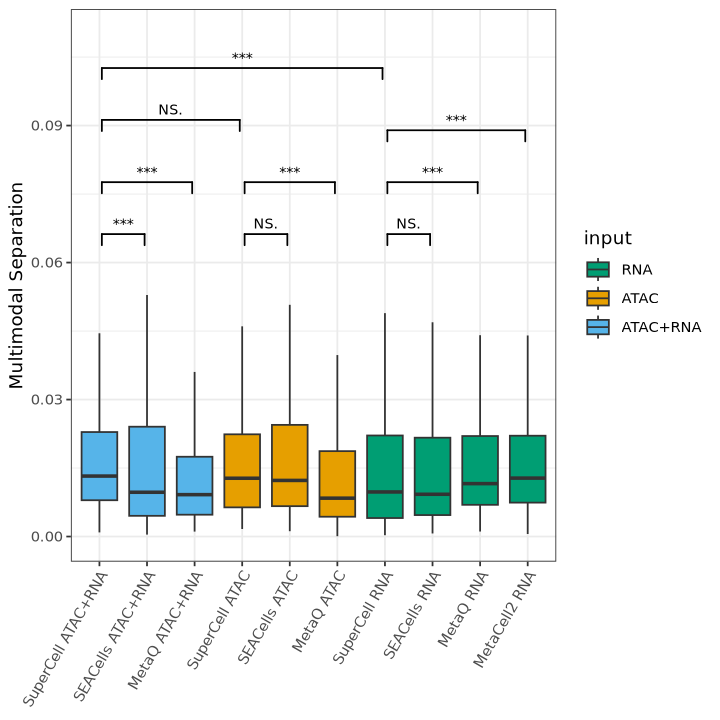

In [51]:

sig.multimodal.separation.g20 <- ggplot(bench.20.unsup,aes(y=multimodal_separation,x = method,fill = input)) +
  geom_boxplot(outlier.shape = NA) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.05,tip_length = 0.0075)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.05,tip_length = 0.0075) +
  geom_signif(comparisons = comparisons.rna,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position = 0.05,tip_length = 0.0075) +
  geom_signif(comparisons = comparison.inter.modality,step_increase=0.035,map_signif_level=T,extend_line = -0.005,textsize = 3, y_position  = 0.075,tip_length = 0.0075) +
  coord_cartesian(ylim = c(0, 0.11))+
  scale_x_discrete(guide = guide_axis(angle = 60)) + theme(axis.title.x = element_blank()) + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Separation") + NoLegend()  + theme_bw() + theme(axis.title.x = element_blank())
sig.multimodal.separation.g20


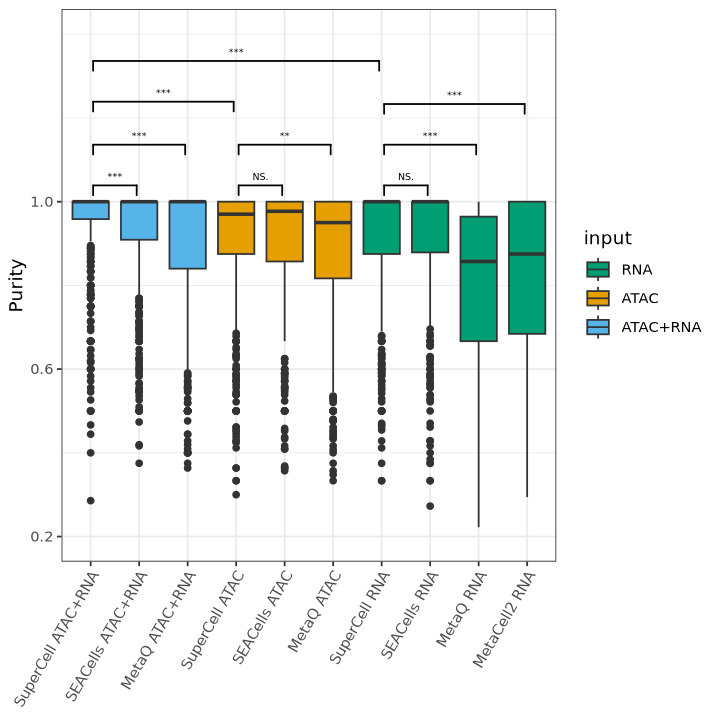

In [55]:


seurat_annotations_purity.g20 <- ggplot(bench.20.unsup,aes(y=seurat_annotations_purity,x = method,fill = input)) +
  geom_boxplot() +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Purity") + theme(axis.title.x = element_blank())




step_increase <- 0.23*(1.3-1.03)

sig.seurat_annotations.g20 <- ggplot(bench.20.unsup,aes(y=seurat_annotations_purity,x = method,fill = input)) +
  geom_boxplot() +
  #facet_wrap("gamma",nrow = 1) +
  #ylim(c(0,1.425)) +
  geom_signif(comparisons = comparisons.multi,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparisons.atac,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparisons.rna,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2)+
  geom_signif(comparisons = comparison.inter.modality,y_position =1.2, ,step_increase=0.125,map_signif_level=T,extend_line = -0.005,textsize = 2) +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  scale_y_continuous(breaks = c(0.2,0.6,1),limits = c(0.2,1.4)) +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Purity")+  NoLegend()    + theme_bw() + theme(axis.title.x = element_blank())
# Hides outliers
#coord_cartesian(ylim = c(0, limits$ymax))   # Sets y-axis limits

sig.seurat_annotations.g20

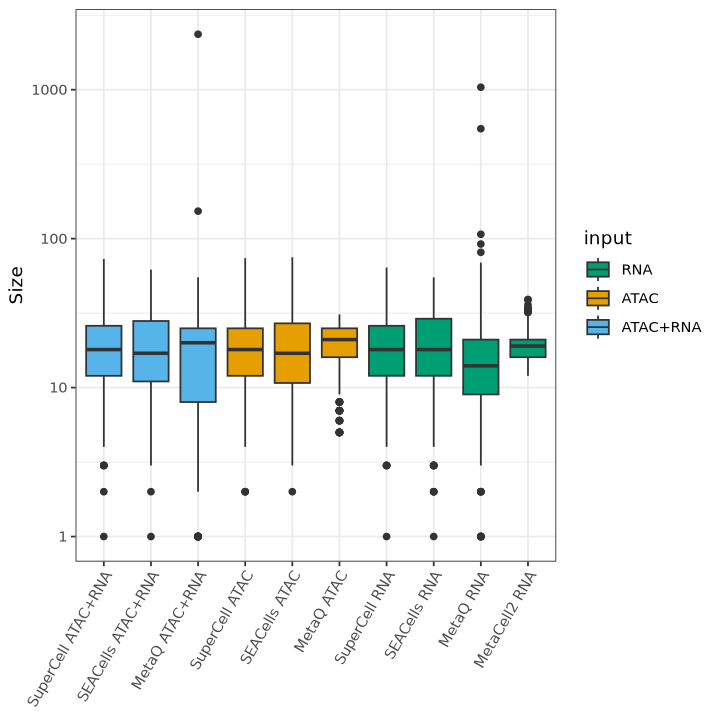

In [57]:
size.g20 <- ggplot(bench.20[bench.20$method != "Random None",],aes(y=size,x = method,fill = input)) +
  geom_boxplot() +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  scale_y_log10() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Size") + theme(axis.title.x = element_blank()) + NoLegend()  + theme_bw() + theme(axis.title.x = element_blank())
size.g20

In [58]:
use.gamma = c(20,75)

benchTable <- data.frame()
benchTable2 <- data.frame()


methodToBenchFiles <- c('seurat.multiome.mc.txt','seurat.multiome.mc.txt','seurat.multiome.mc.txt',
                        "seacellMemberships.txt",'seacellMemberships.txt',"seacellMemberships.txt",
                        "benchIdentification.txt","benchIdentification.txt","benchIdentification.txt",
                        "MetaCellMemberships.txt")
methodToTools <- c('SuperCell','SuperCell','SuperCell',
                   'SEACells',"SEACells","SEACells",
                   "MetaQ","MetaQ","MetaQ",
                   "MetaCell")
names(methodToBenchFiles) <- c('SuperCellMulti','SuperCellRNA','SuperCellATAC',
                               "seacellsMOFA","seacellsATAC","seacellsRNA",
                                "metaqMulti","metaqATAC","metaqRNA",
                               "MetaCellRNA")

preprocess.bench.rna <- read.table(paste0(datadir,
                                          "/benchmark/pbmcMultiome/singlecells_analysis/seurat.RNA.txt"),
                                   header = T)

preprocess.bench.atac <- read.table(paste0(datadir,
                                           "/benchmark/pbmcMultiome/singlecells_analysis/seurat.ATAC.txt"),
                                    header = T)

preprocess.bench.multi <- read.table(paste0(datadir,
                                            "/benchmark/pbmcMultiome/singlecells_analysis/seurat_multimodal.txt"),
                                     header = T)

preprocess.bench.mofa <- read.table(paste0(datadir,
                                            "/benchmark/pbmcMultiome/singlecells_analysis/adata_mofa.txt"),
                                     header = T)

for (g in c(use.gamma)){
  for (i in names(methodToBenchFiles) ){

    bench <- read.table(paste0(datadir,
                               "/benchmark/pbmcMultiome/",
                               i,"/g",
                               g,"/",
                               methodToBenchFiles[i]),
      header = T)


    bench2 <- bench[c("s","max_rss","max_pss","cpu_time")]
    if (i != "MetaCellRNA") {
      if(endsWith(x = i,suffix = "RNA")) {
        preprocess <- preprocess.bench.rna
      }
      if(endsWith(x = i,suffix = "ATAC")) {
        preprocess <- preprocess.bench.atac
      }
      if(endsWith(x = i,suffix = "Multi")) {
        preprocess <- preprocess.bench.multi
      }
      if(endsWith(x = i,suffix = "MOFA")) {
        preprocess <- preprocess.bench.mofa
      }

      bench2 <- colSums(rbind(bench2[c("s","cpu_time")],
                              preprocess[c("s","cpu_time")]))

      bench2$max_rss <- max(unlist(c(bench["max_rss"],preprocess["max_rss"])))
      bench2$max_rss <- max(unlist(c(bench["max_rss"],preprocess["max_rss"])))
    } else {
      bench2 <- bench[c("s","cpu_time","max_rss")]
    }
    bench$method <- i
    bench$gamma <- g
    bench2$method <- i
    bench2$gamma <- g

    benchTable <- rbind(benchTable,bench)
    benchTable2 <- rbind(benchTable2,bench2)

  }}

getBenchTable <- function(benchTable) {
  benchTable$gamma <- factor(benchTable$gamma)
  # benchTable <-  rbind(benchTable,c(rep(1,10),"Random","20"))
  # benchTable <-  rbind(benchTable,c(rep(1,10),"Random","75"))

  benchTable$method <- plyr::mapvalues(x= benchTable$method,
                                       from = c('SuperCellMulti','SuperCellRNA',"SuperCellATAC",
                                                "seacellsMOFA","seacellsRNA","seacellsATAC",
                                                "metaqMulti","metaqRNA","metaqATAC",
                                                "MetaCellRNA"),
                                       to = c('SuperCell ATAC+RNA','SuperCell RNA',"SuperCell ATAC",
                                              "SEACells ATAC+RNA","SEACells RNA","SEACells ATAC",
                                              "MetaQ ATAC+RNA","MetaQ RNA", "MetaQ ATAC",
                                              "MetaCell2 RNA"))

  benchTable$input <- stringr::str_split_fixed(benchTable$method,pattern = " ",n=2)[,2]

  benchTable$input <- factor(as.character(benchTable$input),levels = c('ATAC+RNA',"ATAC","RNA","None"))
  benchTable$method <- factor(benchTable$method,
                              levels = method.levels)

  benchTable$cpu_time <- as.numeric(benchTable$cpu_time )
  benchTable$s <- as.numeric(benchTable$s )
  benchTable$max_rss <- as.numeric(benchTable$max_rss )

  return(benchTable)
}

benchTable <- getBenchTable(benchTable)
benchTable2 <- getBenchTable(benchTable2)



multiome.cpu.time.plot.g75.id <- ggplot(benchTable[benchTable$gamma == 75,],aes(x = method,y = cpu_time/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("cpu time (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())


multiome.run.time.plot.g75.id <- ggplot(benchTable[benchTable$gamma == 75,],aes(x = method,y = s/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())


multiome.cpu.time.plot.g20.id <- ggplot(benchTable[ benchTable$gamma == 20,],aes(x = method,y = cpu_time/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("cpu time (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())

multiome.run.time.plot.g20.id <- ggplot(benchTable[benchTable$gamma == 20,],aes(x = method,y = s/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())



Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(c(bench["max_rss"], preprocess["max_rss"]))):
“Coercing LHS to a list”
Warning message in bench2$max_rss <- max(unlist(

In [59]:
table(metrics$tool,metrics$method,metrics$gamma)

, ,  = 10

           
            SuperCell ATAC+RNA SEACells ATAC+RNA MetaQ ATAC+RNA SuperCell ATAC
  MetaCell2                  0                 0              0              0
  MetaQ                      0                 0              0              0
  SEACells                   0                 0              0              0
  SuperCell                  0                 0              0              0
           
            SEACells ATAC MetaQ ATAC SuperCell RNA SEACells RNA MetaQ RNA
  MetaCell2             0          0             0            0         0
  MetaQ                 0          0             0            0         0
  SEACells              0          0             0            0         0
  SuperCell             0          0             0            0         0
           
            MetaCell2 RNA
  MetaCell2             0
  MetaQ                 0
  SEACells              0
  SuperCell             0

, ,  = 20

           
            SuperCell ATAC+RNA SEA

With preprocessing for SuperCell and SEACells

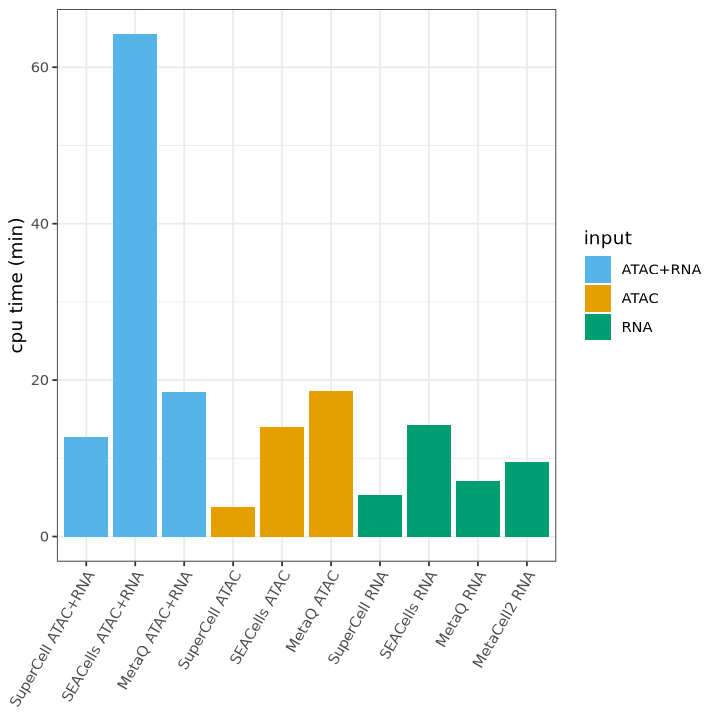

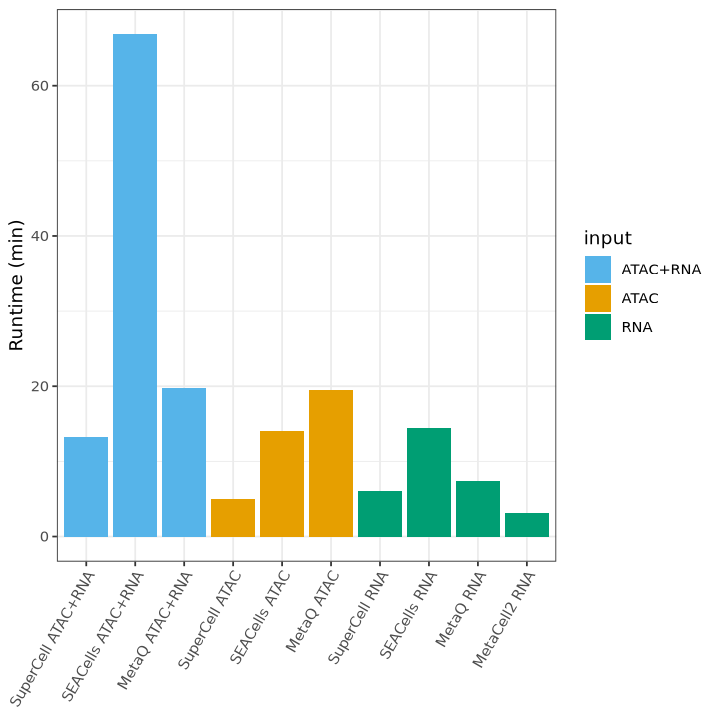

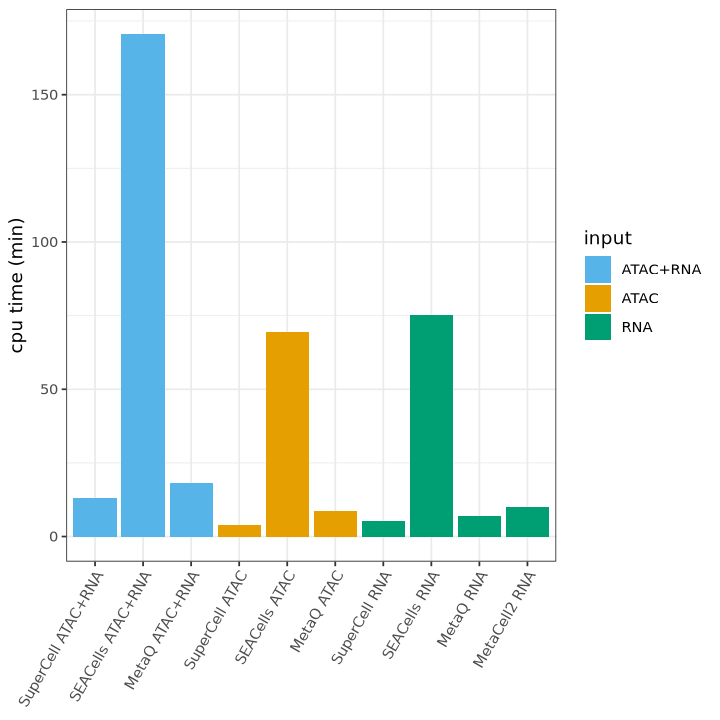

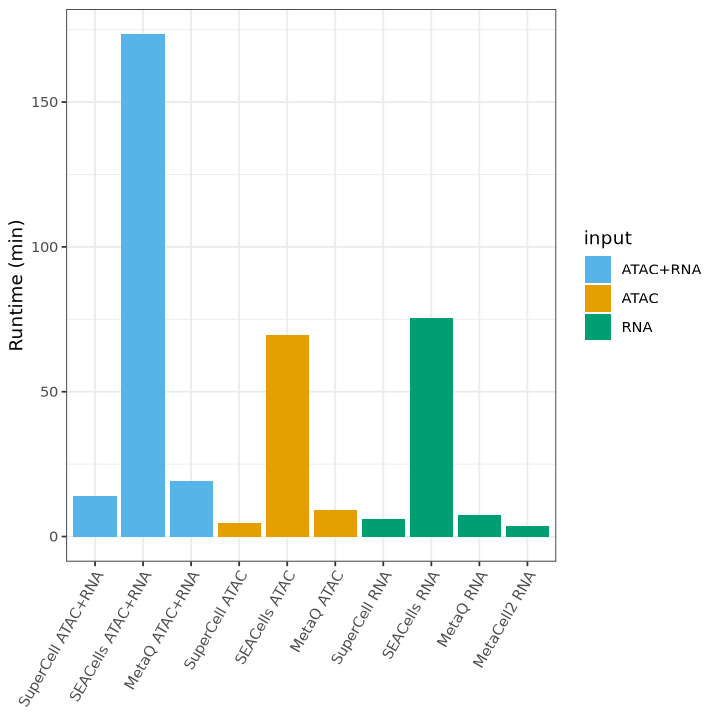

In [60]:
multiome.cpu.time.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],aes(x = method,y = cpu_time/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("cpu time (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())


multiome.run.time.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],aes(x = method,y = s/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())


multiome.cpu.time.plot.g20 <- ggplot(benchTable2[ benchTable2$gamma == 20,],aes(x = method,y = cpu_time/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))   +
  ylab("cpu time (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())

multiome.run.time.plot.g20 <- ggplot(benchTable2[benchTable2$gamma == 20,],aes(x = method,y = s/60,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())



multiome.cpu.time.plot.g75
multiome.run.time.plot.g75

multiome.cpu.time.plot.g20
multiome.run.time.plot.g20

Memory with preprocessing

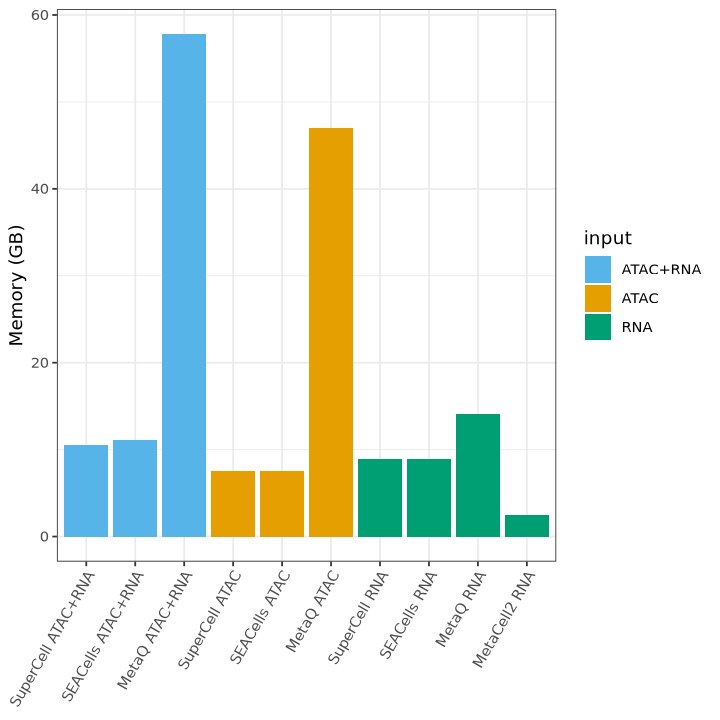

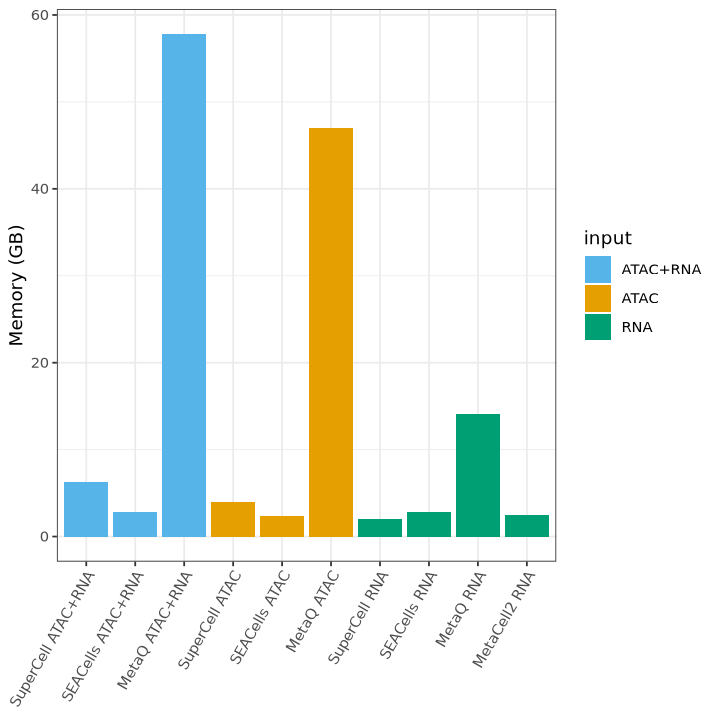

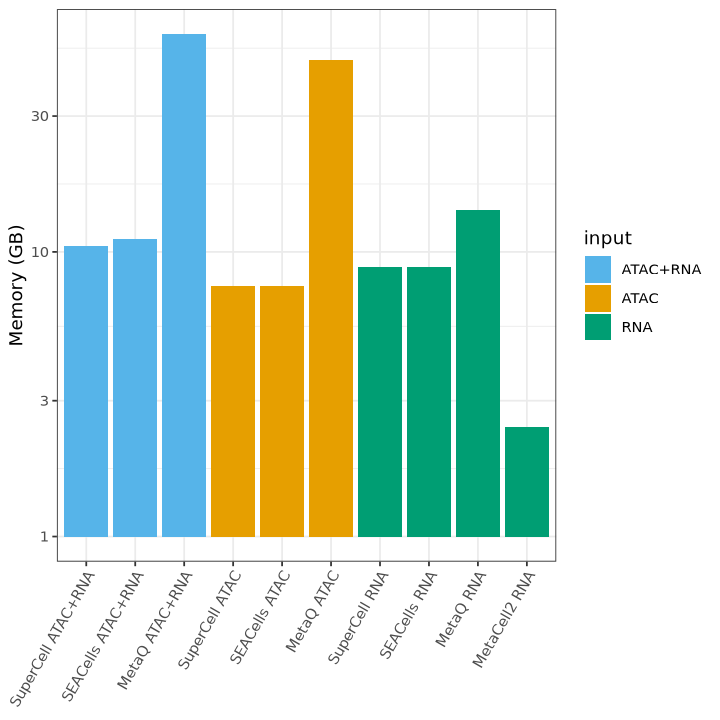

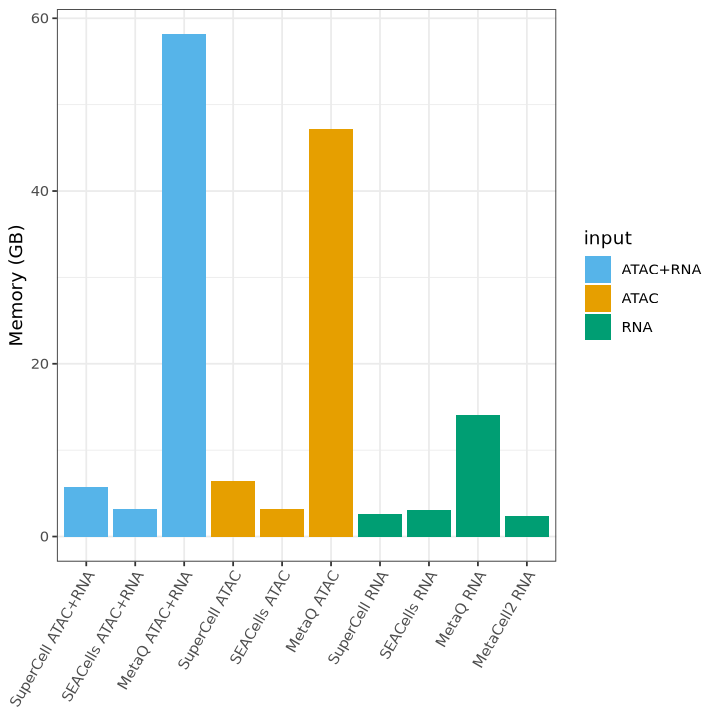

In [61]:
multiome.memory.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],aes(x = method,y = max_rss/1024,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())


multiome.memory.plot.g75.id <- ggplot(benchTable[benchTable$gamma == 75,],aes(x = method,y = max_rss/1024,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())


multiome.memory.plot.g20 <- ggplot(benchTable2[ benchTable2$gamma == 20,],aes(x = method,y = max_rss/1024,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_y_log10()   +
  ylab("Memory (GB)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())

multiome.memory.plot.g20.id <- ggplot(benchTable[benchTable$gamma == 20,],aes(x = method,y = max_rss/1024,fill = input)) +
  geom_bar(stat = "identity", position="dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") +
  scale_fill_manual(values = input.colors.10Xmultiome)  + theme_bw() + theme(axis.title.x = element_blank())



multiome.memory.plot.g75
multiome.memory.plot.g75.id

multiome.memory.plot.g20
multiome.memory.plot.g20.id

Combined scalability plot g20

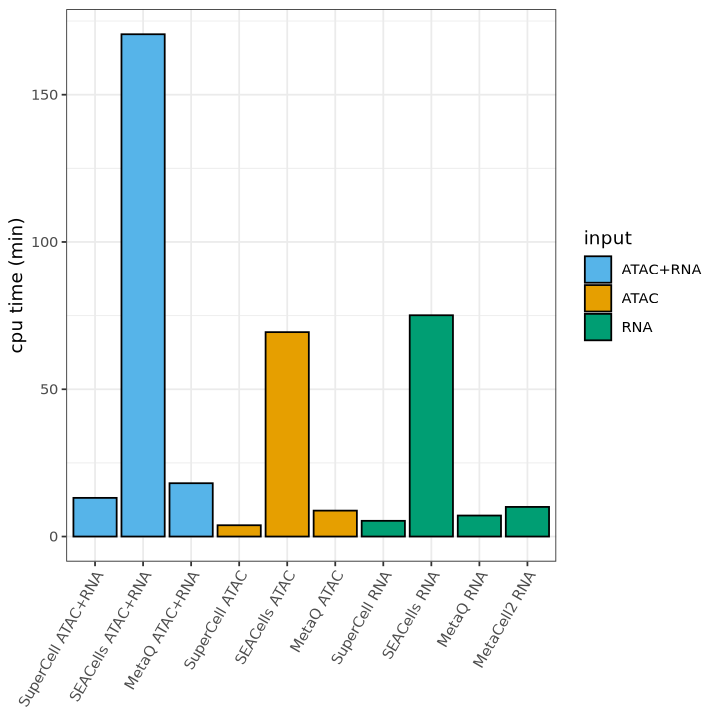

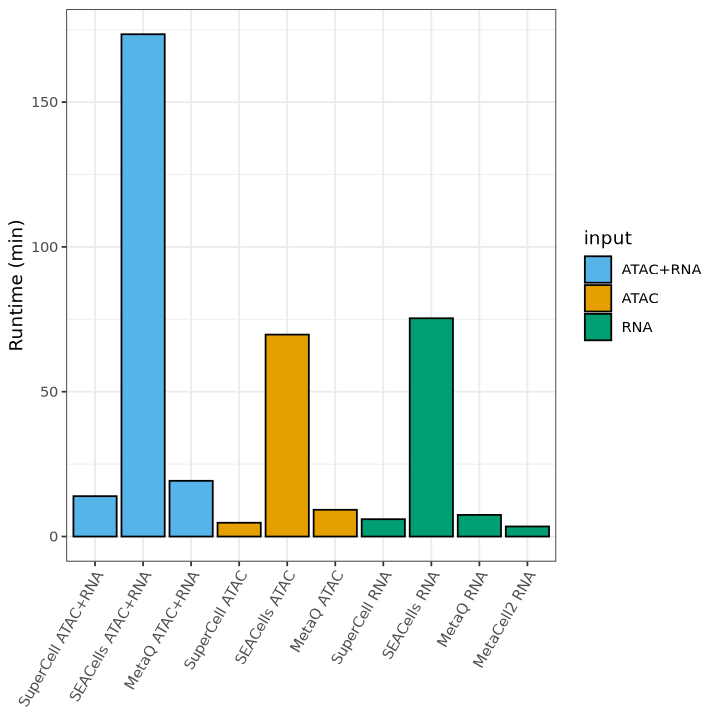

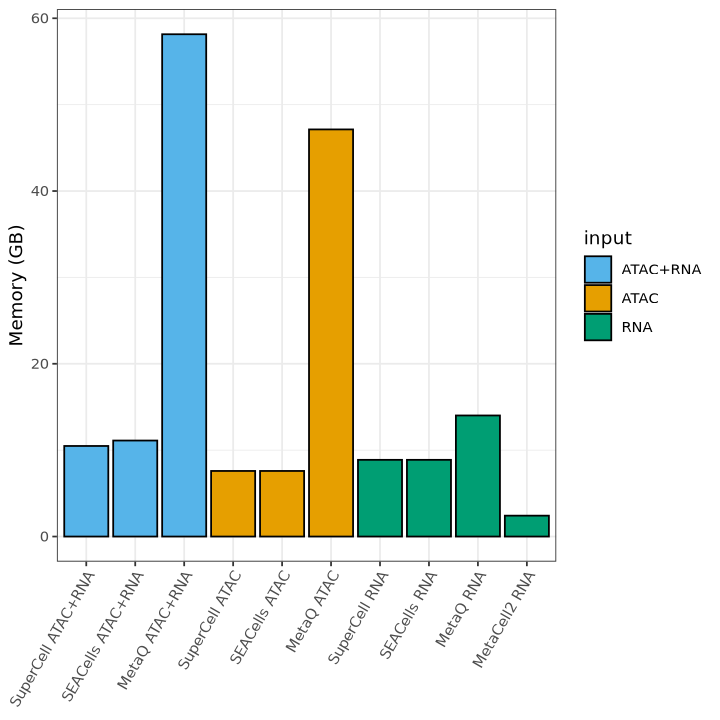

In [62]:
benchTable2$workflow <- "with preprocessing"
benchTable$workflow <- "identification only"



benchTable2$workflow <- factor(benchTable2$workflow,levels = c("with preprocessing","identification only"))

multiome.memory.plot.g20 <- ggplot(benchTable2[benchTable2$gamma == 20,],
                                   aes(x = method,y = max_rss/1024,fill = input)) +
  geom_bar(stat = "identity",col = "black",position = "dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") +
  scale_fill_manual(values = input.colors.10Xmultiome) + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())

multiome.cpu.time.plot.g20 <- ggplot(benchTable2[ benchTable2$gamma == 20,],
                                     aes(x = method,y = cpu_time/60,fill = input)) +
  geom_bar(stat = "identity",col = "black",position = "dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  ylab("cpu time (min)") +

  scale_fill_manual(values = input.colors.10Xmultiome)  + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())

multiome.run.time.plot.g20 <- ggplot(benchTable2[benchTable2$gamma == 20,],
                                     aes(x = method,y = s/60,fill = input)) +
  geom_bar(stat = "identity",col = "black",position = "dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") +

  scale_fill_manual(values = input.colors.10Xmultiome) + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())

multiome.cpu.time.plot.g20
multiome.run.time.plot.g20

multiome.memory.plot.g20


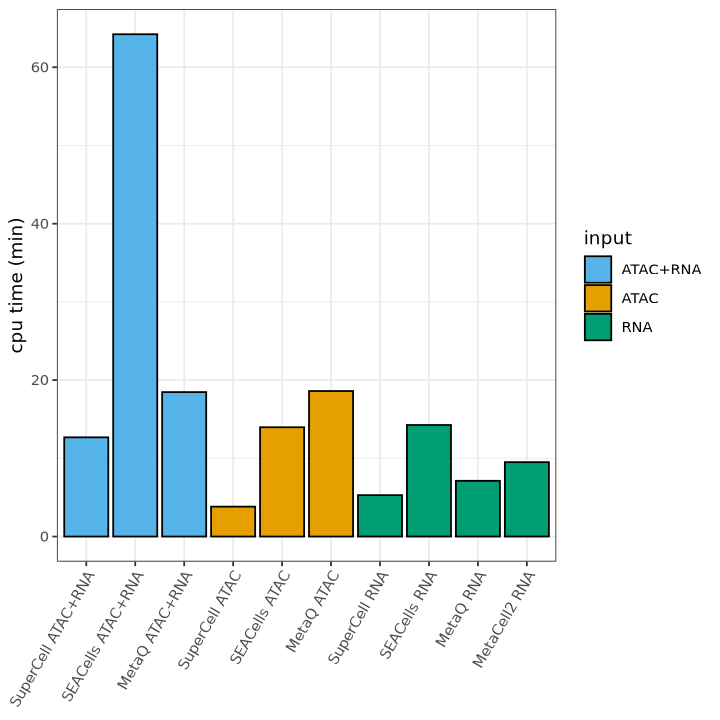

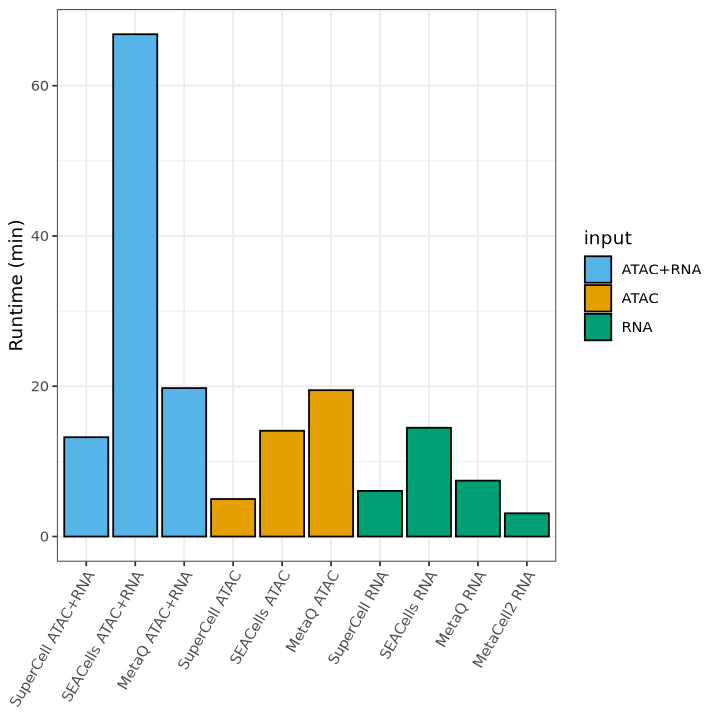

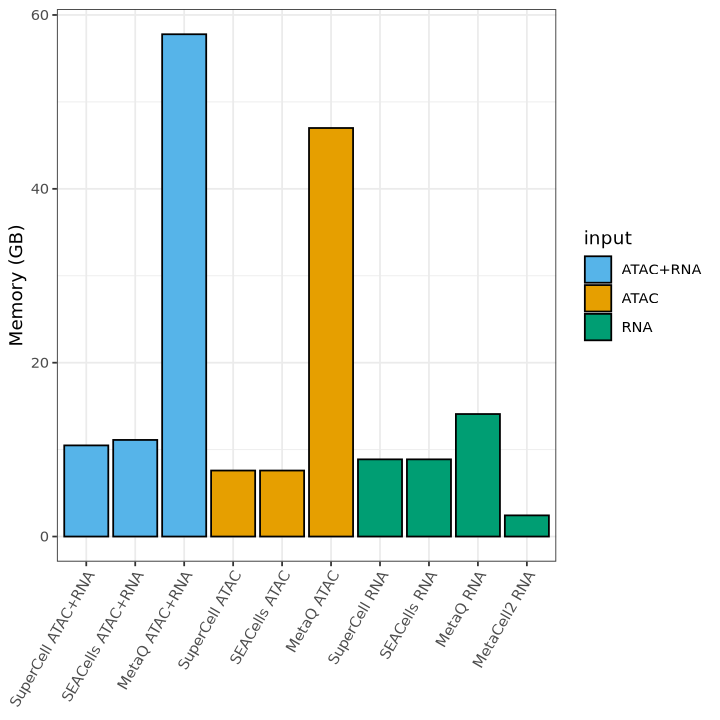

In [63]:
benchTable2$workflow <- "with preprocessing"
benchTable$workflow <- "identification only"


benchTable2$workflow <- factor(benchTable2$workflow,levels = c("with preprocessing","identification only"))

multiome.memory.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],
                                   aes(x = method,y = max_rss/1024,fill = input)) +
  geom_bar(stat = "identity",col = "black",position = "dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Memory (GB)") +
  scale_fill_manual(values = input.colors.10Xmultiome) + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())

multiome.cpu.time.plot.g75 <- ggplot(benchTable2[ benchTable2$gamma == 75,],
                                     aes(x = method,y = cpu_time/60,fill = input)) +
  geom_bar(stat = "identity",col = "black",position = "dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))   +
  ylab("cpu time (min)") +

  scale_fill_manual(values = input.colors.10Xmultiome)  + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())

multiome.run.time.plot.g75 <- ggplot(benchTable2[benchTable2$gamma == 75,],
                                     aes(x = method,y = s/60,fill = input)) +
  geom_bar(stat = "identity",col = "black",position = "dodge") +
  scale_x_discrete(guide = guide_axis(angle = 60))  +
  ylab("Runtime (min)") +
  scale_fill_manual(values = input.colors.10Xmultiome) + theme(axis.title.x = element_blank())  + theme_bw() + theme(axis.title.x = element_blank())

multiome.cpu.time.plot.g75
multiome.run.time.plot.g75

multiome.memory.plot.g75


Making Fig1 BCD

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


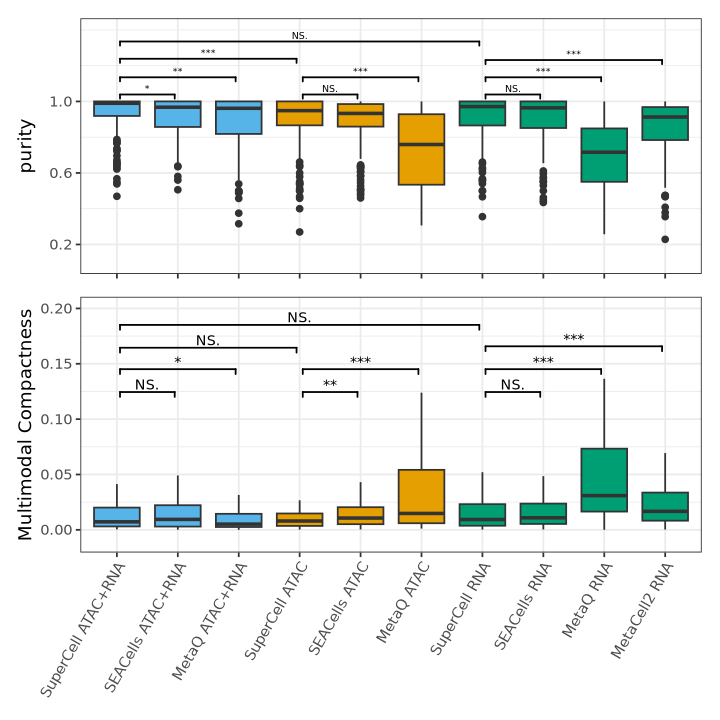

In [64]:
library(patchwork)
sig.seurat_annotations.g75 <- purity.pbmc.multiome.g75  + theme(axis.text.x = element_blank()) +  NoLegend()

sig.multimodal.compactness.g75 <-  multimodal_compactness.75 + NoLegend() +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60))

comp.pur.g75 <- sig.seurat_annotations.g75 / sig.multimodal.compactness.g75 + plot_layout(heights = c(1, 1))

comp.pur.g75

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


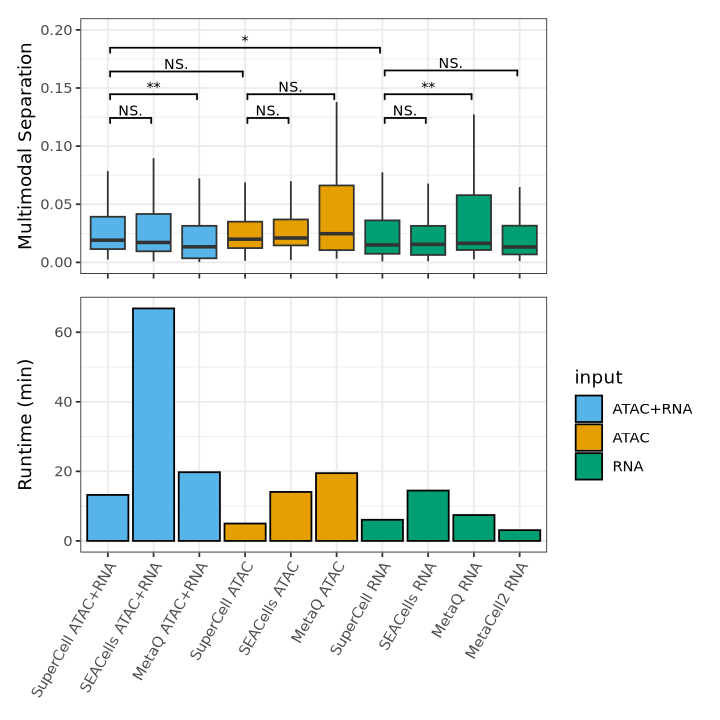

In [66]:
leg.input <- cowplot::get_legend(multiome.run.time.plot.g75 + theme(legend.position = "right"))
sep.g75 <- multimodal_separation.75+ NoLegend() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank())

multiome.run.time.plot.g75 <-  multiome.run.time.plot.g75  +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60))

sep.runtime.g75 <- sep.g75 / multiome.run.time.plot.g75 + plot_layout(heights = c(1, 1))
sep.runtime.g75


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


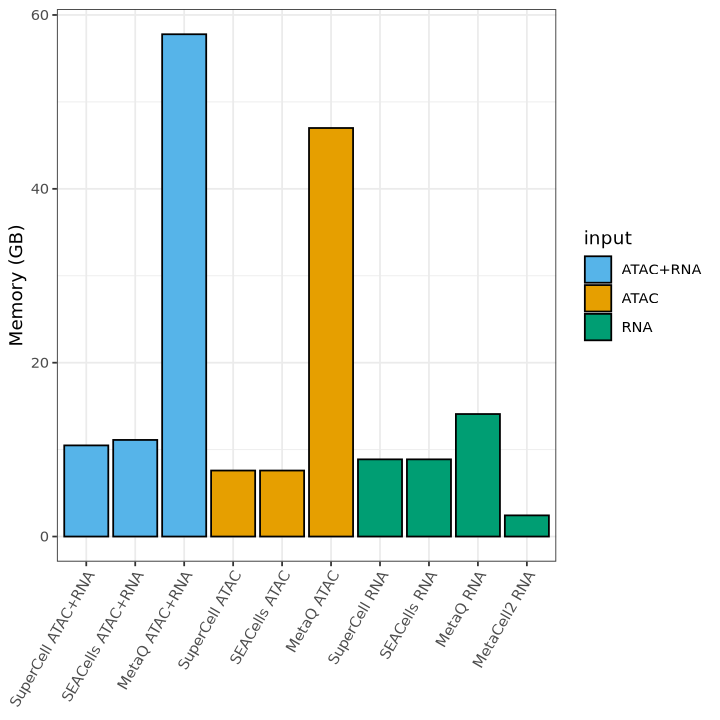

In [67]:


multiome.memory.plot.g75 <-  multiome.memory.plot.g75  +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60))   + theme_bw() + theme(axis.title.x = element_blank()) +
  theme(legend.spacing.y = unit(-0.25, "line"))

multiome.memory.plot.g75

Sparsity reduction

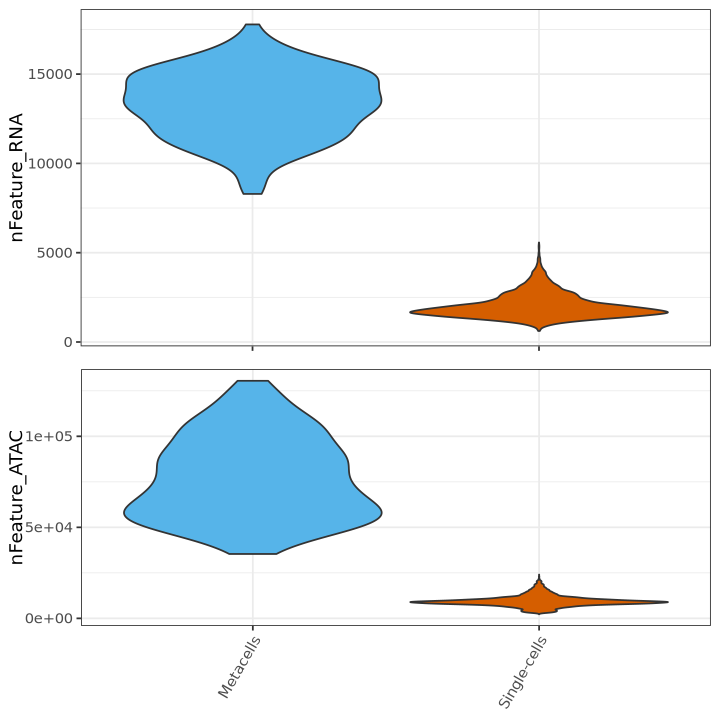

In [68]:
pbmc$resolution <- "Single-cells"
pbmc.supercell.multi$resolution <- "Metacells"
meta.sc.mc <- rbind(pbmc@meta.data[,c("nCount_RNA","nFeature_RNA","nCount_ATAC","nFeature_ATAC","resolution")],
                    pbmc.supercell.multi@meta.data[,c("nCount_RNA","nFeature_RNA","nCount_ATAC","nFeature_ATAC","resolution")])

meta.sc.mc$resolution <- factor(meta.sc.mc$resolution,levels = c("Metacells","Single-cells"))

nFeature_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nFeature_RNA,fill = resolution)) + geom_violin(scale = "width")  + theme_bw() + theme(axis.title.x = element_blank(),axis.text.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  scale_fill_manual(values = c("#56B4E9","#D55E00")) #colorblind_pal()(8)[c(3,7)]


nFeature_ATAC <- ggplot(meta.sc.mc,aes(x=resolution,y=nFeature_ATAC,fill = resolution)) + geom_violin(scale = "width") + theme_bw() + theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_fill_manual(values = c("#56B4E9","#D55E00")) #colorblind_pal()(8)[c(3,7)]

sparsity.reduction.g75 <- cowplot::plot_grid(nFeature_RNA+ NoLegend(),nFeature_ATAC+ NoLegend(),ncol = 1)
sparsity.reduction.g75


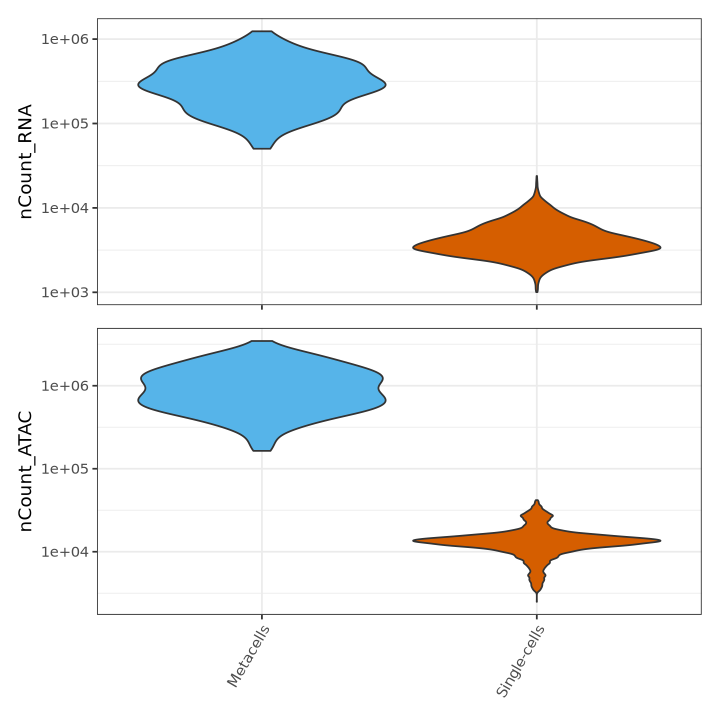

In [69]:

nCount_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nCount_RNA,fill = resolution)) + geom_violin(scale = "width")  + theme_bw() + theme(axis.title.x = element_blank(),
                                                                                                                                       axis.text.x = element_blank())  +
  scale_y_log10() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_fill_manual(values = c("#56B4E9","#D55E00"))  
nCount_ATAC <- ggplot(meta.sc.mc,aes(x=resolution,y=nCount_ATAC,fill = resolution)) + geom_violin(scale = "width")+ theme_bw()  + theme(axis.title.x = element_blank()) + scale_y_log10() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_fill_manual(values = c("#56B4E9","#D55E00"))

sparsity.reduction.counts.g20 <- wrap_plots(nCount_RNA+ NoLegend(),nCount_ATAC+ NoLegend(),ncol = 1)

sparsity.reduction.counts.g20

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


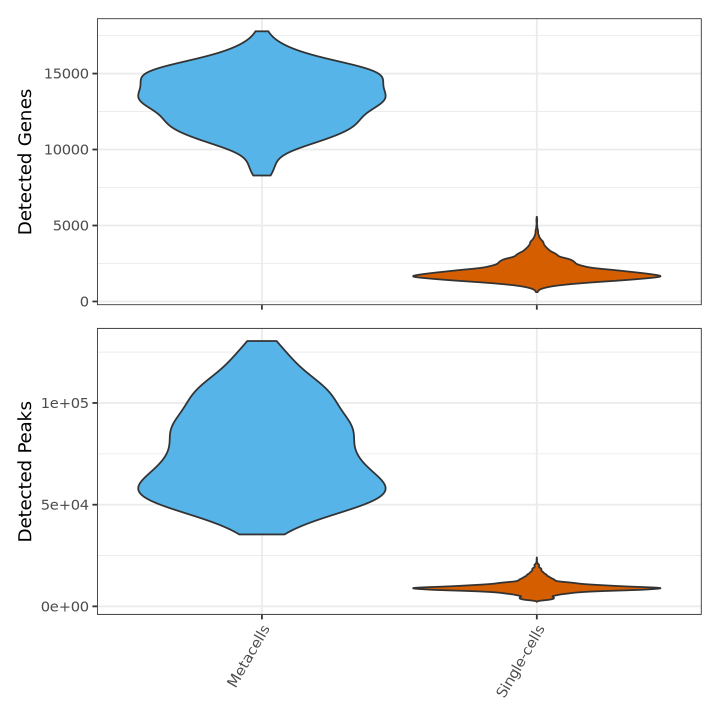

In [70]:
nFeature_RNA <- nFeature_RNA  + NoLegend() + theme_bw() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank()) + ylab("Detected Genes")   + NoLegend()

nFeature_ATAC <-  nFeature_ATAC  + theme_bw() +
  theme(axis.title.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60))+ ylab("Detected Peaks")  + NoLegend()

sparsity.reduction.g20 <- nFeature_RNA / nFeature_ATAC + plot_layout(heights = c(1, 1))

sparsity.reduction.g20

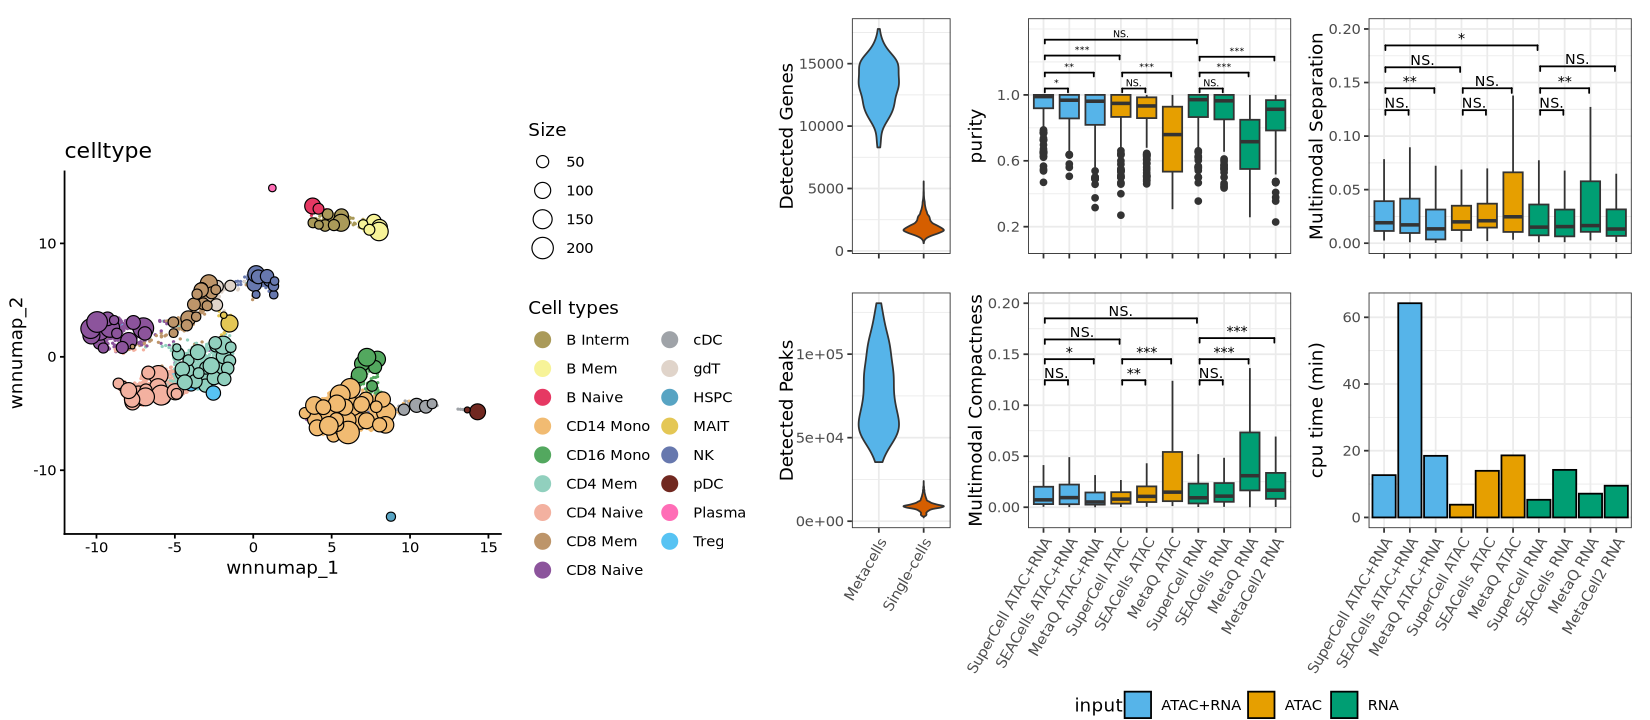

In [89]:
options(repr.plot.width=13.75, repr.plot.height=6)
Fig2ABC <- cowplot::plot_grid(fig1B+theme(plot.margin = unit(c(80,0,80,0),units = "pt")),
                              wrap_plots(nFeature_RNA, sig.seurat_annotations.g75, sep.g75,
                                         nFeature_ATAC,sig.multimodal.compactness.g75,
                                         multiome.cpu.time.plot.g75 + 
                                           theme(legend.position = c(-0.5,-0.75),legend.direction = "horizontal",axis.title.x = element_blank()),
                                         nrow = 2,ncol = 3,widths = c(0.75,2,2))&theme(plot.margin = margin(5.5, 5.5, 15, 5.5)),
                              nrow = 1,
                              rel_widths = c(3,3.5))



Fig2ABC

In [90]:
dir.create("../../../pdf_files/Fig2/", recursive = T, showWarnings = F)
pdf(file = "../../../pdf_files/Fig2/Fig2ABC.pdf",height = 6,width=13.75)
Fig2ABC
dev.off()

agg_record_1402196347 
                    2

# FigS1A

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning m

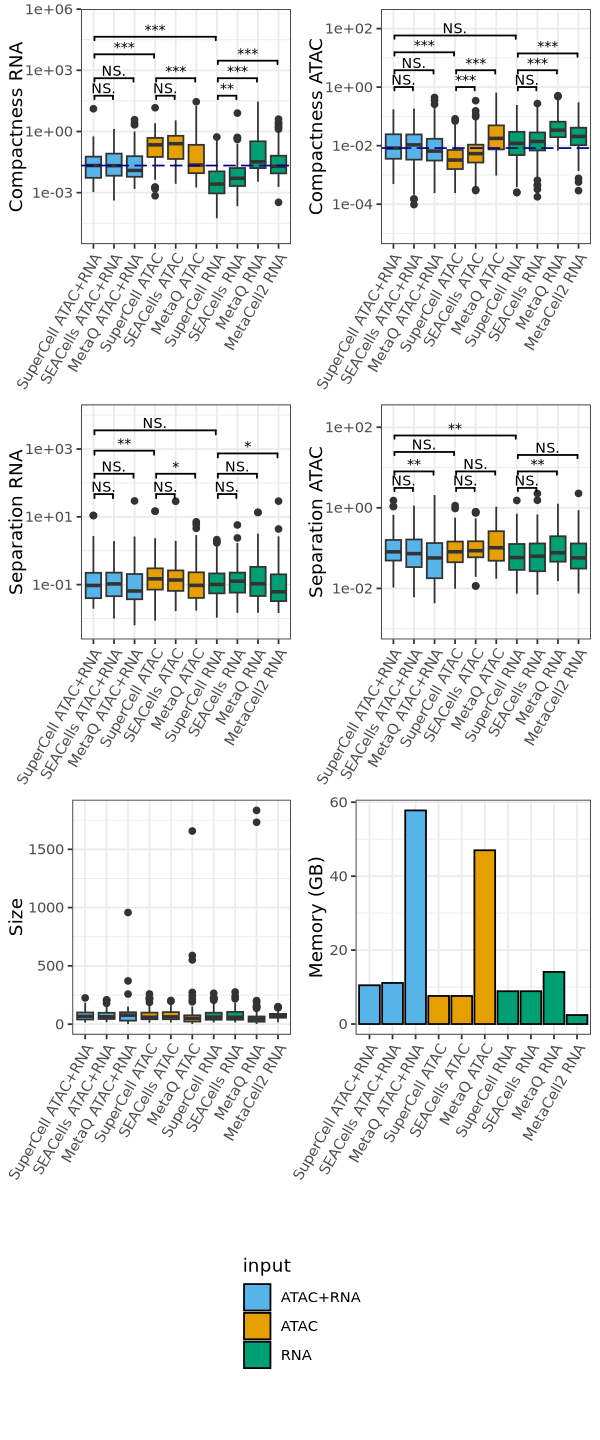

In [91]:
options(repr.plot.width=5, repr.plot.height=12)

figS1B <- cowplot::plot_grid(cowplot::plot_grid(compactness_pca.bmc.cite.g75+
                                                  NoLegend() +
                                                  theme(axis.title.x = element_blank()) +
                                                  scale_x_discrete(guide = guide_axis(angle = 60)),

                                                compactness_lsi.bmc.cite.g75 + NoLegend() + theme(axis.title.x = element_blank()) +
                                                  scale_x_discrete(guide = guide_axis(angle = 60)),
                                                separation_pca.g75 + NoLegend() + theme(axis.title.x = element_blank()) +
                                                  scale_x_discrete(guide = guide_axis(angle = 60)),
                                                separation_lsi.g75 + NoLegend() + theme(axis.title.x = element_blank()) +
                                                  scale_x_discrete(guide = guide_axis(angle = 60)),
                                                size.g75  + NoLegend() + theme(axis.title.x = element_blank()) +scale_x_discrete(guide = guide_axis(angle = 60)),
                                                multiome.memory.plot.g75 + NoLegend() +scale_x_discrete(guide = guide_axis(angle = 60)),
                                                ncol = 2),cowplot::get_legend(multiome.memory.plot.g20),ncol = 1,rel_heights = c(14,3))

figS1B

In [79]:
pdf(file = "../../../pdf_files/FigS1/figS1BCD.pdf",height = 12,width=5)
figS1B
dev.off()

agg_record_256298908 
                   2

Converting layer data in assay ATAC to empty dgCMatrix

Warning message:
“No features found in assay ‘GA_ArchR’, removing...”
Warning message:
“No features found in assay ‘GA_Signac’, removing...”
Warning message:
“No features found in assay ‘chromvar’, removing...”
Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

16:21:17 UMAP embedding parameters a = 0.9922 b = 1.112

16:21:18 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

16:21:21 Initializing from normalized Laplacian + noise (using RSpectra)

16:21:22 Commencing optimization for 200 epochs, with 334378 positive edges

16:21:22 Using rng type: pcg

16:21:32 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default

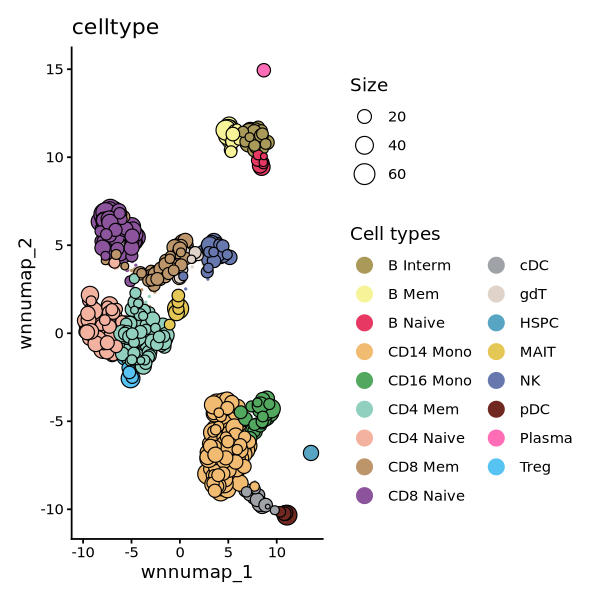

In [92]:

pbmc.supercell.multi.g20 <- readRDS(paste0(datadir,"/output/pbmcMultiome//SuperCellMulti//g20/seurat.multiome.activities.rds"))

figSupCov <- SingleCellsMetacellsWnnUMAP(
  sobj.sc = pbmc,
  sobj.mc = pbmc.supercell.multi.g20,
  dimred_1 = "pca",
  dimred_2= "lsi",
  dims.list = list(1:40, 2:40),
  cols = color.celltypes.pbmc,
  group.by = "celltype",
  dims.umap = c(1,2)
) + theme_classic()  +
  guides(colour=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
         size = guide_legend(title = "Size"))



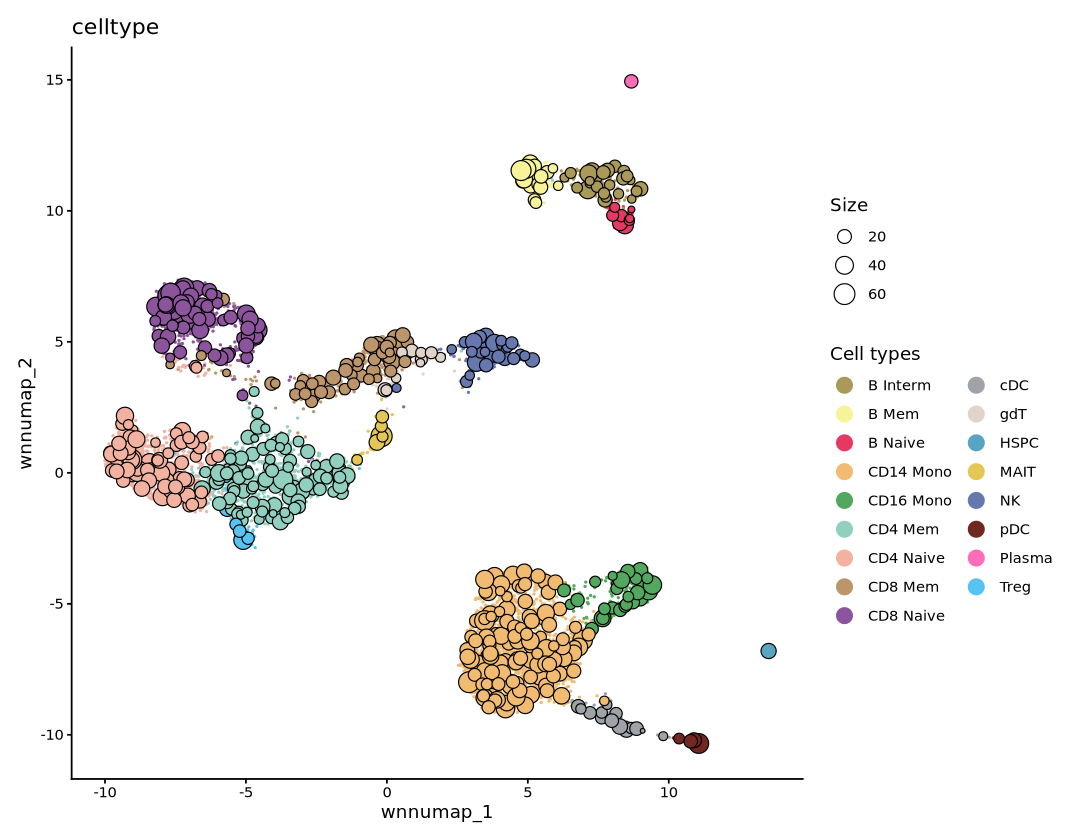

In [94]:
options(repr.plot.width=9, repr.plot.height=7)


figSupCov

Sparsity reduction g20

In [95]:
pbmc$resolution <- "Single-cells"
pbmc.supercell.multi.g20$resolution <- "Metacells"
meta.sc.mc <- rbind(pbmc@meta.data[,c("nCount_RNA","nFeature_RNA","nCount_ATAC","nFeature_ATAC","resolution")],
                    pbmc.supercell.multi.g20@meta.data[,c("nCount_RNA","nFeature_RNA","nCount_ATAC","nFeature_ATAC","resolution")])

meta.sc.mc$resolution <- factor(meta.sc.mc$resolution,levels = c("Metacells","Single-cells"))

nFeature_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nFeature_RNA,fill = resolution)) + geom_violin(scale = "width") + theme_bw() + theme(axis.title.x = element_blank(),
                                                                                                                                          axis.text.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) +
  scale_fill_manual(values = c("#56B4E9","#D55E00")) +  NoLegend()


nFeature_ATAC <- ggplot(meta.sc.mc,aes(x=resolution,y=nFeature_ATAC,fill = resolution)) + geom_violin(scale = "width") + theme_bw() + theme(axis.title.x = element_blank(),
                                                                                                                                            axis.text.x = element_blank())  +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_fill_manual(values = c("#56B4E9","#D55E00")) + NoLegend()

sparsity.reduction.g20 <- cowplot::plot_grid(nFeature_RNA+ NoLegend(),nFeature_ATAC+ NoLegend(),ncol = 1)



In [96]:

nCount_RNA <- ggplot(meta.sc.mc,aes(x=resolution,y=nCount_RNA,fill = resolution)) + geom_violin(scale = "width")  + theme_bw() + theme(axis.title.x = element_blank(),
                                                                                                                                       axis.text.x = element_blank())  + scale_y_log10() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_fill_manual(values = c("#56B4E9","#D55E00")) + NoLegend()
nCount_ATAC <- ggplot(meta.sc.mc,aes(x=resolution,y=nCount_ATAC,fill = resolution)) + geom_violin(scale = "width")  + theme_bw() + theme(axis.title.x = element_blank()) + scale_y_log10() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + scale_fill_manual(values = c("#56B4E9","#D55E00")) + NoLegend()

sparsity.reduction.counts.g20 <- wrap_plots(nCount_RNA+ NoLegend(),nCount_ATAC+ NoLegend(),ncol = 1)



In [97]:
nFeature_RNA <- nFeature_RNA  + NoLegend()  + theme_bw() +
  theme(axis.text.x = element_blank(),axis.title.x = element_blank()) + ylab("Detected Genes") + NoLegend()

nFeature_ATAC <-  nFeature_ATAC  + theme_bw() +
  theme(axis.title.x = element_blank())  + NoLegend() +
  scale_x_discrete(guide = guide_axis(angle = 60)) + ylab("Detected Peaks")


sparsity.reduction.g20 <- nFeature_RNA / nFeature_ATAC + plot_layout(heights = c(1, 1))  + NoLegend()


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


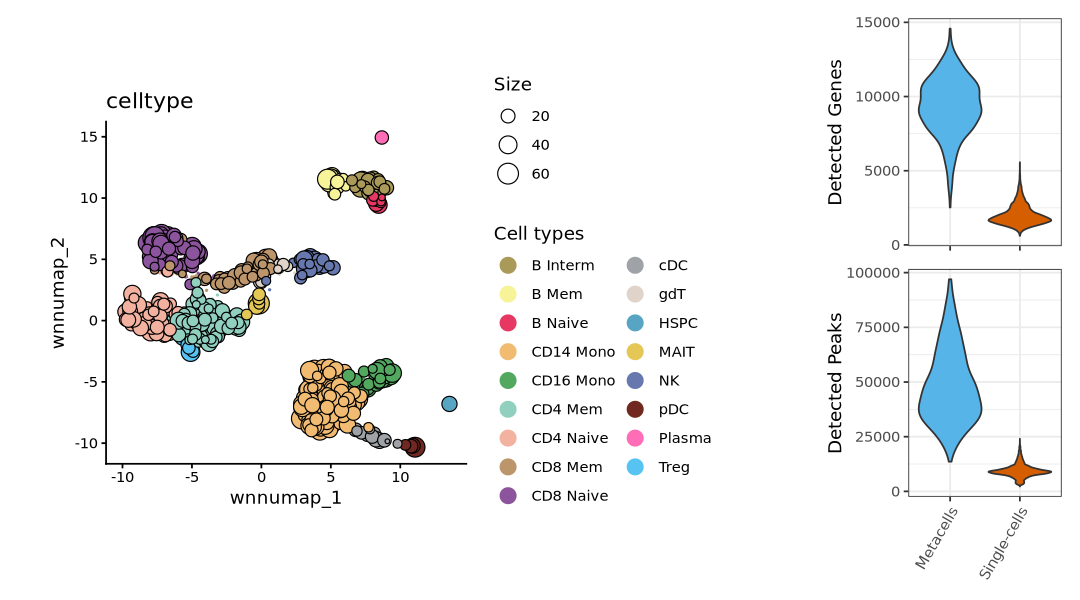

In [100]:
options(repr.plot.width=9, repr.plot.height=5)

figS1EF <- cowplot::plot_grid(figSupCov+theme(plot.margin = unit(c(50,50,50,25),units = "pt")),
                             wrap_plots(nFeature_RNA, nFeature_ATAC,ncol = 1),rel_widths = c(3,1))

figS1EF

In [101]:
pdf(file = "../../../pdf_files/FigS1/figS1EF.pdf",height = 5,width=9)
figS1EF
dev.off()

agg_record_926779059 
                   2

In [105]:
pbmc.metacell.rna

An object of class Seurat 
193055 features across 140 samples within 2 assays 
Active assay: ATAC (156454 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: RNA

In [109]:
pbmc.metacell.rna.g20

An object of class Seurat 
217251 features across 529 samples within 3 assays 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts
 2 other assays present: SCT, ATAC

Metcalls2 outliers

outliers,length.which.is.na.pbmc.metacell.rna.misc.membership...,graining_level,perc.outliers
<int>,<int>,<chr>,<chr>
214,9,20,2%
214,9,75,2%


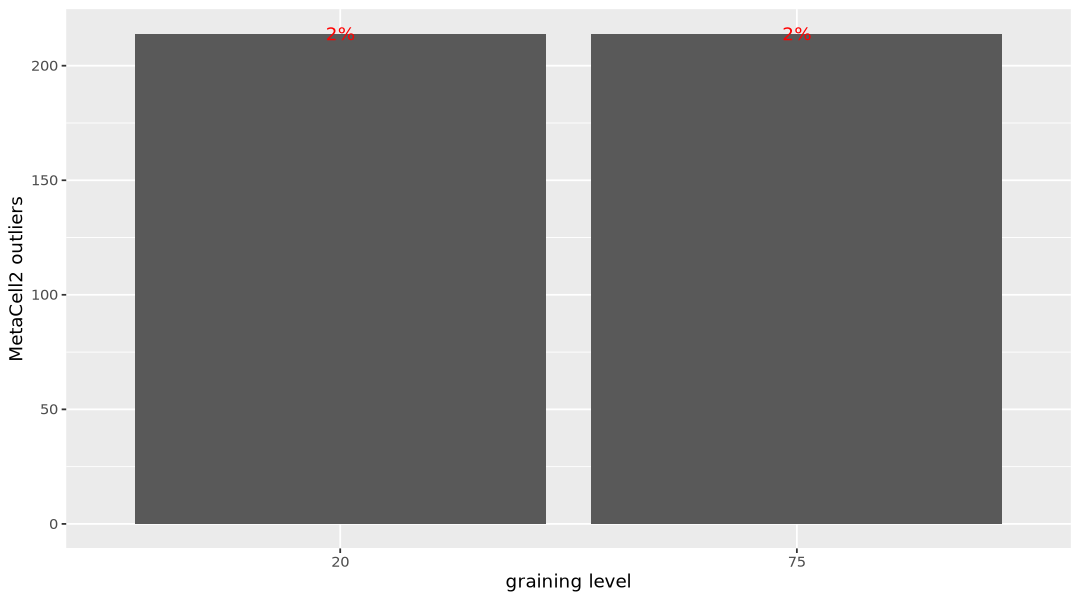

In [108]:
pbmc.metacell.rna.g20 <- readRDS(paste0(datadir,"/output/pbmcMultiome/MetaCellRNA//g20/seurat.multiome.mc.rds"))
outliers.mc2 <- data.frame("outliers" = c(
                                          length(which(is.na(pbmc.metacell.rna.g20@misc$membership)))),
                                          length(which(is.na(pbmc.metacell.rna@misc$membership))),
                           "graining_level" = c("20","75"))

outliers.mc2$perc.outliers <-label_percent()(outliers.mc2$outliers/ncol(pbmc))
outliers.mc2

outliers.mc2 <- ggplot(outliers.mc2,aes( x= graining_level, y = outliers)) + geom_bar(stat = "identity", position="dodge") + ylab("MetaCell2 outliers") + xlab("graining level") + geom_text(aes(label = perc.outliers),col = "red")
outliers.mc2

In [ ]:
# pdf(file = "figS1E.pdf",height = 2.5,width=2)
# outliers.mc2
# dev.off()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning me

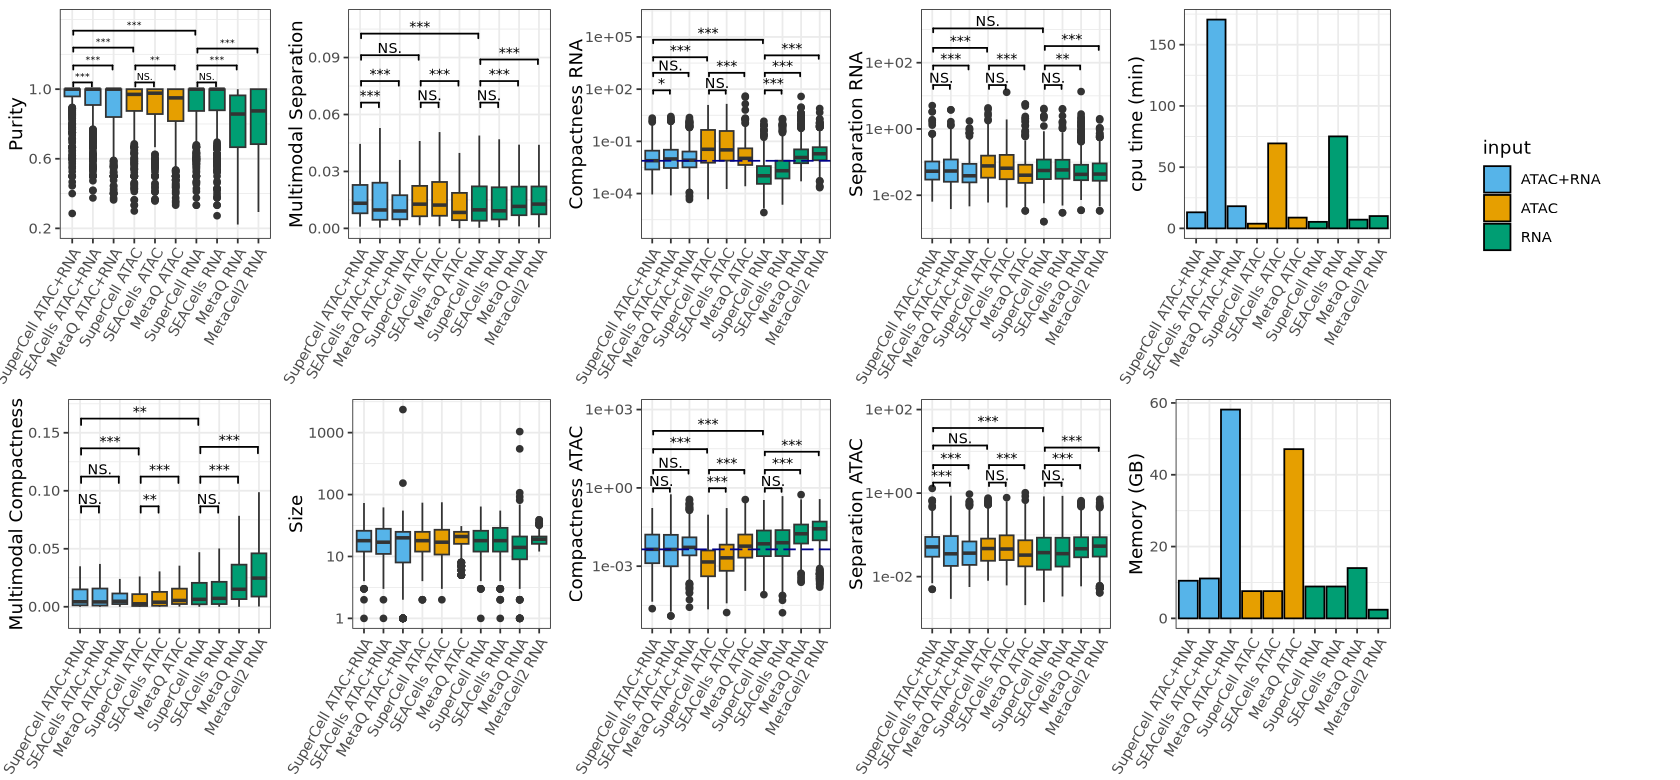

In [111]:
options(repr.plot.width=14, repr.plot.height=6.5)

figS1G <- cowplot::plot_grid(sig.seurat_annotations.g20+ NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             sig.multimodal.compactness.g20+ NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             sig.multimodal.separation.g20+ NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             size.g20 + NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             compactness_pca.bmc.cite.g20+ NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             compactness_lsi.bmc.cite.g20 + NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             separation_pca.g20 + NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             separation_lsi.g20 + NoLegend() + theme(axis.title.x = element_blank())+
                               scale_x_discrete(guide = guide_axis(angle = 60)),
                             multiome.cpu.time.plot.g20+ theme(axis.title.x = element_blank()) + NoLegend()+ scale_x_discrete(guide = guide_axis(angle = 60)),
                             multiome.memory.plot.g20+ theme(axis.title.x = element_blank())+ NoLegend()+ scale_x_discrete(guide = guide_axis(angle = 60))
                             ,leg.input,
                             byrow = F,nrow = 2)

figS1G

In [112]:
pdf(file = "../../../pdf_files/FigS1/figS1G.pdf",height = 6.5,width=14)
figS1G
dev.off()

agg_record_1923614713 
                    2

## Test k nn

In [113]:
unique(bench.20.no.random$tool)

[1] "SuperCell"            "SEACells"             "MetaQ"               
[4] "MetaCell2"            "SuperCell_testKNN"    "supSuperCell_testKNN"

In [127]:


test_knn <- rbind(bench.20.no.random[bench.20.no.random$tool %in% c("supSuperCell_testKNN","SuperCell_testKNN"),c(cn,"multimodal_compactness","multimodal_separation")],
                  bench.75.no.random[bench.75.no.random$tool %in% c("supSuperCell_testKNN","SuperCell_testKNN"),c(cn,"multimodal_compactness","multimodal_separation")]
                 )

In [128]:
table(test_knn$tool,test_knn$k_nn)

                      
                        10  20  30  40  60  80 100
  SuperCell_testKNN    658 658 658 658 658 658 658
  supSuperCell_testKNN 658 658 658 658 658 658 658

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


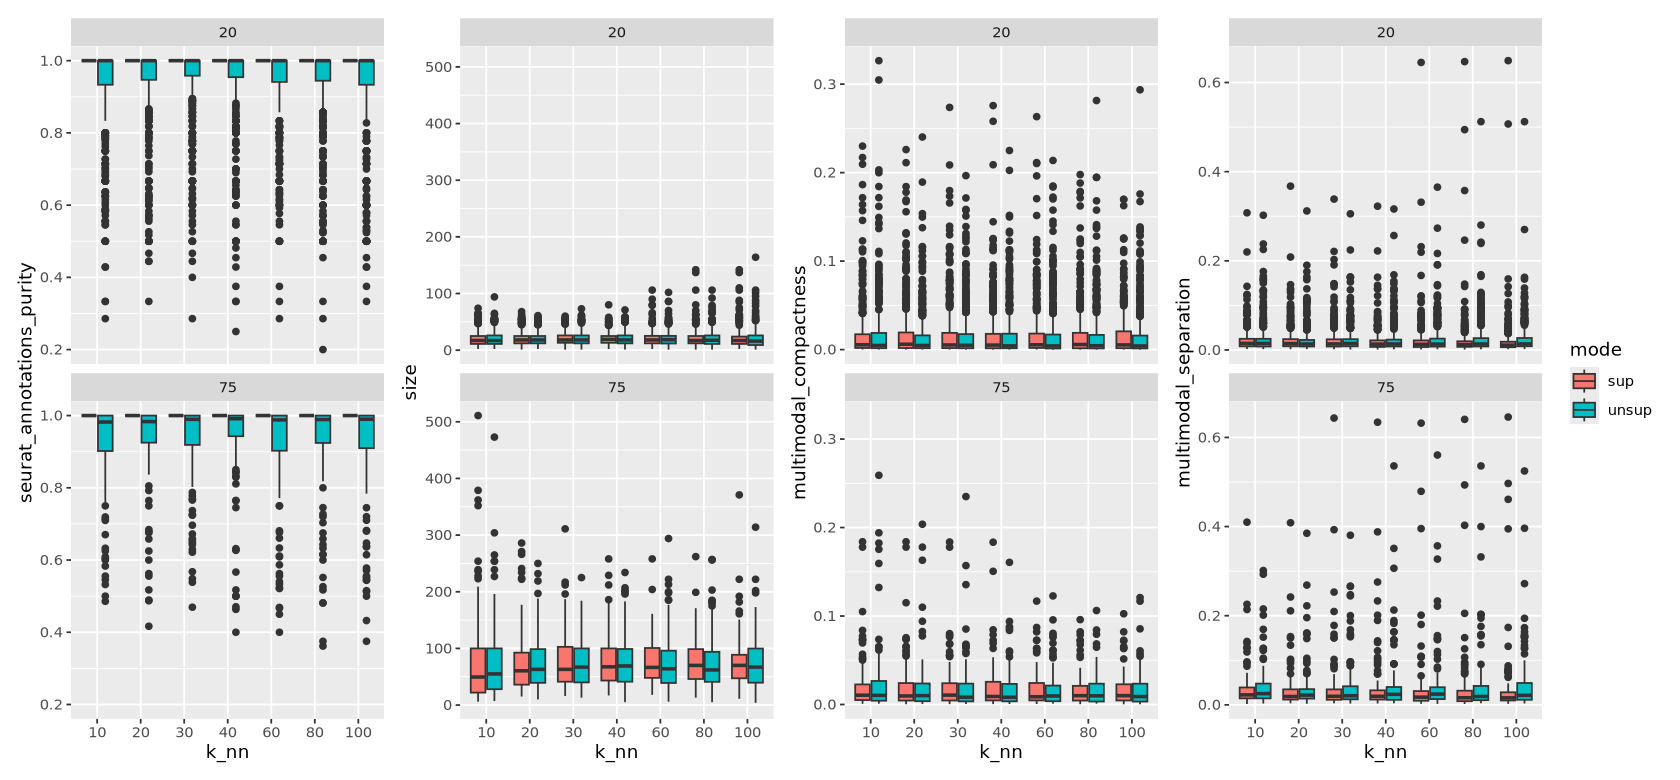

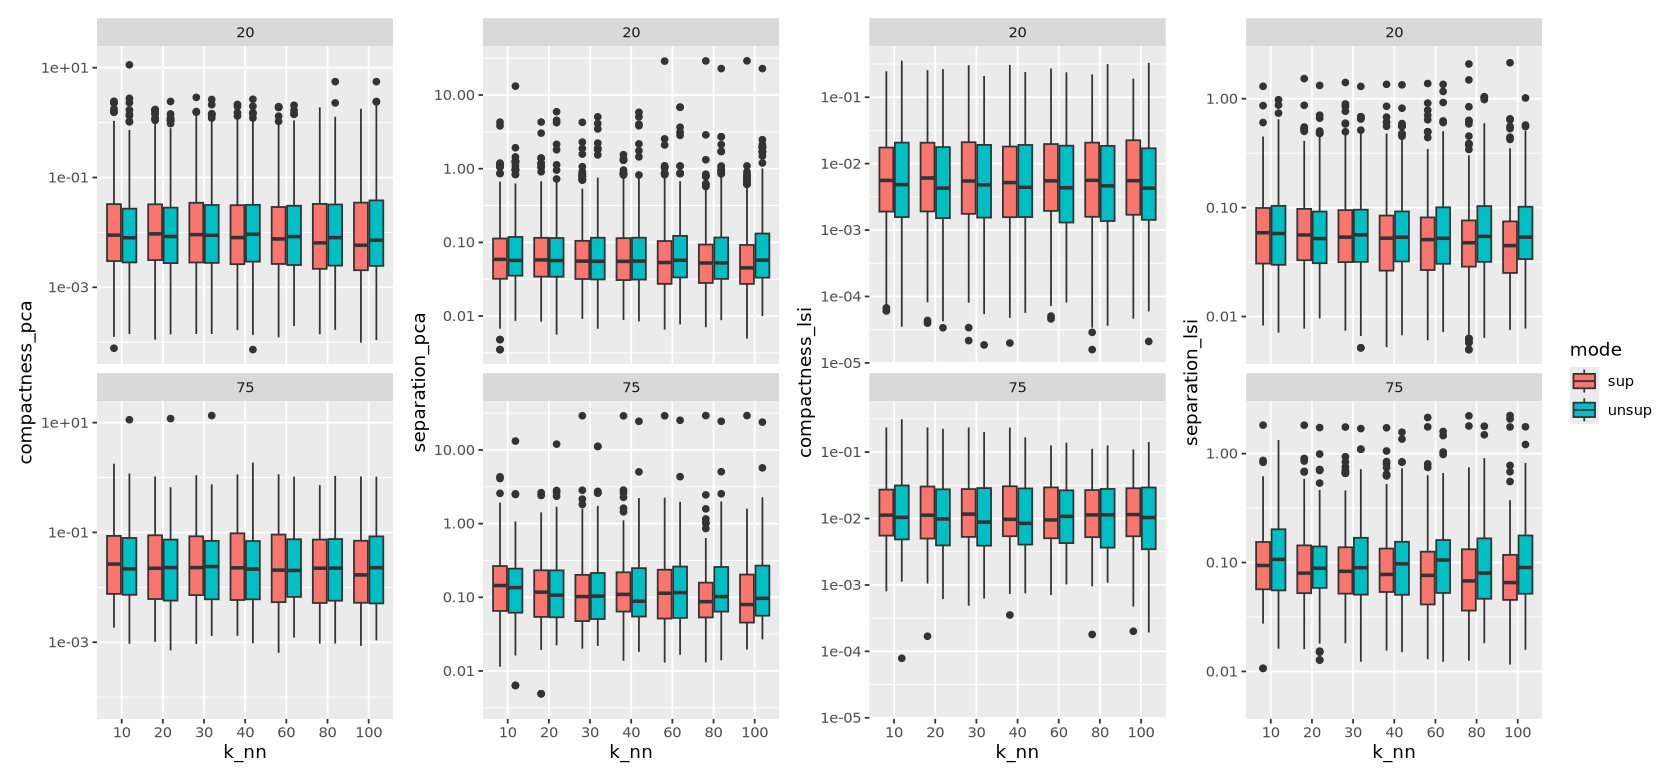

In [133]:

test_knn$k_nn <- as.factor(test_knn$k_nn)
test_knn$mode <- "unsup"
test_knn$mode[test_knn$tool == "supSuperCell_testKNN"] <- "sup"



unsup_knn.purity <- ggplot(test_knn,aes(x = k_nn,y = seurat_annotations_purity,fill = mode)) + 
geom_boxplot() + facet_wrap('~gamma',nrow = 2)
unsup_knn.size <- ggplot(test_knn,aes(x = k_nn,y = size,fill = mode)) + geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2)
compactness.pca <- ggplot(test_knn,aes(x = k_nn,y = compactness_pca,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2) + 
scale_y_log10()
separation.pca <- ggplot(test_knn,aes(x = k_nn,y = separation_pca,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2) + 
scale_y_log10()
compactness.lsi <- ggplot(test_knn,aes(x = k_nn,y = compactness_lsi,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2)  + 
scale_y_log10()
separation.lsi <- ggplot(test_knn,aes(x = k_nn,y = separation_lsi,fill = mode)) + 
geom_boxplot() + 
facet_wrap('~gamma',nrow = 2)  + 
scale_y_log10()

multimodal_compactness <- ggplot(test_knn,aes(x = k_nn,y = multimodal_compactness,fill = mode)) + 
geom_boxplot()  + 
facet_wrap('~gamma',nrow = 2)  
multimodal_separation <- ggplot(test_knn,aes(x = k_nn,y = multimodal_separation,fill = mode)) + 
geom_boxplot() + 
facet_wrap('~gamma',nrow = 2)  


patchwork::wrap_plots(compactness.pca , separation.pca,
                      compactness.lsi , separation.lsi,guides = "collect",nrow  = 1)

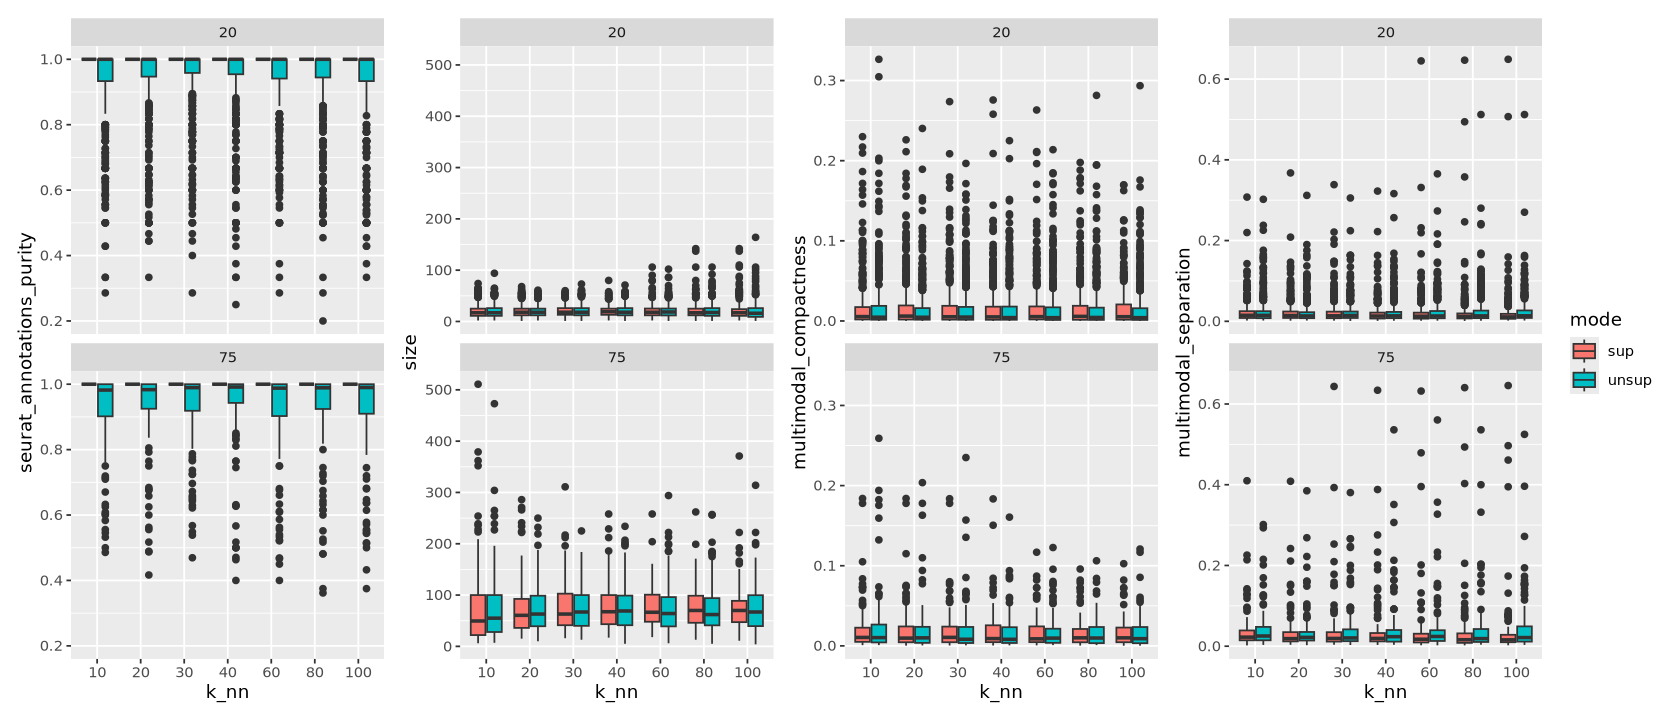

In [137]:
options(repr.plot.width=14, repr.plot.height=6)
patchwork::wrap_plots(unsup_knn.purity , unsup_knn.size,multimodal_compactness,multimodal_separation,guides = "collect",nrow  = 1)


In [139]:
pdf(file = "../../../pdf_files/FigS1/figSup_pbmc_test_knn.pdf",height = 6.5,width=14)
patchwork::wrap_plots(unsup_knn.purity , unsup_knn.size,multimodal_compactness,multimodal_separation,guides = "collect",nrow  = 1)
dev.off()

agg_record_1376199600 
                    2

## Semi sup res



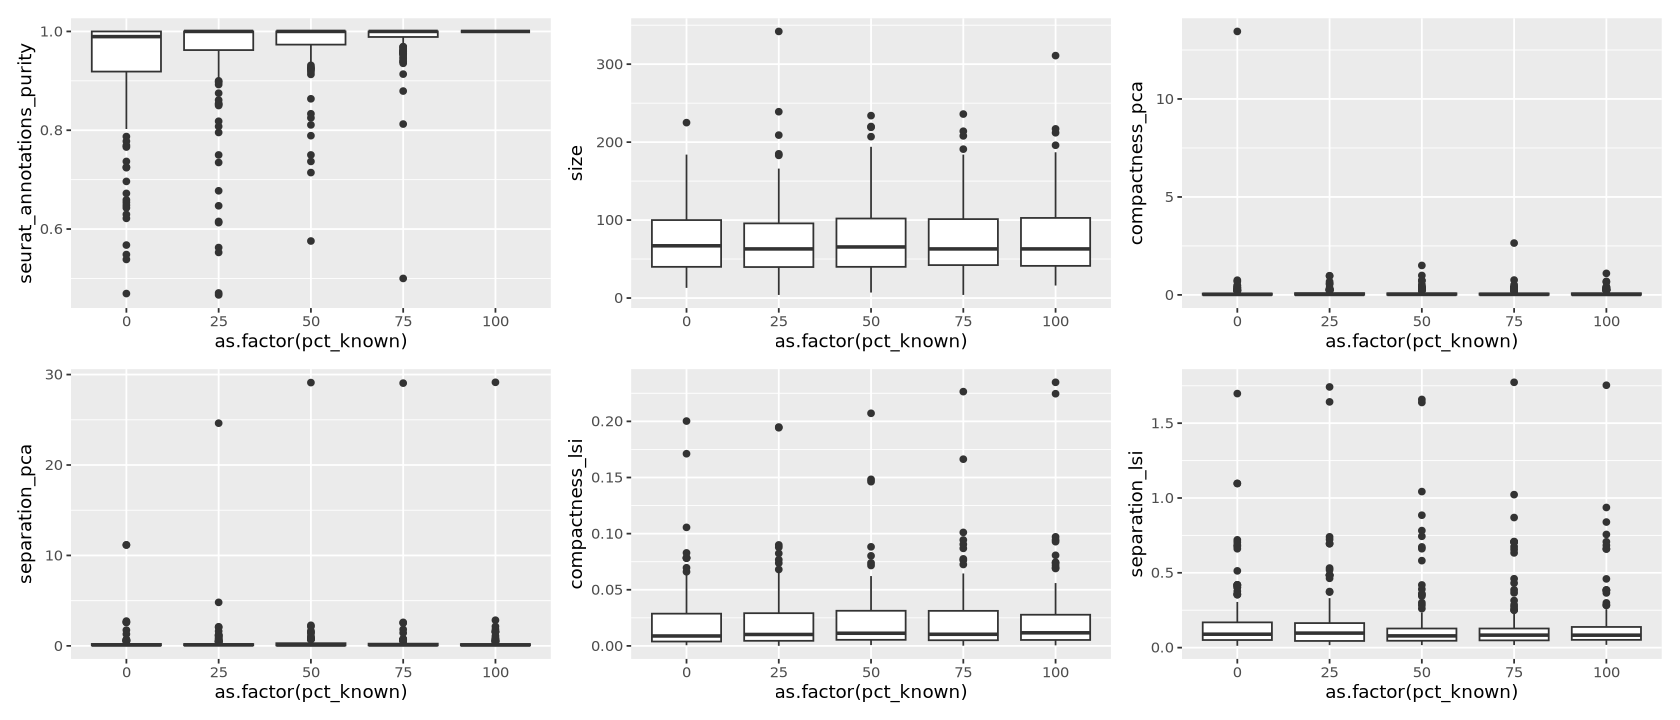

In [140]:
semi.sup <- read.csv(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testSemiSup/g75/results_test_semisup.csv"))




semi.sup.purity <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = seurat_annotations_purity)) + geom_boxplot()
semi.sup.size <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = size)) + geom_boxplot()
compactness.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_pca)) + geom_boxplot()
separation.pca <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_pca)) + geom_boxplot()
compactness.lsi <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = compactness_lsi)) + geom_boxplot()
separation.lsi <- ggplot(semi.sup,aes(x = as.factor(pct_known),y = separation_lsi)) + geom_boxplot()

patchwork::wrap_plots(semi.sup.purity , semi.sup.size,
                      compactness.pca , separation.pca,
                      compactness.lsi , separation.lsi)


In [148]:
bench.75.no.random.semi.sup <- bench.75.no.random[bench.75.no.random$tool == "ssSuperCell",]

bench.75.no.random.semi.sup$pct_known <- factor(paste0(as.character(bench.75.no.random.semi.sup$pct_known),"%"), levels = rev(c("100%","75%","50%","25%","0%") ))


In [149]:
head(bench.75.no.random.semi.sup$input)

[1] ATAC+RNA ATAC+RNA ATAC+RNA ATAC+RNA ATAC+RNA ATAC+RNA
Levels: RNA ATAC ATAC+RNA

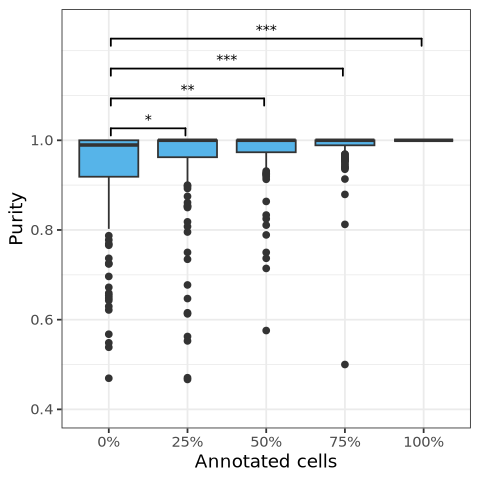

In [150]:
options(repr.plot.width=4, repr.plot.height=4)

comparisons.semi.sup <- list(
  c("0%","25%"),
  c("0%","50%"),
  c("0%","75%"),
  c("0%","100%")
)


purity.pbmc.multiome.g75.semi.sup <- ggplot(bench.75.no.random.semi.sup,
                                            aes(y=seurat_annotations_purity,x = pct_known,fill = input)) +
  geom_boxplot()  + theme_bw()  +
  geom_signif(comparisons = comparisons.semi.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  scale_y_continuous(breaks = c(0.4,0.6,0.8,1),limits = c(0.4,1.25)) +

  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + theme_bw() + xlab("Annotated cells") +ylab("Purity") + NoLegend()


purity.pbmc.multiome.g75.semi.sup

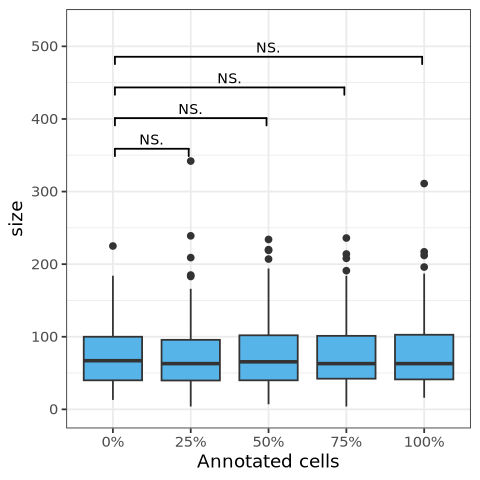

In [151]:

size.pbmc.multiome.g75.semi.sup <- ggplot(bench.75.no.random.semi.sup,
                                          aes(y=size,x = pct_known,fill = input)) +
  geom_boxplot() + theme_bw()  +
  geom_signif(comparisons = comparisons.semi.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  ylim(c(0,525))+

  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + xlab("Annotated cells") + NoLegend()


size.pbmc.multiome.g75.semi.sup

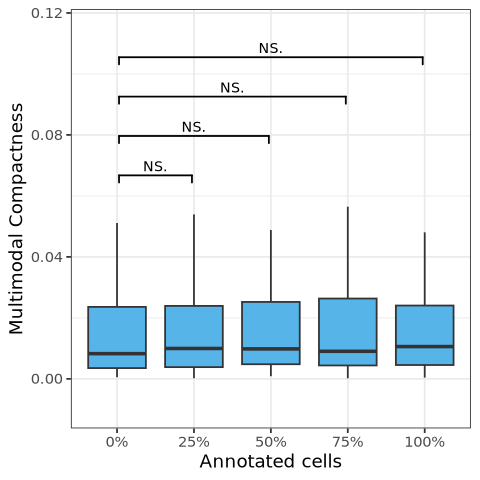

In [165]:
options(repr.plot.width=4, repr.plot.height=4)

multimodal_compactness.75.semi.sup <- ggplot(bench.75.no.random.semi.sup,aes(y=multimodal_compactness,x = pct_known,fill = input)) +
  geom_boxplot(outlier.shape = NA)  + theme_bw() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(-0.01,0.115))   + NoLegend() +
  geom_signif(comparisons = comparisons.semi.sup,
              y_position = 0.055,
              step_increase=0.055,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.01,
              textsize = 3) + xlab("Annotated cells")
multimodal_compactness.75.semi.sup


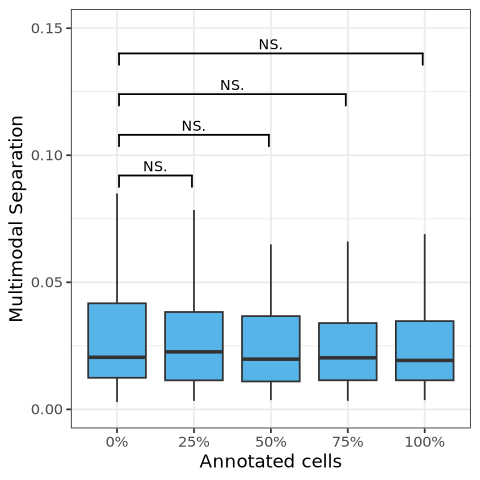

In [153]:
multimodal_separation.75.semi.sup <- ggplot(bench.75.no.random.semi.sup,aes(y=multimodal_separation,x = pct_known,fill = input)) +
  geom_boxplot(outlier.shape = NA) +theme_bw() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.15))+ NoLegend() +
  geom_signif(comparisons = comparisons.semi.sup,
              y_position = 0.06,
              step_increase=0.025,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.007,
              textsize = 3) + xlab("Annotated cells")
multimodal_separation.75.semi.sup

agg_record_2101914774 
                    2

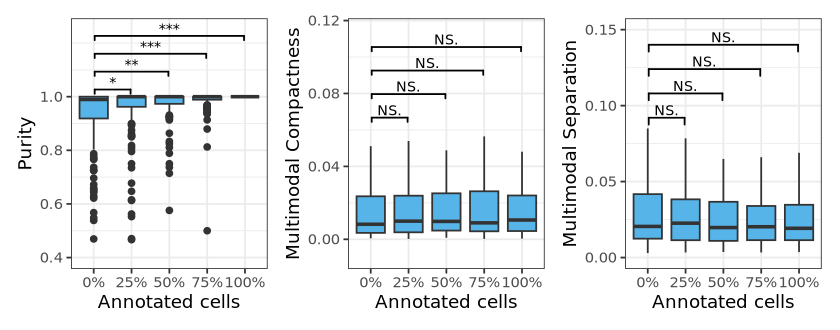

In [166]:
options(repr.plot.width=7, repr.plot.height=2.75)

wrap_plots(purity.pbmc.multiome.g75.semi.sup,multimodal_compactness.75.semi.sup,multimodal_separation.75.semi.sup,nrow = 1)

pdf("../../../pdf_files/Fig2/fig2I_semi_sup.pdf",height = 2.75,width = 7)
wrap_plots(purity.pbmc.multiome.g75.semi.sup,multimodal_compactness.75.semi.sup,multimodal_separation.75.semi.sup,nrow = 1)
dev.off()

In [172]:

plot.list <- list()
for (p in c(100,75,50,25,0)) {
  sobj <- readRDS(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testSemiSup/g75/guiding_label_",p,"_pct_hiddenseurat.mc.rds"))
  sobj <- addCellTypePBMC(sobj)
  plot.list[[paste0("pct_",p)]] <-  SingleCellsMetacellsWnnUMAP(
    sobj.sc = pbmc,
    sobj.mc = sobj,
    dimred_1 = "pca",
    dimred_2= "lsi",
    dims.list = list(1:40, 2:40),
    cols = color.celltypes.pbmc,
    group.by = "celltype",
    dims.umap = c(1,2)
    ) + 
    theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  ggtitle(label = "SuperCell ATAC+RNA", subtitle = paste0(100-p, "% annotated cells")) + 
    scale_size(limits = c(0,max(bench.75.no.random.semi.sup$size)),breaks = c(100,200,300,400))  +
    guides(fill=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
           colour = "none",
           size = guide_legend(title = "Size"))


}


Converting layer data in assay ATAC to empty dgCMatrix

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

17:14:36 UMAP embedding parameters a = 0.9922 b = 1.112

17:14:38 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

17:14:41 Initializing from normalized Laplacian + noise (using RSpectra)

17:14:42 Commencing optimization for 200 epochs, with 316338 positive edges

17:14:42 Using rng type: pcg

17:14:51 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”
Converting layer data in assay ATAC to empty dgCMatrix

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

agg_record_1817088814 
                    2

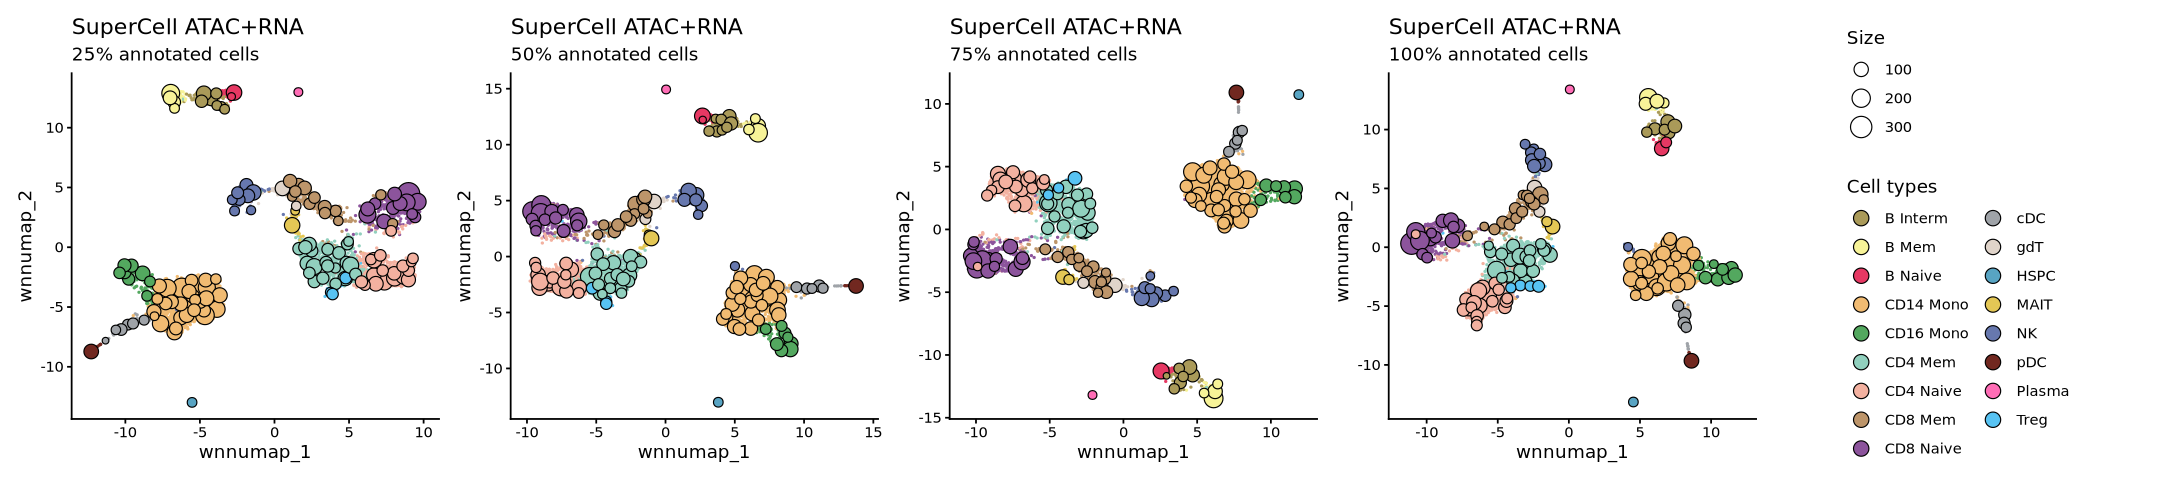

In [173]:
options(repr.plot.width=18, repr.plot.height=4)

wrap_plots(plot.list[[2]],plot.list[[3]],plot.list[[4]],plot.list[[5]],guide_area(),guides = "collect",nrow = 1)

dir.create("../../../pdf_files/FigS3/", recursive = T, showWarnings = F)
pdf("../../../pdf_files/FigS3/figS3A_semi_sup.pdf", height = 4,width = 18)
wrap_plots(plot.list[[2]],plot.list[[3]],plot.list[[4]],plot.list[[5]],guide_area(),guides = "collect",nrow = 1)
dev.off()

## Noisy sup

In [174]:
bench.75.no.random.noisy.sup <- bench.75.no.random[bench.75.no.random$tool == "supSuperCell",]
table(bench.75.no.random.noisy.sup$guiding_labels)


 guiding_label_0_pct_shuffled guiding_label_10_pct_shuffled 
                          138                           138 
 guiding_label_1_pct_shuffled guiding_label_20_pct_shuffled 
                          138                           138 
 guiding_label_5_pct_shuffled                  unsupervised 
                          138                           138 

In [175]:

bench.75.no.random.noisy.sup$shuffled_labels <- gsub(x = bench.75.no.random.noisy.sup$guiding_labels,pattern = "[a-z]*",replacement = "")
bench.75.no.random.noisy.sup$shuffled_labels <- gsub(x = bench.75.no.random.noisy.sup$shuffled_labels,pattern = "_*",replacement = "")
bench.75.no.random.noisy.sup$shuffled_labels <- paste0(bench.75.no.random.noisy.sup$shuffled_labels,"%")
bench.75.no.random.noisy.sup$shuffled_labels[bench.75.no.random.noisy.sup$shuffled_labels == "%"] <- "Unsup."
bench.75.no.random.noisy.sup$shuffled_labels <- factor(bench.75.no.random.noisy.sup$shuffled_labels,levels = rev(c("0%","1%","5%","10%","20%","Unsup.")))

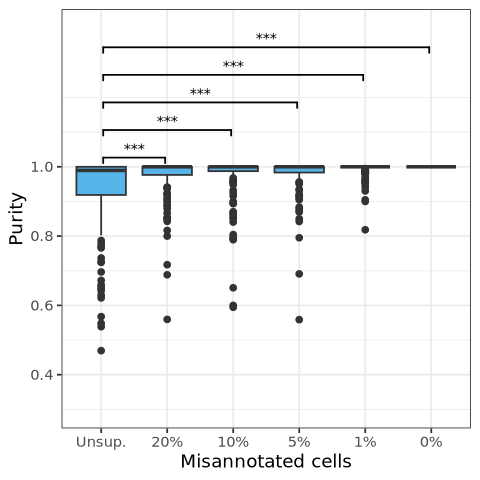

In [207]:
options(repr.plot.width=4, repr.plot.height=4)


comparisons.noisy.sup <- list(
  c("Unsup.","20%"),
  c("Unsup.","10%"),
  c("Unsup.","5%"),
  c("Unsup.","1%"),
  c("Unsup.","0%")
)


purity.pbmc.multiome.g75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "ATAC+RNA",],
                                            aes(y=seurat_annotations_purity,x = shuffled_labels,fill = input)) + 
  geom_boxplot()  + theme_bw()  + 
  geom_signif(comparisons = comparisons.noisy.sup,
              step_increase=0.15,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  scale_y_continuous(breaks = c(0.4,0.6,0.8,1),limits = c(0.3,1.4)) + 
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + theme_bw() + xlab("Misannotated cells") +ylab("Purity") + NoLegend()


purity.pbmc.multiome.g75.noisy.sup 

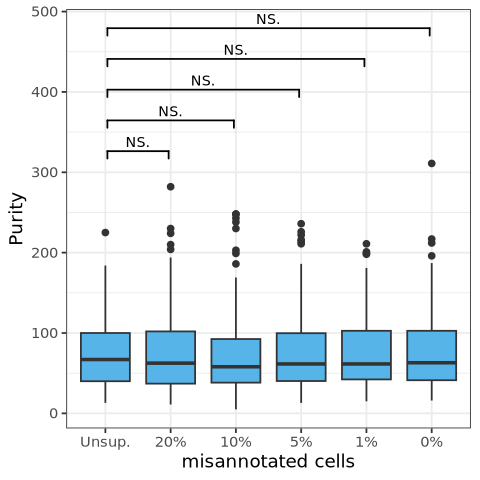

In [184]:
size.pbmc.multiome.g75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "ATAC+RNA",],
                                          aes(y=size,x = shuffled_labels,fill = input)) + 
  geom_boxplot() + theme_bw()  + 
  geom_signif(comparisons = comparisons.noisy.sup,
              step_increase=0.125,
              map_signif_level=T,
              extend_line = -0.005,
              textsize = 3)+
  #ylim(c(0,525))+ 
  
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + theme_bw() + xlab("misannotated cells") +ylab("Purity") + NoLegend()



size.pbmc.multiome.g75.noisy.sup

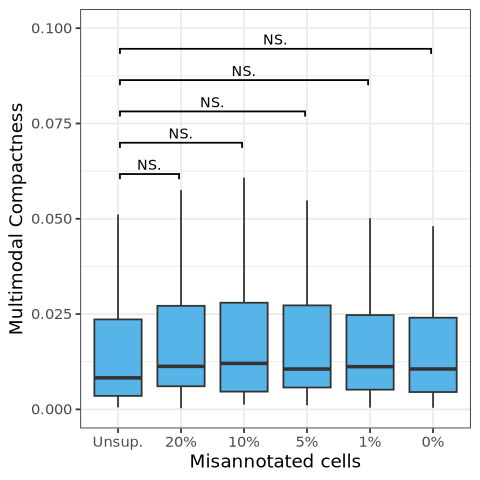

In [203]:
multimodal_compactness.75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "ATAC+RNA",],aes(y=multimodal_compactness,x = shuffled_labels,fill = input)) + 
  geom_boxplot(outlier.shape = NA)  + theme_bw() + 
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Compactness")  +  # Hides outliers
  coord_cartesian(ylim = c(0,0.1))   + NoLegend() + 
  geom_signif(comparisons = comparisons.noisy.sup,
              y_position = 0.05,
              step_increase=0.035,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.005,
              textsize = 3) + xlab("Misannotated cells")
multimodal_compactness.75.noisy.sup

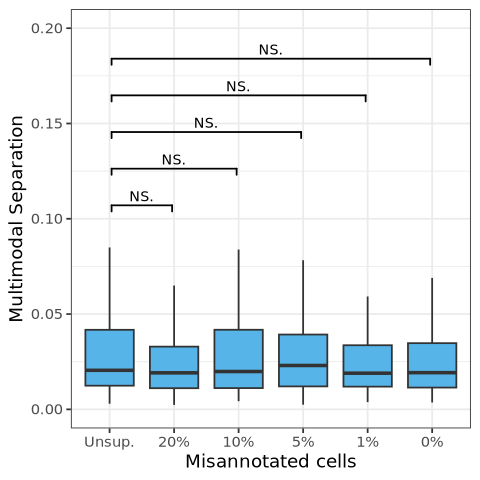

In [200]:
multimodal_separation.75.noisy.sup <- ggplot(bench.75.no.random.noisy.sup[bench.75.no.random.noisy.sup$input == "ATAC+RNA",],aes(y=multimodal_separation,x = shuffled_labels,fill = input)) + 
  geom_boxplot(outlier.shape = NA) +theme_bw() +
  theme(legend.position = "bottom")  + scale_fill_manual(values = input.colors.10Xmultiome) + ylab("Multimodal Separation")  +  # Hides outliers
  coord_cartesian(ylim = c(0, 0.2))+ NoLegend() + 
  geom_signif(comparisons = comparisons.noisy.sup,
              y_position = 0.075,
              step_increase=0.03,
              map_signif_level=T,
              extend_line = -0.005,
              tip_length = 0.005,
              textsize = 3) + xlab("Misannotated cells")
multimodal_separation.75.noisy.sup

agg_record_1778265153 
                    2

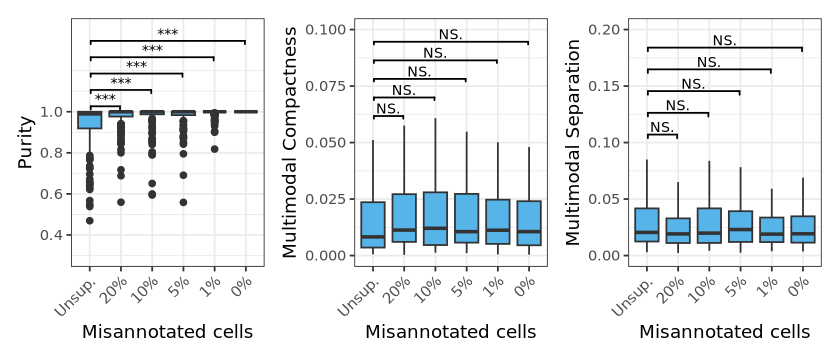

In [208]:
options(repr.plot.width=7, repr.plot.height=3)

wrap_plots(purity.pbmc.multiome.g75.noisy.sup,multimodal_compactness.75.noisy.sup,multimodal_separation.75.noisy.sup,nrow = 1) &scale_x_discrete(guide = guide_axis(angle = 45)) 

pdf("../../../pdf_files/Fig2/fig2N_noisy_pbmc_multiome.pdf",height = 3,width = 7)
wrap_plots(purity.pbmc.multiome.g75.noisy.sup,multimodal_compactness.75.noisy.sup,multimodal_separation.75.noisy.sup,nrow = 1)
dev.off()

In [214]:


plot.list <- list()
for (p in c(1,5,10,20)) {
  sobj <- readRDS(paste0(datadir,"/output/pbmcMultiome/SuperCellMulti/testShufflingSup/g75/guiding_label_",p,"_pct_shuffledseurat.mc.rds"))
  sobj <- addCellTypePBMC(sobj)
  plot.list[[paste0("pct_",p)]] <- SingleCellsMetacellsWnnUMAP(
    sobj.sc = pbmc,
    sobj.mc = sobj,
    dimred_1 = "pca",
    dimred_2= "lsi",
    dims.list = list(1:40, 2:40),
    cols = color.celltypes.pbmc,
    group.by = "celltype",
    dims.umap = c(1,2)
    ) + 
    theme_classic() + 
  #NoLegend() +
  # scale_size(limits = c(0,max(metrics$size[metrics$gamma == 75])),breaks = c(50,100,200,400)) +
  ggtitle(label = "SuperCell ATAC+RNA", subtitle = paste0(p, "% misannotated cells")) + 
    scale_size(limits = c(0,max(bench.75.no.random.semi.sup$size)),breaks = c(100,200,300,400))  +
    guides(fill=guide_legend(ncol =2,title = "Cell types",
                             override.aes = list(size=4)),
           colour = "none",
           size = guide_legend(title = "Size"))
  
  
}





Converting layer data in assay ATAC to empty dgCMatrix

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

17:36:09 UMAP embedding parameters a = 0.9922 b = 1.112

17:36:10 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

17:36:13 Initializing from normalized Laplacian + noise (using RSpectra)

17:36:14 Commencing optimization for 200 epochs, with 316490 positive edges

17:36:14 Using rng type: pcg

17:36:24 Optimization finished

Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“No assay specified, setting assay as RNA by default.”
Converting layer data in assay ATAC to empty dgCMatrix

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

agg_record_207867573 
                   2

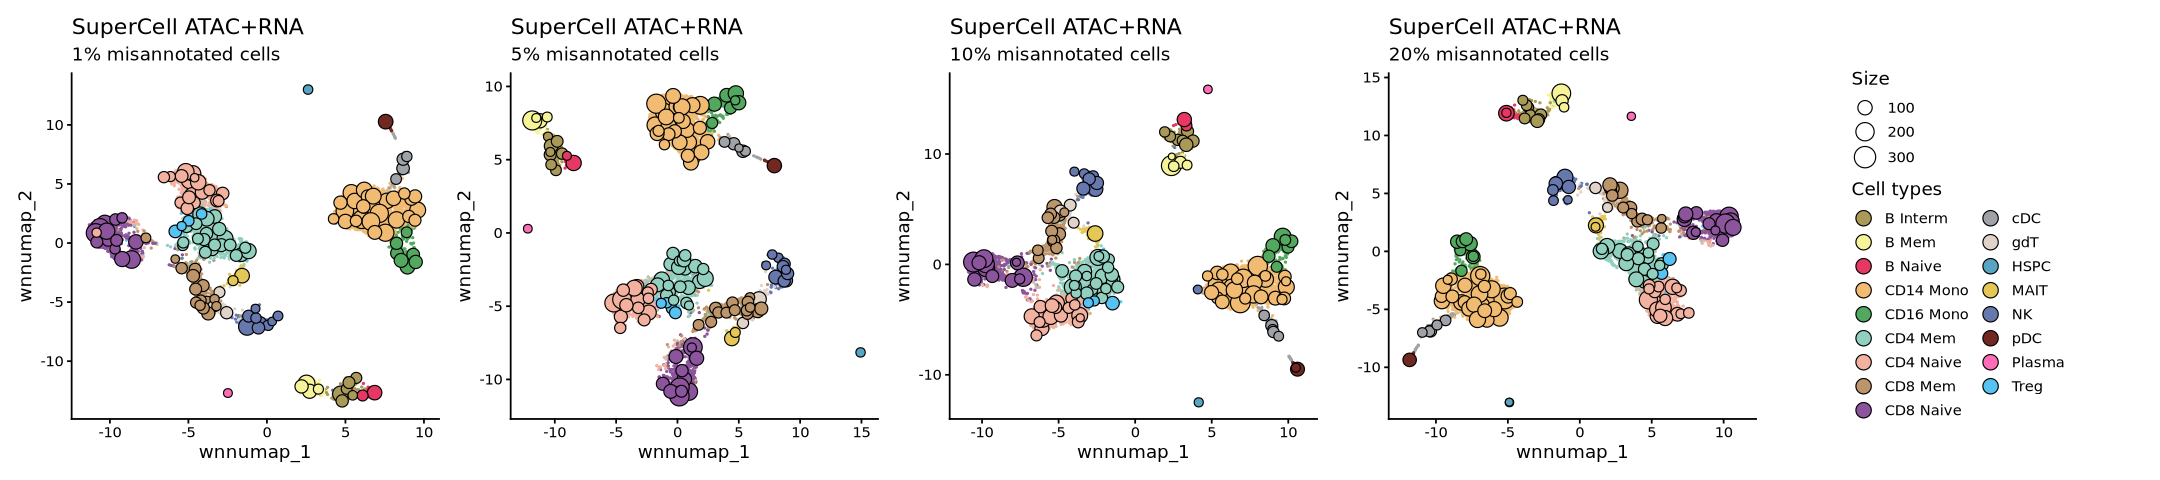

In [216]:
options(repr.plot.width=18, repr.plot.height=4)

wrap_plots(plot.list[[1]],plot.list[[2]],plot.list[[3]],plot.list[[4]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dir.create("../../../pdf_files/FigS3", recursive = T, showWarnings = F)
pdf("../../../pdf_files/FigS3/figSN_noisy_sup_pbmc_multiome.pdf", height = 4,width = 18)
wrap_plots(plot.list[[1]],plot.list[[2]],plot.list[[3]],plot.list[[4]],guide_area(),guides = "collect",nrow = 1) & 
  theme(legend.spacing.y = unit(-0.35, "line"),legend.key.size = unit(1, "line"))

dev.off()

In [218]:

library(dplyr)
library(purrr)
library(tidyr)
cols <- c("method","purity","multimodal_compactness","multimodal_separation")

bench.75.unsup$purity <- bench.75.unsup$seurat_annotations_purity


results <- ComputePairwiseWilcox(bench.results = bench.75.unsup)


#signif(results$RBC,digits = 5) == signif(results$RBC2,digits = 5)

head(results)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell ATAC+RNA,SuperCell RNA,138,138,8936.0,-0.06154169,0.37719469,0.42434403,0.4234344,0.3722819
multimodal_compactness,SuperCell ATAC+RNA,SuperCell ATAC,138,138,10221.0,0.07340895,0.29210798,0.34591734,0.5344566,0.4610277
multimodal_compactness,SuperCell ATAC+RNA,SEACells ATAC+RNA,138,138,9297.0,-0.02362949,0.73491047,0.75161298,0.1337656,0.1240057
multimodal_compactness,SuperCell ATAC+RNA,SEACells RNA,138,138,8296.0,-0.12875446,0.06455126,0.09370344,1.1900953,1.0282444
multimodal_compactness,SuperCell ATAC+RNA,SEACells ATAC,138,138,8498.0,-0.10754043,0.12266396,0.16234936,0.9112830,0.7895494
multimodal_compactness,SuperCell ATAC+RNA,MetaQ ATAC+RNA,138,136,10806.5,0.15158781,0.03013745,0.04520618,1.5208934,1.3448022


In [219]:



# Keep the condition order you want in the plot
condition_order <- rev(c('SuperCell ATAC+RNA',"SEACells ATAC+RNA","MetaQ ATAC+RNA",
                         "SuperCell ATAC","SEACells ATAC","MetaQ ATAC",
                         'SuperCell RNA',"SEACells RNA","MetaQ RNA","MetaCell2 RNA"))


results_plot <- results %>%
  mutate(
    group1 = factor(group1, levels = condition_order),
    group2 = factor(group2, levels = rev(condition_order))
  ) %>%
  filter(
    #as.numeric(group1) > as.numeric(group2),
    p < 0.05
  )

head(results_plot)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<fct>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell ATAC+RNA,MetaQ ATAC+RNA,138,136,10806.5,0.1515878,3.013745e-02,4.520618e-02,1.520893,1.344802
multimodal_compactness,SuperCell ATAC+RNA,MetaQ RNA,138,138,3614.0,-0.6204579,5.105449e-19,7.658174e-18,18.291966,17.115875
multimodal_compactness,SuperCell ATAC+RNA,MetaQ ATAC,138,138,6334.0,-0.3348036,1.528078e-06,4.911680e-06,5.815854,5.308770
multimodal_compactness,SuperCell ATAC+RNA,MetaCell2 RNA,138,140,6363.0,-0.3413043,8.718286e-07,3.017868e-06,6.059569,5.520300
multimodal_compactness,SuperCell RNA,MetaQ ATAC+RNA,138,136,11361.0,0.2106777,2.580101e-03,4.837689e-03,2.588363,2.315362
multimodal_compactness,SuperCell RNA,MetaQ RNA,138,138,4412.0,-0.5366520,1.294434e-14,9.708254e-14,13.887920,13.012859


agg_record_280240098 
                   2

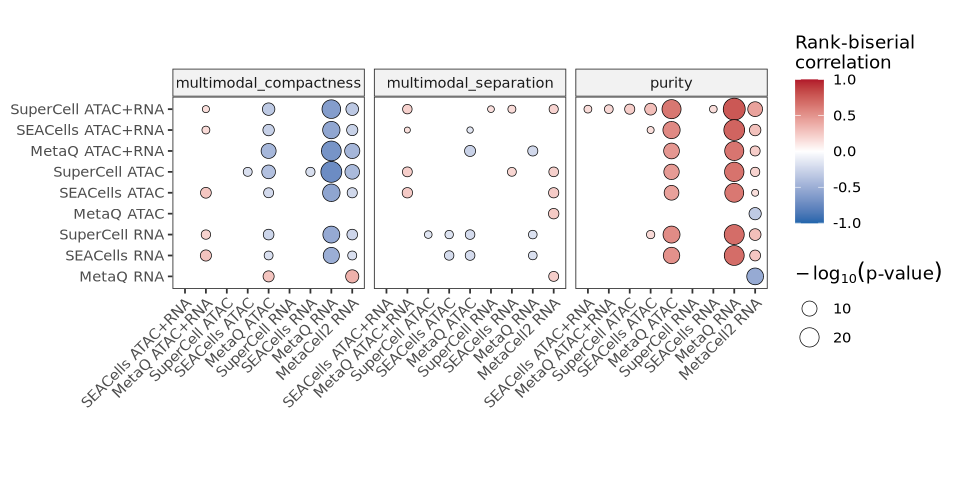

In [222]:
options(repr.plot.width=8, repr.plot.height=4)

heatmap_wilcox <- HeatmapWilcox(results_plot)
heatmap_wilcox

pdf(file = "../../../pdf_files/FigS1/FigSNnew_WilcoxHeatmap_pbmc_multiome.pdf",height = 4,width=8)
heatmap_wilcox
dev.off()

at gamma 20

In [226]:

library(dplyr)
library(purrr)
library(tidyr)
cols <- c("method","purity","multimodal_compactness","multimodal_separation")

bench.20.unsup$purity <- bench.20.unsup$seurat_annotations_purity


results <- ComputePairwiseWilcox(bench.results = bench.20.unsup)


#signif(results$RBC,digits = 5) == signif(results$RBC2,digits = 5)

head(results)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell ATAC+RNA,SuperCell RNA,520,520,119731.5,-0.11441198,1.404550e-03,2.038863e-03,2.8524628,2.6906120
multimodal_compactness,SuperCell ATAC+RNA,SuperCell ATAC,520,520,157198.0,0.16270710,5.575592e-06,1.090877e-05,5.2537090,4.9622243
multimodal_compactness,SuperCell ATAC+RNA,SEACells ATAC+RNA,520,520,137096.5,0.01402737,6.954487e-01,6.954487e-01,0.1577349,0.1577349
multimodal_compactness,SuperCell ATAC+RNA,SEACells RNA,520,520,116057.5,-0.14158654,7.740560e-05,1.339712e-04,4.1112276,3.8729884
multimodal_compactness,SuperCell ATAC+RNA,SEACells ATAC,520,520,143269.0,0.05968195,9.572891e-02,1.104564e-01,1.0189569,0.9568090
multimodal_compactness,SuperCell ATAC+RNA,MetaQ ATAC+RNA,520,473,117197.0,-0.04702391,2.001595e-01,2.196872e-01,0.6986238,0.6581952


In [227]:
# Keep the condition order you want in the plot
condition_order <- rev(c('SuperCell ATAC+RNA',"SEACells ATAC+RNA","MetaQ ATAC+RNA",
                         "SuperCell ATAC","SEACells ATAC","MetaQ ATAC",
                         'SuperCell RNA',"SEACells RNA","MetaQ RNA","MetaCell2 RNA"))


results_plot <- results %>%
  mutate(
    group1 = factor(group1, levels = condition_order),
    group2 = factor(group2, levels = rev(condition_order))
  ) %>%
  filter(
    #as.numeric(group1) > as.numeric(group2),
    p < 0.05
  )

head(results_plot)

metric,group1,group2,n1,n2,W,RBC,p,padj,logP,logFDR
<chr>,<fct>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
multimodal_compactness,SuperCell ATAC+RNA,SuperCell RNA,520,520,119731.5,-0.11441198,1.404550e-03,2.038863e-03,2.852463,2.690612
multimodal_compactness,SuperCell ATAC+RNA,SuperCell ATAC,520,520,157198.0,0.16270710,5.575592e-06,1.090877e-05,5.253709,4.962224
multimodal_compactness,SuperCell ATAC+RNA,SEACells RNA,520,520,116057.5,-0.14158654,7.740560e-05,1.339712e-04,4.111228,3.872988
multimodal_compactness,SuperCell ATAC+RNA,MetaQ RNA,520,512,75772.0,-0.43079928,4.581476e-33,2.290738e-32,32.338995,31.640025
multimodal_compactness,SuperCell ATAC+RNA,MetaQ ATAC,520,520,122253.0,-0.09576183,7.515511e-03,9.946999e-03,2.124042,2.002308
multimodal_compactness,SuperCell ATAC+RNA,MetaCell2 RNA,520,529,69874.0,-0.49197324,2.839392e-43,2.911880e-42,42.546775,41.535826


agg_record_191148484 
                   2

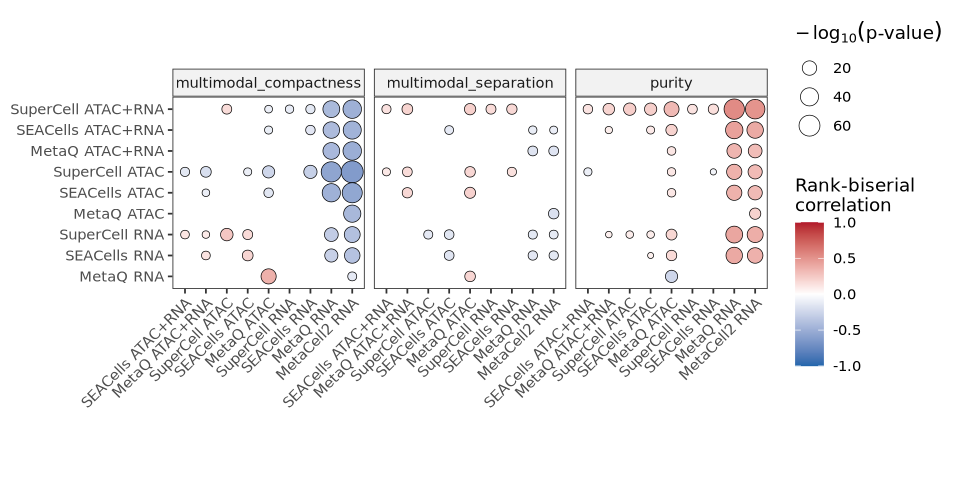

In [228]:
options(repr.plot.width=8, repr.plot.height=4)

heatmap_wilcox <- HeatmapWilcox(results_plot)
heatmap_wilcox

pdf(file = "../../../pdf_files/FigS1/FigSNnew_WilcoxHeatmap_pbmc_multiome_g20.pdf",height = 4,width=8)
heatmap_wilcox
dev.off()

In [ ]:
save.image("allres_fig2_pbmc_mofa_40_dims.Rdata")